# Lección 5.3 · Máxima verosimilitud, bootstrap y un árbol real

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-05-filogenetica/5.3_maxima_verosimilitud_bootstrap.ipynb) [![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Licencia: MIT](https://img.shields.io/badge/Licencia-MIT-2a78d6.svg)](https://github.com/juvenalyosa/bioinformatica-practica/blob/main/LICENSE)

**Módulo 5 — Filogenética y evolución molecular** · Bioinformática Práctica (Maestría)

👤 **Juvenal Yosa, PhD** · ✉️ [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · 🤖 Copiloto: **Claude** (Anthropic)

| ⏱️ Duración | 📶 Nivel | 🧰 Requisitos |
|---|---|---|
| ~3.5 horas | Intermedio–avanzado | Lecciones 5.1 (distancias y modelos de sustitución) y 5.2 (UPGMA y Neighbor-Joining), probabilidad básica, NumPy |

---

## 🎯 Objetivos de aprendizaje

Al terminar esta clase usted podrá:

1. **Explicar** qué es la **verosimilitud** y en qué se diferencia de la probabilidad, empezando por una moneda y
   llegando a un par de secuencias de ADN.
2. **Calcular** a mano y con código la verosimilitud de dos secuencias bajo el modelo **Jukes-Cantor (JC69)** en función
   del tiempo $t$, y **demostrar** que su máximo coincide con la distancia $d_{JC}$ de fórmula cerrada.
3. **Resolver** a mano el **algoritmo de poda de Felsenstein** (*pruning*) para un sitio de un árbol de 4 taxones,
   llenando la tabla de verosimilitudes parciales nodo por nodo.
4. **Programar** la log-verosimilitud de un árbol completo, **optimizar** sus longitudes de rama con `scipy.optimize` y
   **comparar** las tres topologías posibles de humano, chimpancé, gorila y orangután.
5. **Elegir** un modelo de sustitución (JC69, K80, HKY, HKY+Γ) con los criterios **AIC** y **BIC**.
6. **Aplicar** el **bootstrap no paramétrico** (remuestrear columnas) para medir el apoyo de cada clado.
7. **Ejecutar** IQ-TREE 2 con **ModelFinder** y **UFBoot** sobre 2.7 kb de ADN mitocondrial de 12 primates, **leer** sus
   archivos `.iqtree` y `.treefile` y **dibujar** un árbol final de calidad de publicación.

## 🗺️ Mapa de la clase

1. ¿Qué es la verosimilitud? Una moneda
2. De la moneda al ADN: verosimilitud de dos secuencias bajo JC69
3. Los datos reales: 12 primates, dos genes mitocondriales
4. El algoritmo de poda de Felsenstein (🎬 animación)
5. La verosimilitud de un árbol completo y sus longitudes de rama
6. Humano, chimpancé, gorila y orangután: las tres topologías
7. ¿Qué modelo? AIC y BIC
8. Bootstrap: ¿cuánto confiamos en cada rama? (🎬 animación)
9. 🧪 IQ-TREE 2 de verdad: ModelFinder + UFBoot
10. Ejercicios, resumen y lecturas

In [1]:
# ⚙️ Configuración del entorno (ejecute esta celda primero)
# Bioinformática Práctica · Juvenal Yosa, PhD · Copiloto: Claude
import os, sys, urllib.request

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Descarga el estilo gráfico del curso (en Colab) o lo toma del repositorio (local)
STYLE_URL = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/utils/estilo_curso.py"
if os.path.exists("../utils/estilo_curso.py"):
    sys.path.insert(0, "../utils")
elif not os.path.exists("estilo_curso.py"):
    urllib.request.urlretrieve(STYLE_URL, "estilo_curso.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import estilo_curso as ec

ec.set_style()
print("Entorno listo ✔  |  Colab:", IN_COLAB)

import io, re, shutil, subprocess, itertools, time, tarfile
from collections import Counter
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from matplotlib.patches import Circle, FancyBboxPatch, Rectangle
from scipy.optimize import minimize, minimize_scalar
from scipy.special import gammainc
from scipy.stats import gamma as gamma_dist

try:
    import Bio
except ImportError:
    %pip install -q biopython
    import Bio
from Bio import AlignIO, Phylo, SeqIO

RAW = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main"

def course_bytes(name, live_url=None):
    """Lee un archivo del curso: 1) copia local ../data; 2) servicio original (NCBI…);
    3) copia de respaldo en el repositorio de GitHub. Devuelve los bytes."""
    local = os.path.join("..", "data", name)
    if os.path.exists(local):
        return open(local, "rb").read()
    for url in [live_url, f"{RAW}/data/{name}"]:
        if url is None:
            continue
        try:
            with urllib.request.urlopen(url, timeout=60) as r:
                return r.read()
        except Exception as err:
            print(f"⚠️ No se pudo descargar {url[:70]}… ({err}); pruebo la siguiente fuente")
    raise RuntimeError(f"No se encontró {name}")

BASES = "ACGT"
rng = np.random.default_rng(53)       # semilla fija: todos obtenemos los mismos números
print("Listo para la Lección 5.3")

Entorno listo ✔  |  Colab: False


Listo para la Lección 5.3


## 1. ¿Qué es la verosimilitud? Una moneda

Empecemos lejos de la biología. Una amiga le entrega una moneda que quizá esté trucada; usted la lanza **10 veces** y
obtiene **7 caras** y 3 sellos. ¿Cuál es la probabilidad $p$ de cara de esa moneda?

Hay dos maneras de mirar la misma fórmula:

* **Probabilidad**: el modelo está fijo y preguntamos por los datos. *"Si la moneda es justa ($p = 0.5$), ¿qué tan
  probable es sacar exactamente esta secuencia de 7 caras y 3 sellos?"*
* **Verosimilitud**: los datos están fijos (ya lanzamos la moneda) y **movemos el modelo**. *"De todos los valores
  posibles de $p$, ¿cuál hace más probable lo que efectivamente vimos?"*

La cuenta es la misma; lo que cambia es qué consideramos variable. Cuando un detective dice que el sospechoso
"verosímilmente" estuvo en la escena, no afirma que lo vio: dice que esa hipótesis **explica bien** las huellas
encontradas. La verosimilitud mide exactamente eso: qué tan bien explica cada hipótesis los datos que ya tenemos.

$$
L(p) \;=\; P(\text{datos} \mid p) \;=\; p^{\,k}\,(1-p)^{\,n-k}
\qquad\qquad
\ell(p) \;=\; \ln L(p) \;=\; k \ln p + (n-k)\ln(1-p)
$$

| Símbolo | Significado |
|---|---|
| $n$ | número de lanzamientos (10) |
| $k$ | número de caras observadas (7) |
| $p$ | parámetro desconocido: probabilidad de cara |
| $L(p)$ | **verosimilitud**: probabilidad de los datos observados si el parámetro vale $p$ |
| $\ell(p)$ | **log-verosimilitud** (logaritmo natural): más cómoda, porque los productos se vuelven sumas |

### Ejemplo a mano

| $p$ | $L(p) = p^7 (1-p)^3$ | $\ell(p)$ |
|---|---|---|
| 0.5 | $0.5^{10} = 0.000977$ | $-6.931$ |
| **0.7** | $0.0824 \times 0.027 = \mathbf{0.002224}$ | $\mathbf{-6.109}$ |
| 0.9 | $0.4783 \times 0.001 = 0.000478$ | $-7.645$ |

El valor $p = 0.7$ explica los datos más de dos veces mejor que la moneda justa. ¿Es el mejor posible? Derivando $\ell$
e igualando a cero:

$$
\frac{d\ell}{dp} = \frac{k}{p} - \frac{n-k}{1-p} = 0
\quad\Longrightarrow\quad
\boxed{\;\hat p = \frac{k}{n} = 0.7\;}
$$

El **estimador de máxima verosimilitud** (MLE, por sus siglas en inglés) es la proporción observada: la respuesta que
el sentido común ya sugería. La ventaja del método es que funciona igual cuando el sentido común ya no alcanza, como en
un árbol con 21 ramas.

Dos detalles importantes:

1. $L(p)$ **no es una distribución de probabilidad sobre $p$**: su área no tiene por qué sumar 1. Sólo importan los
   **cocientes** $L(p_1)/L(p_2)$, o las **diferencias** $\ell(p_1) - \ell(p_2)$.
2. Con más datos la curva se vuelve **más estrecha**: la incertidumbre sobre $p$ disminuye. Una regla práctica
   (del teorema de Wilks) dice que los valores de $p$ con $\ell(p) \ge \ell(\hat p) - 1.92$ forman un
   **intervalo de confianza aproximado del 95 %**.

> 🤔 **Antes de ejecutar, prediga:** si lanzamos la moneda 100 veces y obtenemos 70 caras, el máximo sigue en 0.7.
> ¿Qué le pasará al ancho del intervalo del 95 %: se reduce a la mitad, a un tercio, o a la décima parte?

p = 0.5:  L = 0.000977   ℓ = -6.931
p = 0.7:  L = 0.002224   ℓ = -6.109
p = 0.9:  L = 0.000478   ℓ = -7.645


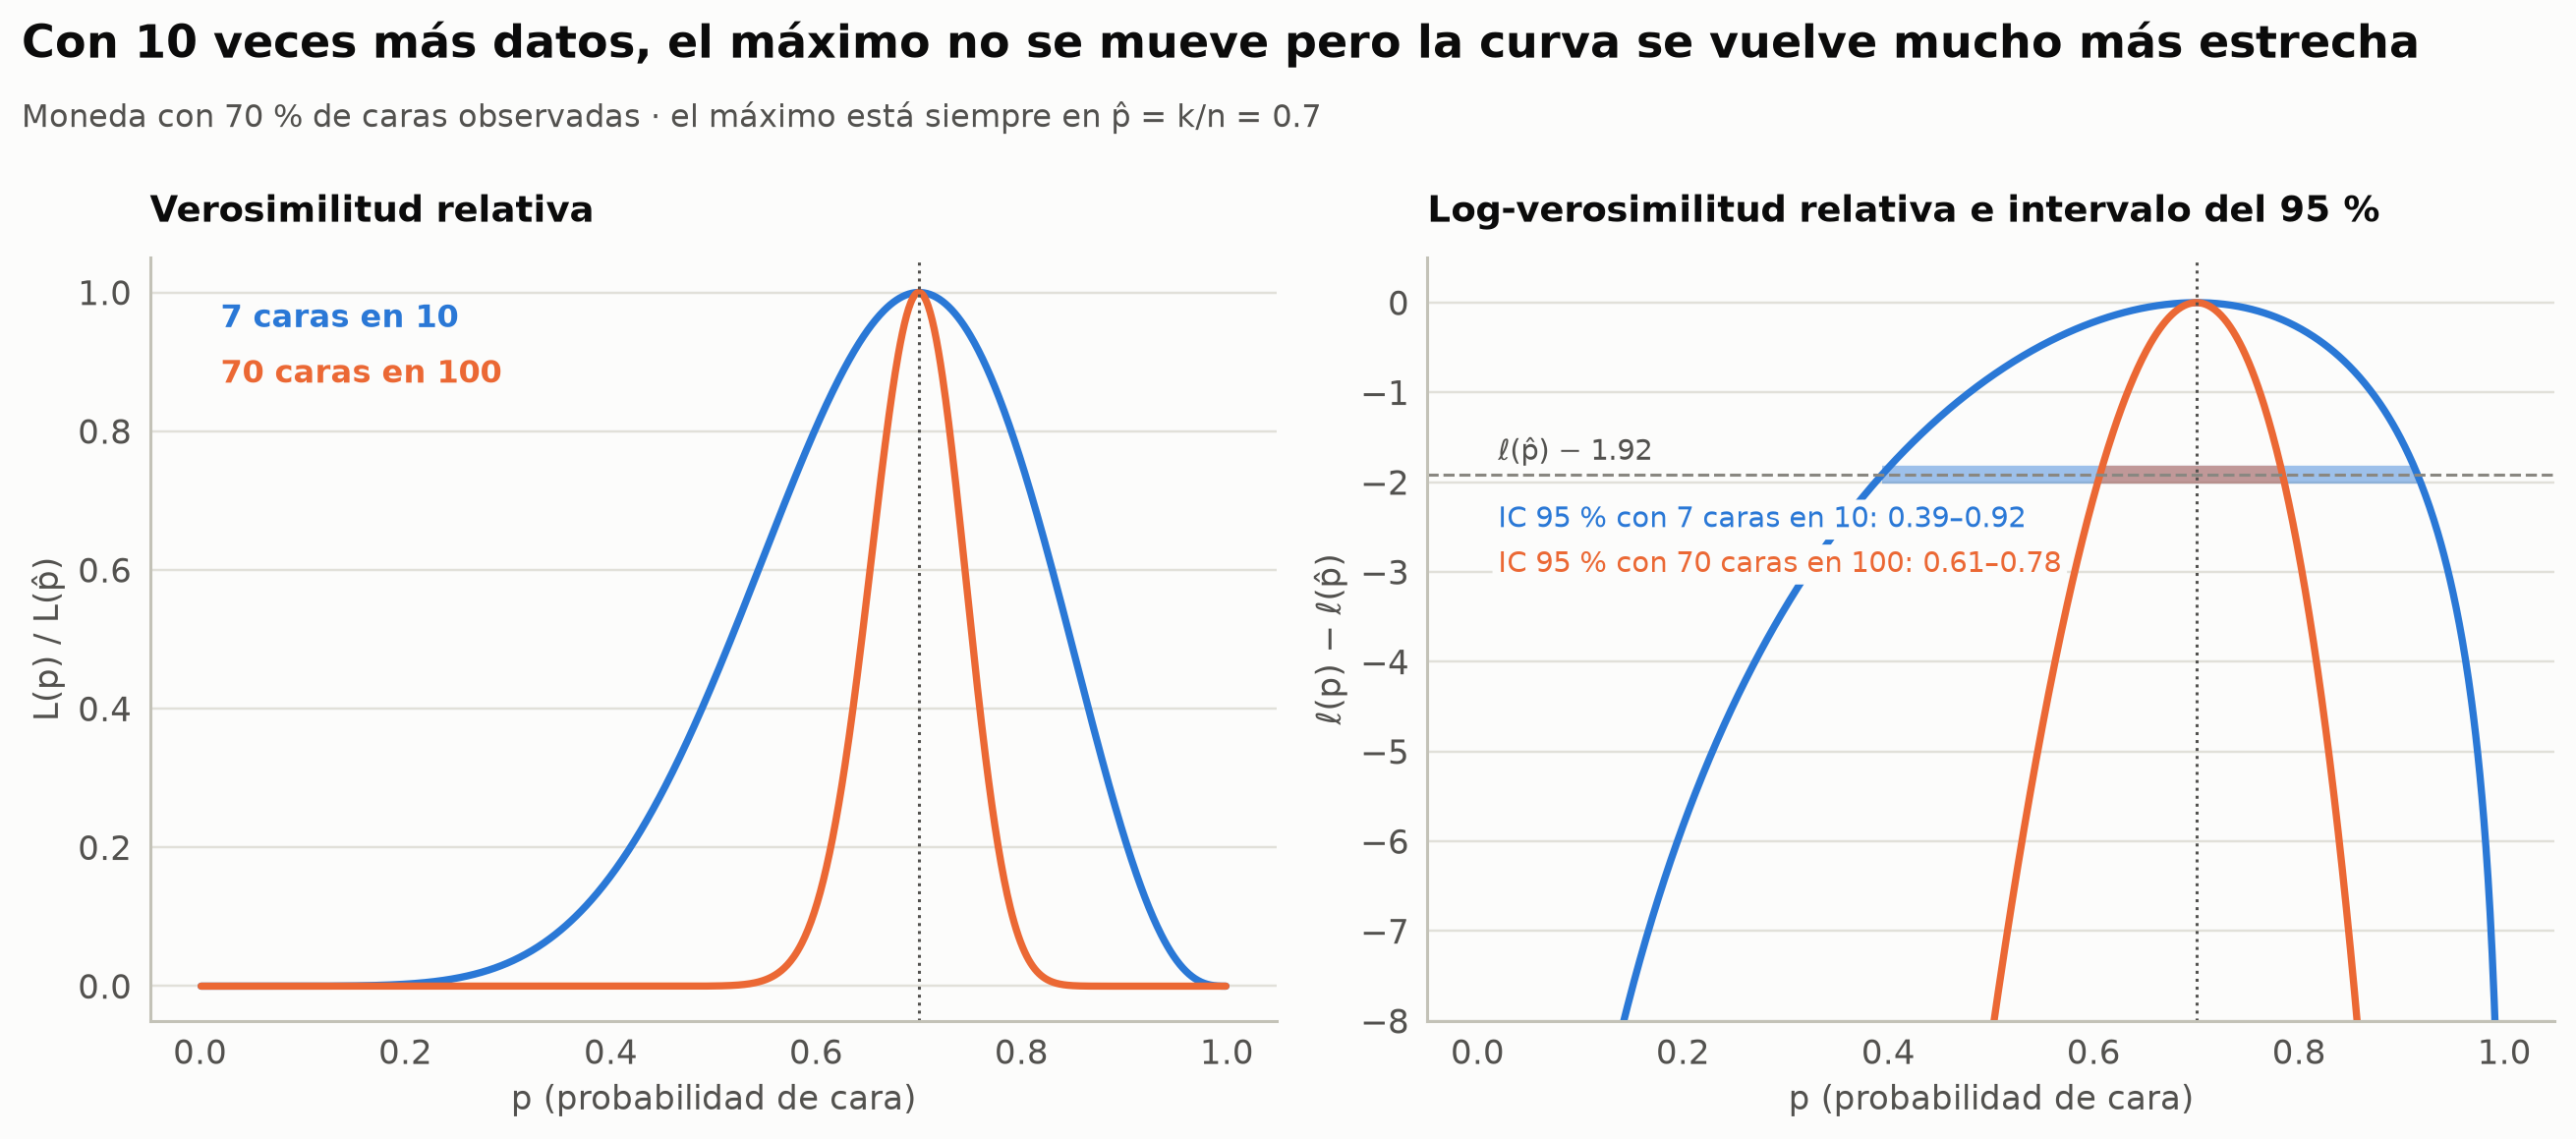

In [2]:
p_grid = np.linspace(0.001, 0.999, 999)

def coin_loglik(p, k, n):
    return k * np.log(p) + (n - k) * np.log(1 - p)

for p in (0.5, 0.7, 0.9):
    print(f"p = {p}:  L = {np.exp(coin_loglik(p, 7, 10)):.6f}   ℓ = {coin_loglik(p, 7, 10):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
cases = [(7, 10, ec.BLUE, "7 caras en 10"), (70, 100, ec.ORANGE, "70 caras en 100")]
for k, n, col, lbl in cases:
    ll = coin_loglik(p_grid, k, n)
    rel = np.exp(ll - ll.max())                      # L(p) / L(p̂): escala común para comparar
    axes[0].plot(p_grid, rel, color=col, lw=2.4)
    axes[0].text(0.02, 0.95 if n == 10 else 0.87, lbl, color=col, fontsize=10.5, fontweight="bold")
    d = ll - ll.max()
    axes[1].plot(p_grid, d, color=col, lw=2.4)
    inside = p_grid[d >= -1.92]
    axes[1].plot([inside.min(), inside.max()], [-1.92, -1.92], color=col, lw=6, alpha=0.45, solid_capstyle="butt")
    axes[1].text(0.02, -2.5 if n == 10 else -3.0, f"IC 95 % con {lbl}: {inside.min():.2f}–{inside.max():.2f}",
                 color=col, fontsize=9.5, bbox=dict(boxstyle="round,pad=0.2", fc=ec.SURFACE, ec="none"))
for ax in axes:
    ax.axvline(0.7, color=ec.INK_2, lw=1, ls=":")
axes[0].set_xlabel("p (probabilidad de cara)"); axes[0].set_ylabel("L(p) / L(p̂)")
axes[0].set_title("Verosimilitud relativa", loc="left", fontsize=12)
axes[1].axhline(-1.92, color=ec.MUTED, lw=1, ls="--")
axes[1].text(0.02, -1.75, "ℓ(p̂) − 1.92", color=ec.INK_2, fontsize=9.5)
axes[1].set_ylim(-8, 0.5); axes[1].set_xlabel("p (probabilidad de cara)"); axes[1].set_ylabel("ℓ(p) − ℓ(p̂)")
axes[1].set_title("Log-verosimilitud relativa e intervalo del 95 %", loc="left", fontsize=12)
ec.fig_title(fig, "Con 10 veces más datos, el máximo no se mueve pero la curva se vuelve mucho más estrecha",
             "Moneda con 70 % de caras observadas · el máximo está siempre en p̂ = k/n = 0.7")
plt.tight_layout(); plt.show()

> 🔎 **Qué observamos.** Ambas curvas alcanzan su máximo en $\hat p = 0.7$. Con 10 lanzamientos, la moneda justa
> ($p = 0.5$) todavía está dentro del intervalo del 95 %: 7 caras de 10 no bastan para acusar a nadie de hacer trampa.
> Con 100 lanzamientos, el intervalo se reduce a un tercio aproximadamente (el ancho baja como $1/\sqrt{n}$, y
> $\sqrt{10} \approx 3.2$) y la moneda justa queda claramente excluida. En filogenética, cada **columna del alineamiento**
> será como un lanzamiento: más sitios, curvas más estrechas.

✅ **Compruebe su comprensión.** ¿Por qué trabajamos con $\ell = \ln L$ y no con $L$? (Respuesta: porque la
verosimilitud de miles de sitios es un producto de miles de números menores que 1, que la computadora redondea a 0;
el logaritmo convierte el producto en una suma manejable, y como es una función creciente, el máximo de $\ell$ está en
el mismo lugar que el de $L$.)

## 2. De la moneda al ADN: verosimilitud de dos secuencias bajo JC69

Ahora el "lanzamiento" es una columna de un alineamiento de dos secuencias, y el parámetro desconocido es el **tiempo
evolutivo** $t$ que las separa (medido en **sustituciones esperadas por sitio**). Si $t$ es pequeño, esperamos casi
todas las columnas iguales; si $t$ es grande, muchas diferentes.

El modelo de **Jukes y Cantor (1969)**, JC69, que ya conocimos en la Lección 5.1, supone que las cuatro bases son igual de frecuentes ($\pi = \tfrac14$) y
que cualquier base cambia a cualquier otra con la misma tasa. Con esos supuestos, la probabilidad de que una base se
**mantenga igual** o **cambie a una base concreta** después de un tiempo $t$ es:

$$
P_{ii}(t) = \tfrac14 + \tfrac34\,e^{-4t/3}
\qquad\qquad
P_{ij}(t) = \tfrac14 - \tfrac14\,e^{-4t/3}\quad (i \neq j)
$$

La verosimilitud de un sitio es "la probabilidad de la base de la primera secuencia" (su frecuencia, $\tfrac14$) por
"la probabilidad de que evolucione hacia la base de la segunda en un tiempo $t$". Si hay $n$ sitios y $k$ diferencias:

$$
\ell(t) \;=\; n\ln\tfrac14 \;+\; (n-k)\,\ln P_{ii}(t) \;+\; k\,\ln P_{ij}(t)
$$

| Símbolo | Significado |
|---|---|
| $t$ | longitud de rama que separa las dos secuencias (sustituciones esperadas por sitio) |
| $P_{ii}(t)$ | probabilidad de que una base siga igual tras un tiempo $t$ |
| $P_{ij}(t)$ | probabilidad de que una base concreta $i$ se haya convertido en otra base concreta $j$ |
| $n,\ k$ | número de sitios y número de sitios diferentes |
| $\hat p = k/n$ | proporción observada de diferencias (distancia $p$) |

### Ejemplo a mano: 20 sitios, 4 diferencias

| $t$ | $P_{ii}(t)$ | $P_{ij}(t)$ | $\ell(t) = 20\ln\tfrac14 + 16\ln P_{ii} + 4\ln P_{ij}$ |
|---|---|---|---|
| 0.10 | 0.9064 | 0.0312 | $-27.726 - 1.573 - 13.868 = -43.167$ |
| **0.2326** | **0.8000** | **0.0667** | $-27.726 - 3.570 - 10.832 = \mathbf{-42.128}$ |
| 0.50 | 0.6351 | 0.1216 | $-43.417$ |

El máximo está en $t \approx 0.2326$. ¿De dónde sale ese número? Si derivamos $\ell(t)$ e igualamos a cero, la condición
es que la probabilidad de observar **alguna** diferencia, $3P_{ij}(t)$, sea igual a la proporción observada:

$$
\tfrac34\left(1 - e^{-4\hat t/3}\right) = \hat p
\quad\Longrightarrow\quad
\boxed{\;\hat t = -\tfrac34 \ln\!\left(1 - \tfrac43\,\hat p\right) = d_{JC}\;}
$$

Con $\hat p = 4/20 = 0.2$: $\hat t = -0.75 \ln(0.7333) = 0.2326$ ✔. ¡Es la **distancia de Jukes-Cantor**! La fórmula que
se usa para corregir las sustituciones múltiples no es un truco aislado: es el **estimador de máxima verosimilitud** de
la distancia bajo JC69. Note también que $P_{ii} = 0.8 = 1 - \hat p$ en el óptimo: el modelo "reproduce" la proporción
de sitios iguales que vimos.

In [3]:
def jc_P(t):
    """Matriz de transición 4x4 de Jukes-Cantor: P[i, j] = probabilidad de pasar de la base i a la j en un tiempo t."""
    e = np.exp(-4.0 * t / 3.0)
    return np.full((4, 4), 0.25 - 0.25 * e) + np.eye(4) * e

def pair_loglik_jc(t, n, k):
    P = jc_P(t)
    return n * np.log(0.25) + (n - k) * np.log(P[0, 0]) + k * np.log(P[0, 1])

def d_jc(p):
    return -0.75 * np.log(1 - 4.0 / 3.0 * p)

print("P(t = 0.1) =\n", jc_P(0.1).round(4))
for t in (0.1, 0.2326, 0.5):
    print(f"t = {t:<6}  ℓ = {pair_loglik_jc(t, 20, 4):.3f}")
res = minimize_scalar(lambda t: -pair_loglik_jc(t, 20, 4), bounds=(1e-6, 5), method="bounded")
print(f"\nÓptimo numérico: t̂ = {res.x:.4f}   ·   fórmula cerrada d_JC(0.2) = {d_jc(0.2):.4f}")

P(t = 0.1) =
 [[0.9064 0.0312 0.0312 0.0312]
 [0.0312 0.9064 0.0312 0.0312]
 [0.0312 0.0312 0.9064 0.0312]
 [0.0312 0.0312 0.0312 0.9064]]
t = 0.1     ℓ = -43.167
t = 0.2326  ℓ = -42.128
t = 0.5     ℓ = -43.417

Óptimo numérico: t̂ = 0.2326   ·   fórmula cerrada d_JC(0.2) = 0.2326


## 3. Los datos reales: 12 primates, dos genes mitocondriales

Para el resto de la clase usaremos un conjunto real y pequeño: los genes mitocondriales del **citocromo *b*** (*CYTB*,
1 140 pb) y de la **subunidad I de la citocromo *c* oxidasa** (*COX1*, 1 536 pb) de 12 primates, tomados de los genomas
mitocondriales de referencia (RefSeq) del NCBI. Son genes codificantes muy usados en filogenia y en *barcoding*, sin
inserciones ni deleciones entre estos primates, así que el alineamiento es directo (se comprobó con MAFFT: los únicos
huecos estaban en los codones de parada, que recortamos).

| Especie | Nombre común | RefSeq |
|---|---|---|
| *Homo sapiens* | humano | NC_012920.1 |
| *Pan troglodytes* | chimpancé | NC_001643.1 |
| *Pan paniscus* | bonobo | NC_001644.1 |
| *Gorilla gorilla* | gorila | NC_011120.1 |
| *Pongo abelii* / *P. pygmaeus* | orangután de Sumatra / de Borneo | NC_002083.1 / NC_001646.1 |
| *Hylobates lar* | gibón de manos blancas | NC_002082.1 |
| *Macaca mulatta* | macaco rhesus | NC_005943.1 |
| *Papio hamadryas* | babuino sagrado | NC_001992.1 |
| *Chlorocebus sabaeus* | mono verde | NC_008066.1 |
| *Callithrix jacchus* | tití común (mono del Nuevo Mundo) | NC_025586.1 |
| *Lemur catta* | lémur de cola anillada (grupo externo) | NC_004025.1 |

¿Por qué no usamos el alineamiento de citocromo *c* de la Lección 4.1? Porque es de **proteínas**: JC69 y sus parientes
son modelos de **nucleótidos**. (En el ejercicio 4 se lo daremos a IQ-TREE, que sí tiene modelos de proteínas.)

La celda lee la copia del curso; si no existe, la reconstruye desde el NCBI extrayendo los dos genes de cada genoma.

In [4]:
ACCESSIONS = {"Homo_sapiens": "NC_012920.1", "Pan_troglodytes": "NC_001643.1", "Pan_paniscus": "NC_001644.1",
              "Gorilla_gorilla": "NC_011120.1", "Pongo_abelii": "NC_002083.1", "Pongo_pygmaeus": "NC_001646.1",
              "Hylobates_lar": "NC_002082.1", "Macaca_mulatta": "NC_005943.1", "Papio_hamadryas": "NC_001992.1",
              "Chlorocebus_sabaeus": "NC_008066.1", "Callithrix_jacchus": "NC_025586.1", "Lemur_catta": "NC_004025.1"}
COMMON = {"Homo_sapiens": "humano", "Pan_troglodytes": "chimpancé", "Pan_paniscus": "bonobo",
          "Gorilla_gorilla": "gorila", "Pongo_abelii": "orangután de Sumatra", "Pongo_pygmaeus": "orangután de Borneo",
          "Hylobates_lar": "gibón", "Macaca_mulatta": "macaco rhesus", "Papio_hamadryas": "babuino",
          "Chlorocebus_sabaeus": "mono verde", "Callithrix_jacchus": "tití", "Lemur_catta": "lémur"}
ALN_FILE = "primates_mt_cytb_cox1.fasta"

def build_from_ncbi():
    """Reconstruye el alineamiento desde el NCBI: CYTB (primeros 1140 nt) + COX1 (primeros 1536 nt)."""
    url = ("https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi?db=nuccore&rettype=gbwithparts&retmode=text&id="
           + ",".join(ACCESSIONS.values()))
    with urllib.request.urlopen(url, timeout=120) as r:
        records = list(SeqIO.parse(io.StringIO(r.read().decode()), "genbank"))
    lines = []
    for rec in records:
        name = "_".join(rec.annotations["organism"].split()[:2])
        genes = {f.qualifiers.get("gene", [""])[0]: str(f.extract(rec.seq)) for f in rec.features if f.type == "CDS"}
        lines.append(f">{name} {rec.id}\n{genes['CYTB'][:1140]}{genes['COX1'][:1536]}")
    return "\n".join(lines).encode()

local = os.path.join("..", "data", ALN_FILE)
if os.path.exists(local):
    aln_bytes = open(local, "rb").read()
else:
    try:
        aln_bytes = build_from_ncbi()
    except Exception as err:
        print("⚠️ NCBI no disponible:", err, "→ uso la copia del repositorio")
        aln_bytes = course_bytes(ALN_FILE)
with open(ALN_FILE, "wb") as fh:          # copia de trabajo (la usará IQ-TREE en la sección 9)
    fh.write(aln_bytes)

aln = AlignIO.read(io.StringIO(aln_bytes.decode()), "fasta")
names = [r.id for r in aln]
X = np.array([[BASES.index(c) for c in str(r.seq).upper()] for r in aln])     # matriz taxones x sitios (A=0…T=3)
n_taxa, n_sites = X.shape
idx = {n: i for i, n in enumerate(names)}
freqs = np.bincount(X.ravel(), minlength=4) / X.size
print(f"{n_taxa} secuencias × {n_sites} sitios")
print("Frecuencias de bases:", dict(zip(BASES, freqs.round(3))))
const = (X == X[0]).all(axis=0)
print(f"Sitios constantes: {const.sum()} ({const.mean():.1%}) · variables: {(~const).sum()}")

12 secuencias × 2676 sitios
Frecuencias de bases: {'A': np.float64(0.278), 'C': np.float64(0.305), 'G': np.float64(0.145), 'T': np.float64(0.272)}
Sitios constantes: 1463 (54.7%) · variables: 1213


Apliquemos la verosimilitud de pares a secuencias reales: el humano contra cada uno de los otros 11 primates, usando
los 2 676 sitios. Para cada par buscamos el máximo numéricamente y lo comparamos con la fórmula de $d_{JC}$.

In [5]:
human = X[idx["Homo_sapiens"]]
pairs = []
for other in names[1:]:
    k = int((X[idx[other]] != human).sum())
    opt = minimize_scalar(lambda t: -pair_loglik_jc(t, n_sites, k), bounds=(1e-6, 5), method="bounded")
    pairs.append(dict(especie=other, comun=COMMON[other], diferencias=k, p=k / n_sites,
                      t_numerico=opt.x, d_JC=d_jc(k / n_sites), logL_max=-opt.fun))
pairs = pd.DataFrame(pairs)
pairs.round(4)

,especie,comun,diferencias,p,t_numerico,d_JC,logL_max
0,Pan_troglodytes,chimpancé,266,0.0994,0.1066,0.1066,-4868.3557
1,Pan_paniscus,bonobo,267,0.0998,0.1071,0.1071,-4871.6561
2,Gorilla_gorilla,gorila,307,0.1147,0.1245,0.1245,-5000.3985
3,Pongo_abelii,orangután de Sumatra,372,0.1390,0.1537,0.1537,-5197.2866
4,Pongo_pygmaeus,orangután de Borneo,389,0.1454,0.1616,0.1616,-5246.5171
5,Hylobates_lar,gibón,417,0.1558,0.1747,0.1747,-5325.7214
6,Macaca_mulatta,macaco rhesus,520,0.1943,0.2249,0.2249,-5598.7356
7,Papio_hamadryas,babuino,544,0.2033,0.2371,0.2371,-5658.5550
8,Chlorocebus_sabaeus,mono verde,541,0.2022,0.2356,0.2356,-5651.1512
9,Callithrix_jacchus,tití,580,0.2167,0.2558,0.2558,-5745.8048


> 🤔 **Antes de ejecutar, prediga:** ¿qué curva de log-verosimilitud será más **ancha** (más incertidumbre sobre $t$):
> la de humano–chimpancé o la de humano–lémur?

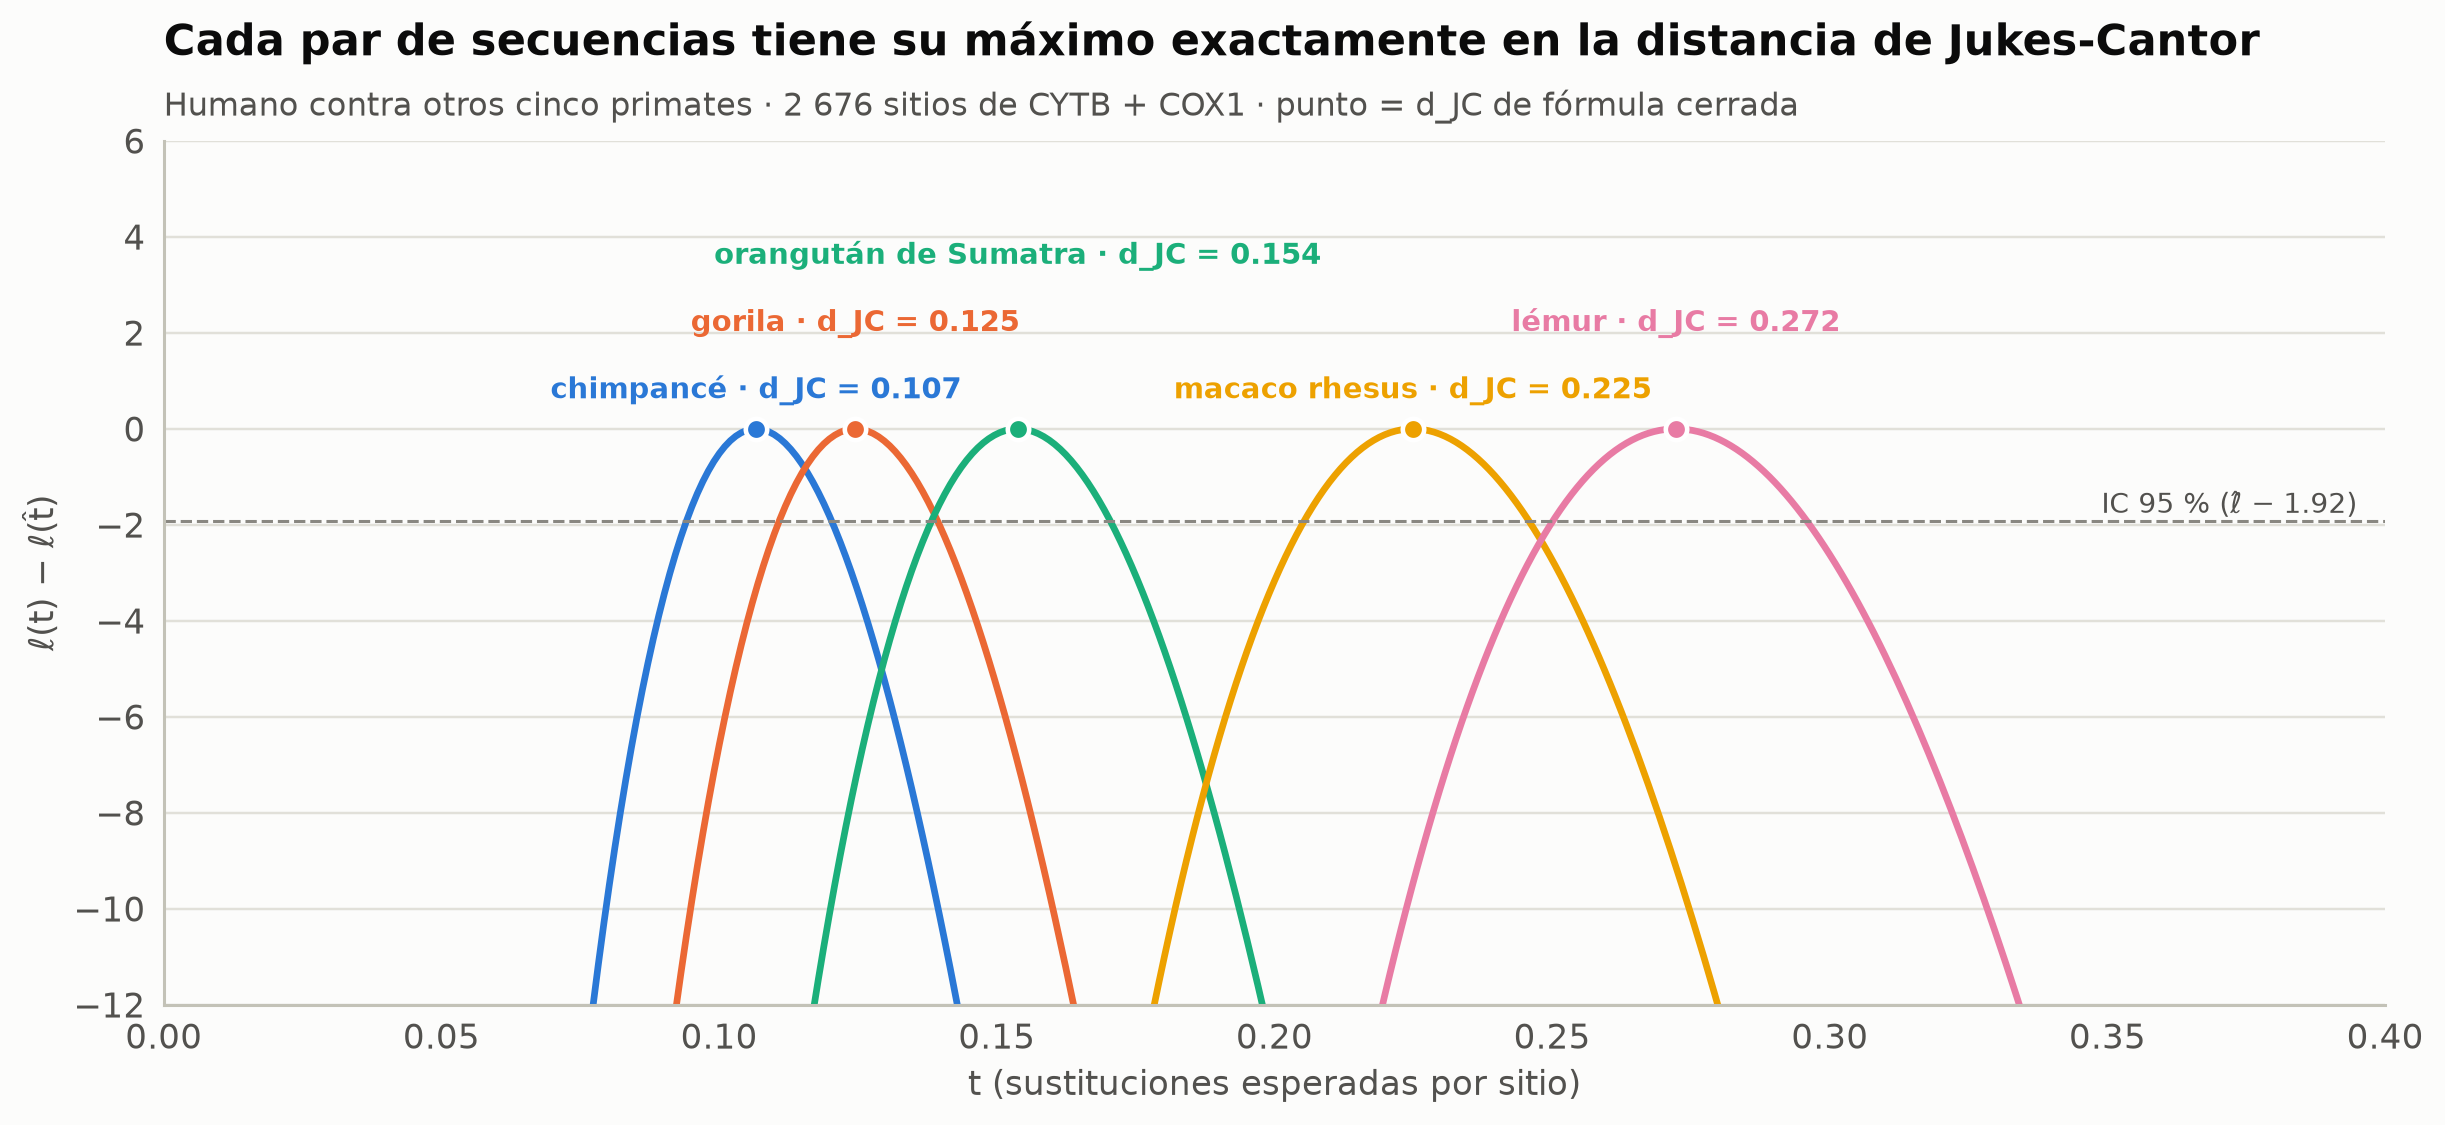

In [6]:
t_grid = np.linspace(0.005, 0.4, 400)
show = ["Pan_troglodytes", "Gorilla_gorilla", "Pongo_abelii", "Macaca_mulatta", "Lemur_catta"]
fig, ax = plt.subplots(figsize=(11, 5))
for sp, col, lev in zip(show, ec.CATEGORICAL, [10, 32, 54, 10, 32]):
    row = pairs.set_index("especie").loc[sp]
    ll = np.array([pair_loglik_jc(t, n_sites, row.diferencias) for t in t_grid]) - row.logL_max
    ax.plot(t_grid, ll, color=col, lw=2.2)
    ax.plot(row.d_JC, 0, "o", color=col, ms=7, mec="white", mew=1.5, zorder=4)
    ax.annotate(f"{row.comun} · d_JC = {row.d_JC:.3f}", (row.d_JC, 0), xytext=(0, lev), textcoords="offset points",
                ha="center", fontsize=9.5, color=col, fontweight="bold")
ax.axhline(-1.92, color=ec.MUTED, ls="--", lw=1)
ax.text(0.395, -1.75, "IC 95 % (ℓ̂ − 1.92)", ha="right", fontsize=9, color=ec.INK_2)
ax.set_ylim(-12, 6); ax.set_xlim(0, 0.4)
ax.set_xlabel("t (sustituciones esperadas por sitio)"); ax.set_ylabel("ℓ(t) − ℓ(t̂)")
ec.title(ax, "Cada par de secuencias tiene su máximo exactamente en la distancia de Jukes-Cantor",
         "Humano contra otros cinco primates · 2 676 sitios de CYTB + COX1 · punto = d_JC de fórmula cerrada")
plt.show()

> 🔎 **Qué observamos.** Los máximos numéricos coinciden con $d_{JC}$ hasta el cuarto decimal (compare las columnas
> `t_numerico` y `d_JC` de la tabla). Las curvas se **ensanchan** a medida que las especies se alejan: con el lémur, la
> fracción de sitios distintos se acerca a la saturación y muchos valores de $t$ explican casi igual de bien los datos.
> Es la misma idea de las sustituciones múltiples: cuando una posición ha cambiado dos o tres veces, las diferencias
> visibles "subestiman" el tiempo, y el modelo tiene que extrapolar con más incertidumbre.

### Explorador interactivo

Pase el cursor por las curvas: verá $t$, $\ell(t)$, la caída respecto del máximo y la fracción de sitios idénticos que
el modelo espera con ese $t$. Haga clic en la leyenda para ocultar o mostrar especies.

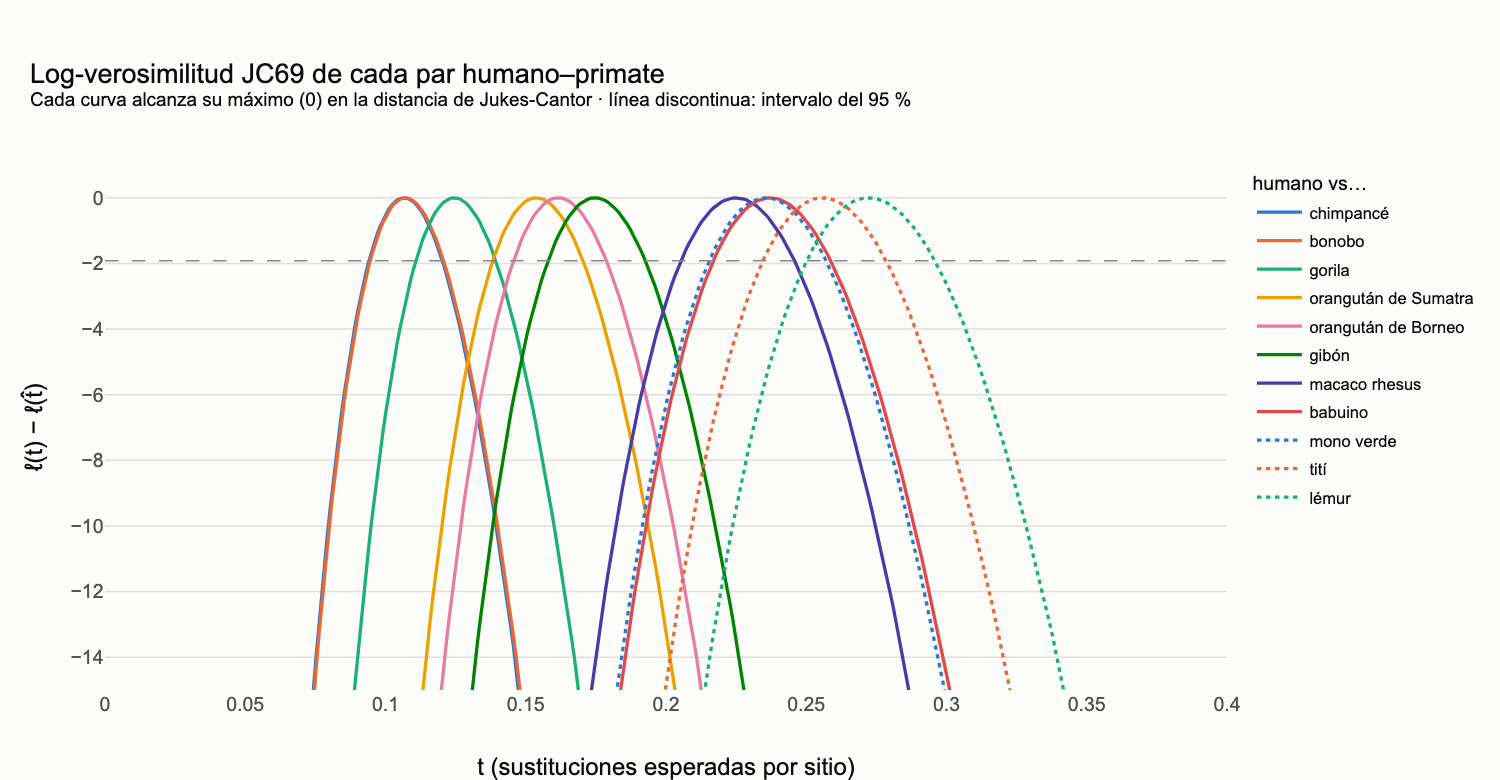

In [7]:
fig = go.Figure()
for i, row in pairs.iterrows():
    ll = np.array([pair_loglik_jc(t, n_sites, row.diferencias) for t in t_grid])
    same = 0.25 + 0.75 * np.exp(-4 * t_grid / 3)
    fig.add_scatter(x=t_grid, y=ll - row.logL_max, mode="lines", name=row.comun,
                    line=dict(width=2.2, color=ec.CATEGORICAL[i % 8], dash="solid" if i < 8 else "dot"),
                    customdata=np.c_[ll, same],
                    hovertemplate=(f"<b>humano vs {row.comun}</b><br>t = %{{x:.3f}} sust./sitio"
                                   "<br>ℓ(t) = %{customdata[0]:.1f}<br>ℓ(t) − ℓ̂ = %{y:.2f}"
                                   "<br>sitios idénticos esperados: %{customdata[1]:.1%}"
                                   f"<br>observados: {1 - row.p:.1%}<extra></extra>"))
fig.add_hline(y=-1.92, line=dict(color=ec.MUTED, dash="dash", width=1))
fig.update_layout(
    title=dict(text="Log-verosimilitud JC69 de cada par humano–primate<br>"
                    "<sup>Cada curva alcanza su máximo (0) en la distancia de Jukes-Cantor · línea discontinua: intervalo del 95 %</sup>"),
    xaxis=dict(title="t (sustituciones esperadas por sitio)", range=[0, 0.4]),
    yaxis=dict(title="ℓ(t) − ℓ(t̂)", range=[-15, 1]), height=520, margin=dict(t=110, l=70, r=30, b=60),
    legend=dict(orientation="v", yanchor="top", y=1, x=1.02, xanchor="left", font=dict(size=11),
                title=dict(text="humano vs…")))
fig.show()

✅ **Compruebe su comprensión.** Si dos secuencias fueran idénticas ($k = 0$), ¿dónde estaría el máximo de $\ell(t)$?
¿Y si $k/n \ge 0.75$? (Respuesta: con $k = 0$, en $t = 0$; con $\hat p \ge 0.75$ el logaritmo de $d_{JC}$ no está
definido y $\ell(t)$ crece sin parar: las secuencias son tan distintas como dos secuencias al azar y **no hay
información** para estimar $t$. Es la saturación.)

## 4. El algoritmo de poda de Felsenstein

Con dos secuencias todo era sencillo. Con un **árbol**, aparece un problema: sólo conocemos las bases de las **hojas**
(las especies actuales). Las bases de los **ancestros** (los nodos internos) no las vio nadie. La verosimilitud tiene
que **sumar sobre todas las posibilidades** de lo que pudo haber en cada ancestro.

Tome el árbol sin raíz de cuatro especies `((humano, chimpancé), (gorila, orangután))`, con ramas terminales de
longitud 0.1 y una rama interna de 0.2. Llamemos $u$ al ancestro de humano y chimpancé, y $v$ al de gorila y
orangután. Para **un sitio** donde vemos `C, C, T, T`:

$$
L_{\text{sitio}} = \sum_{x_u}\sum_{x_v} \pi_{x_u}\;
P_{x_u C}(0.1)\,P_{x_u C}(0.1)\;P_{x_u x_v}(0.2)\;P_{x_v T}(0.1)\,P_{x_v T}(0.1)
$$

Son $4 \times 4 = 16$ términos. Con $m$ ancestros serían $4^m$: para nuestros 12 primates (10 nodos internos)
$4^{10} \approx 10^6$ términos **por sitio**, y para 100 especies, más términos que átomos en el universo.

Joseph Felsenstein (1981) observó que la suma se puede **factorizar**, igual que $ab + ac = a(b + c)$: cada subárbol
se resume en un vector de 4 números, y se trabaja **de las hojas hacia la raíz**, como quien poda un árbol desde las
puntas de las ramas. Para cada nodo $v$ y cada base posible $s$ se define la **verosimilitud parcial**:

$$
L_v(s) \;=\; \prod_{c\,\in\,\text{hijos}(v)} \;\Big[\,\sum_{y \in \{A,C,G,T\}} P_{s\,y}(t_c)\; L_c(y)\Big]
\qquad\qquad
L_{\text{sitio}} = \sum_{s} \pi_s\, L_{\text{raíz}}(s)
$$

| Símbolo | Significado |
|---|---|
| $L_v(s)$ | probabilidad de todo lo observado **por debajo** del nodo $v$, si $v$ tuviera la base $s$ |
| $L_{\text{hoja}}(s)$ | 1 si $s$ es la base observada en esa hoja, 0 si no (un "indicador") |
| $t_c$ | longitud de la rama que une a $v$ con su hijo $c$ |
| $\sum_y P_{sy}(t_c)\,L_c(y)$ | el "mensaje" que el hijo $c$ le manda al padre: suma sobre la base del hijo |
| $\pi_s$ | frecuencia de equilibrio de la base $s$ ($\tfrac14$ en JC69) |

El costo pasa de $4^m$ a $\approx 16\,m$ operaciones por sitio: de exponencial a **lineal** en el número de especies.

### Ejemplo a mano: el sitio `C, C, T, T`

Con JC69: $P_{ii}(0.1) = 0.9064$, $P_{ij}(0.1) = 0.0312$; $P_{ii}(0.2) = 0.8244$, $P_{ij}(0.2) = 0.0585$. Colocamos la
raíz del cálculo en $u$ (como el modelo es reversible, el resultado no depende de dónde la pongamos; lo comprobaremos).

| Paso | A | C | G | T |
|---|---|---|---|---|
| Hojas humano, chimpancé (C) | 0 | 1 | 0 | 0 |
| Hojas gorila, orangután (T) | 0 | 0 | 0 | 1 |
| $L_v(s) = P_{sT}(0.1)^2$ | $0.0312^2 = 0.00097$ | $0.00097$ | $0.00097$ | $0.9064^2 = \mathbf{0.8215}$ |
| Mensaje de $v$ a $u$: $\sum_y P_{sy}(0.2)\,L_v(y)$ | $0.0490$ | $0.0490$ | $0.0490$ | $\mathbf{0.6775}$ |
| $L_u(s) = P_{sC}(0.1)^2 \times$ mensaje | $0.000048$ | $\mathbf{0.04025}$ | $0.000048$ | $0.00066$ |

Por ejemplo, el mensaje para $s = A$ es $P_{AT}(0.2)\cdot 0.8215 + [P_{AA} + P_{AC} + P_{AG}](0.2)\cdot 0.00097 =
0.0585 \times 0.8215 + 0.9415 \times 0.00097 = 0.0490$.

Finalmente $L_{\text{sitio}} = \tfrac14(0.000048 + 0.04025 + 0.000048 + 0.00066) = \mathbf{0.01025}$, es decir,
$\ell = \ln 0.01025 = -4.580$. La tabla dice además algo interesante: el ancestro $u$ tenía casi seguro una **C** (su
columna domina), y $v$, una **T**.

In [8]:
E = np.eye(4)                                  # vectores de las hojas: fila b = indicador de la base b
C, T = BASES.index("C"), BASES.index("T")
P01, P02 = jc_P(0.1), jc_P(0.2)

L_v = (P01 @ E[T]) * (P01 @ E[T])              # hijos gorila y orangután
msg = P02 @ L_v                                 # mensaje de v hacia u por la rama interna
L_u = (P01 @ E[C]) * (P01 @ E[C]) * msg         # hijos humano, chimpancé y el mensaje de v
site_L = 0.25 * L_u.sum()
print(pd.DataFrame([L_v, msg, L_u], index=["L_v", "mensaje v→u", "L_u"], columns=list(BASES)).round(6))
print(f"\nPoda:        L = {site_L:.6f}   ℓ = {np.log(site_L):.4f}")

# Comprobación por fuerza bruta: sumar los 16 términos (x_u, x_v)
brute = sum(0.25 * P01[xu, C] ** 2 * P02[xu, xv] * P01[xv, T] ** 2 for xu in range(4) for xv in range(4))
print(f"Fuerza bruta: L = {brute:.6f}   (16 términos)")

                    A         C         G         T
L_v          0.000974  0.000974  0.000974  0.821525
mensaje v→u  0.048991  0.048991  0.048991  0.677474
L_u          0.000048  0.040247  0.000048  0.000660

Poda:        L = 0.010251   ℓ = -4.5804
Fuerza bruta: L = 0.010251   (16 términos)


Dibujemos la tabla sobre el árbol. Cada nodo lleva su vector de cuatro barras (A, C, G, T): la altura es proporcional
al valor dentro de ese nodo y el número encima es la verosimilitud parcial.

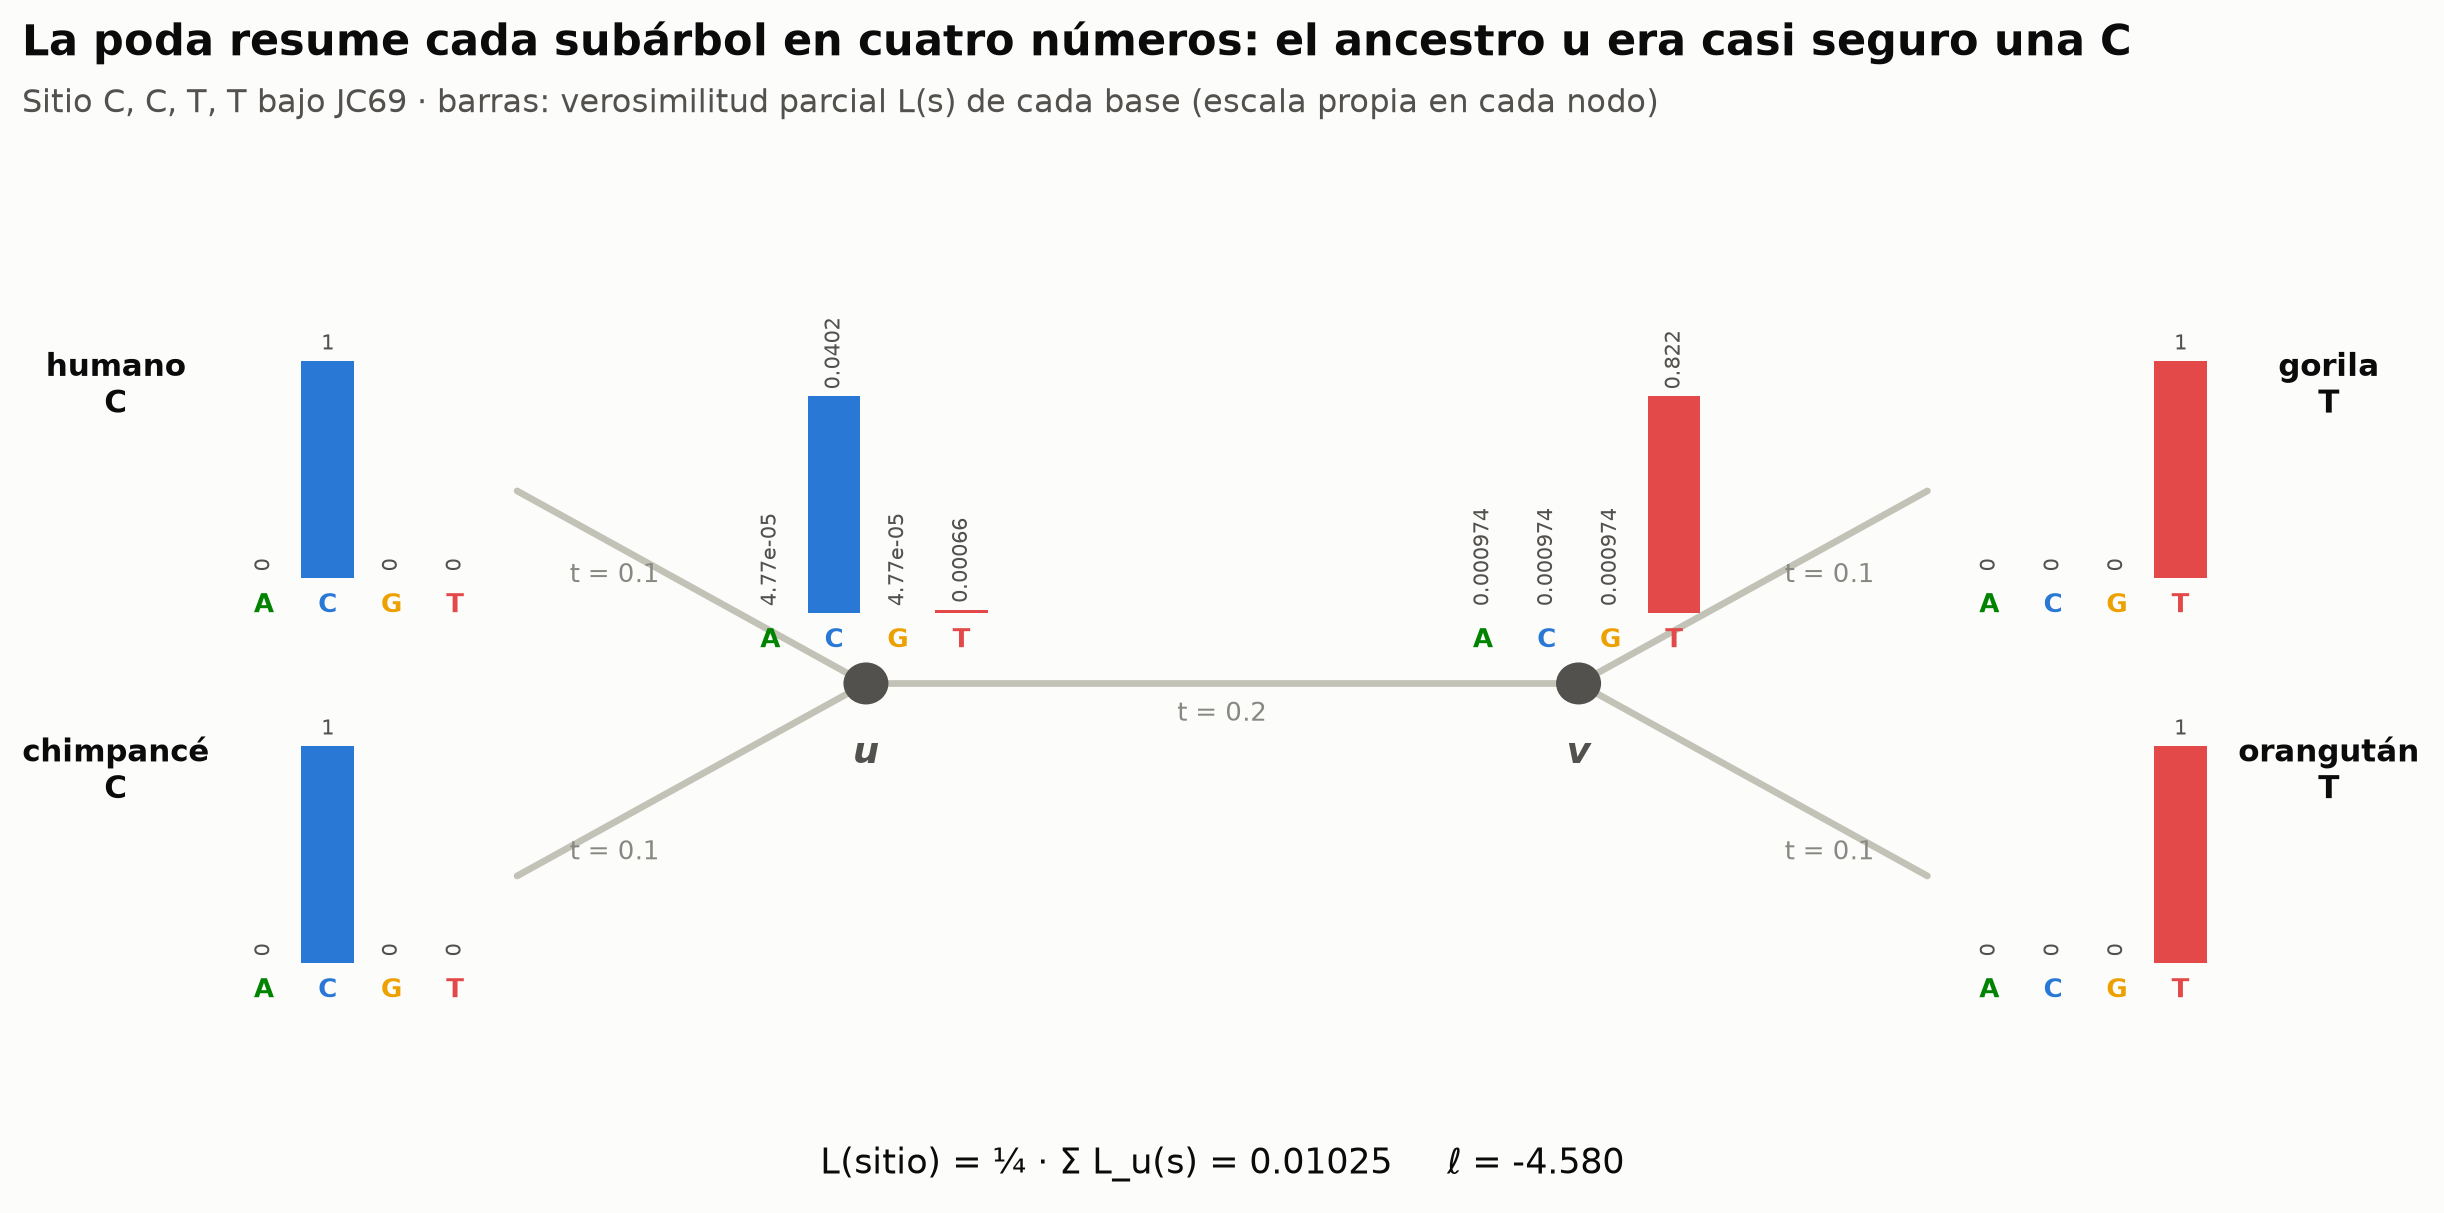

In [9]:
PR_POS = {"humano": (0.0, 3.0), "chimpancé": (0.0, 1.9), "gorila": (4.6, 3.0), "orangután": (4.6, 1.9),
          "u": (1.35, 2.45), "v": (3.25, 2.45)}
PR_EDGES = [("u", "humano", 0.1), ("u", "chimpancé", 0.1), ("u", "v", 0.2), ("v", "gorila", 0.1), ("v", "orangután", 0.1)]

def pruning_vectors(tips):
    """tips = bases de (humano, chimpancé, gorila, orangután). Devuelve los vectores de cada nodo."""
    h, c, g, o = [E[BASES.index(b)] for b in tips]
    Lv = (P01 @ g) * (P01 @ o)
    m = P02 @ Lv
    Lu = (P01 @ h) * (P01 @ c) * m
    return {"humano": h, "chimpancé": c, "gorila": g, "orangután": o, "v": Lv, "msg": m, "u": Lu}

def draw_vector(ax, x, y, vec, scale=1.0, alpha=1.0, w=0.17, hmax=0.62, fmt="{:.3g}"):
    top = max(vec.max(), 1e-12)
    arts = []
    for j, b in enumerate(BASES):
        xx = x - 2 * w + j * w
        h = hmax * vec[j] / top * scale
        arts.append(ax.add_patch(Rectangle((xx + 0.015, y), w - 0.03, h, fc=ec.NUC_COLORS[b], alpha=alpha, lw=0, zorder=3)))
        arts.append(ax.text(xx + w / 2, y - 0.04, b, ha="center", va="top", fontsize=8.5, color=ec.NUC_COLORS[b],
                            fontweight="bold", zorder=3))
        if scale > 0.999:
            arts.append(ax.text(xx + w / 2, y + h + 0.02, fmt.format(vec[j]) if vec[j] > 0 else "0", ha="center",
                                va="bottom", fontsize=6.8, color=ec.INK_2, rotation=90 if vec[j] < 1 else 0, zorder=3))
    return arts

def draw_pruning_skeleton(ax, tips):
    ax.set_xlim(-0.9, 5.5); ax.set_ylim(1.0, 4.0); ax.axis("off")
    for a, b, t in PR_EDGES:
        (x1, y1), (x2, y2) = PR_POS[a], PR_POS[b]
        if b in ("humano", "chimpancé"):
            x2 += 0.42
        elif b in ("gorila", "orangután"):
            x2 -= 0.42
        ax.plot([x1, x2], [y1, y2], color=ec.BASELINE, lw=2.2, zorder=1)
        f = 0.5 if b == "v" else 0.72
        ax.text(x1 + f * (x2 - x1), y1 + f * (y2 - y1) - 0.05, f"t = {t}", fontsize=8.5, color=ec.MUTED, ha="center", va="top")
    for name, base in zip(["humano", "chimpancé", "gorila", "orangután"], tips):
        x, y = PR_POS[name]
        ax.text(x + (-0.65 if x < 1 else 0.65), y + 0.3, f"{name}\n{base}", ha="center", va="center", fontsize=10,
                color=ec.INK, fontweight="bold")
    for name in ("u", "v"):
        x, y = PR_POS[name]
        ax.add_patch(Circle((x, y), 0.06, fc=ec.INK_2, ec="white", zorder=4))
        ax.text(x, y - 0.2, name, ha="center", va="center", fontsize=12, color=ec.INK_2, style="italic",
                fontweight="bold")

site_tips = "CCTT"
vecs = pruning_vectors(site_tips)
fig, ax = plt.subplots(figsize=(11, 5.4))
draw_pruning_skeleton(ax, site_tips)
for name in ["humano", "chimpancé", "gorila", "orangután", "u", "v"]:
    x, y = PR_POS[name]
    draw_vector(ax, x, y + 0.2 if name in "uv" else y - 0.25, vecs[name])
L_site = 0.25 * vecs["u"].sum()
ax.text(2.3, 1.05, f"L(sitio) = ¼ · Σ L_u(s) = {L_site:.5f}     ℓ = {np.log(L_site):.3f}", ha="center", fontsize=11.5,
        color=ec.INK, bbox=dict(boxstyle="round,pad=0.4", fc=ec.SURFACE, ec=ec.BASELINE))
ec.title(ax, "La poda resume cada subárbol en cuatro números: el ancestro u era casi seguro una C",
         "Sitio C, C, T, T bajo JC69 · barras: verosimilitud parcial L(s) de cada base (escala propia en cada nodo)")
plt.show()

> 🔎 **Qué observamos.** En las hojas los vectores son indicadores (una sola barra). Al subir, cada nodo interno
> "mezcla" la información de sus hijos: en $v$ domina la T (los dos hijos tienen T) y en $u$ domina la C, pero las otras
> bases **no son cero**: el modelo admite, con baja probabilidad, que el ancestro tuviera otra base y que ambos hijos
> cambiaran de forma independiente. Esa es la gran diferencia con la parsimonia, que sólo cuenta cambios mínimos.

## 🎬 Animación: la poda sube de las hojas a la raíz

Veamos el cálculo paso a paso para dos sitios: el que acabamos de hacer (`C, C, T, T`, que **concuerda** con el árbol
porque agrupa humano con chimpancé) y uno que lo **contradice** (`C, T, C, T`, que agrupa humano con gorila).

![El algoritmo de poda de Felsenstein: los vectores de verosimilitud parcial suben de las hojas a la raíz; el sitio que contradice al árbol obtiene una verosimilitud unas 29 veces menor](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-05-filogenetica/5.3_poda_felsenstein.gif)

*El algoritmo de poda de Felsenstein: los vectores de verosimilitud parcial suben de las hojas a la raíz; el sitio que contradice al árbol obtiene una verosimilitud unas 29 veces menor*

In [10]:
sites_anim = ["CCTT", "CTCT"]
steps = [("hojas", 3), ("v", 8), ("msg", 4), ("u", 8), ("final", 5)]          # 28 cuadros por sitio
plan = [(s, step, k, n) for s in sites_anim for step, n in steps for k in range(n)]

fig, ax = plt.subplots(figsize=(11, 5.4))

def update(f):
    site, step, k, n = plan[f]
    ax.clear()
    draw_pruning_skeleton(ax, site)
    V = pruning_vectors(site)
    order = [s for s, _ in steps]
    done = order.index(step)
    prog = (k + 1) / n
    for name in ["humano", "chimpancé", "gorila", "orangután"]:
        x, y = PR_POS[name]
        draw_vector(ax, x, y - 0.25, V[name], scale=prog if step == "hojas" else 1.0)
    if done >= 1:
        x, y = PR_POS["v"]
        draw_vector(ax, x, y + 0.2, V["v"], scale=prog if step == "v" else 1.0)
    if step == "msg":
        (x1, y1), (x2, y2) = PR_POS["v"], PR_POS["u"]
        ax.annotate("", (x2 + 0.15, y2 - 0.1), (x1 - 0.15, y1 - 0.1),
                    arrowprops=dict(arrowstyle="-|>", color=ec.ORANGE, lw=2.5, mutation_scale=18), zorder=5)
        ax.text(2.3, 1.95, "mensaje: " + "  ".join(f"{b}={v:.3f}" for b, v in zip(BASES, V["msg"])), ha="center",
                fontsize=9.5, color=ec.ORANGE)
    if done >= 3:
        x, y = PR_POS["u"]
        draw_vector(ax, x, y + 0.2, V["u"], scale=prog if step == "u" else 1.0)
    texts = {"hojas": "1. Hojas: un 1 en la base observada, 0 en las demás",
             "v": "2. Nodo v: L_v(s) = [Σ_y P_sy(0.1) L_gor(y)] · [Σ_y P_sy(0.1) L_ora(y)]",
             "msg": "3. La rama interna (t = 0.2) transforma L_v en un mensaje para u",
             "u": "4. Nodo u: producto de los mensajes de humano, chimpancé y v",
             "final": ""}
    L = 0.25 * V["u"].sum()
    if step == "final":
        texts["final"] = f"5. L(sitio) = ¼ Σ L_u(s) = {L:.5f}   (ℓ = {np.log(L):.2f})"
    ax.text(-0.85, 3.95, f"Sitio {' '.join(site)}", fontsize=13, fontweight="bold", color=ec.INK, va="top")
    ax.text(-0.85, 1.02, texts[step], fontsize=10.5, color=ec.INK, va="bottom")
    ax.set_title("Algoritmo de poda de Felsenstein bajo JC69 (árbol ((humano, chimpancé), (gorila, orangután)))",
                 fontsize=11.5, loc="left")
    return []

ec.animate(fig, update, frames=len(plan), interval=260, name="5.3_poda_felsenstein")

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** El sitio `C, T, C, T` produce en $u$ un vector con **dos** barras parecidas (C y T): el
> ancestro es ambiguo, y para explicar el patrón el modelo necesita **dos** cambios independientes. Su verosimilitud
> ($\approx 0.00036$) es unas **29 veces** menor que la de `C, C, T, T` ($\approx 0.0103$). Así es como un árbol
> "vota": los sitios que agrupan humano con chimpancé favorecen esta topología; los que agrupan humano con gorila
> favorecen otra. La verosimilitud total del alineamiento es el **producto** sobre todos los sitios (la **suma** de los
> $\ell$), así que cada columna aporta su voto ponderado.

✅ **Compruebe su comprensión.** Para el sitio `C, C, C, C`, ¿qué base dominará en $u$? ¿Será $L_{\text{sitio}}$ mayor
o menor que 0.01025? (Respuesta: C, con $L_u(C) \approx 0.557$ y $L_{\text{sitio}} \approx 0.139$: un sitio constante no
requiere ningún cambio y es el patrón más probable de todos.)

## 5. La verosimilitud de un árbol completo y sus longitudes de rama

Programemos la poda para cualquier árbol y cualquier número de sitios. Tres ideas la hacen eficiente:

1. **Recursión.** La verosimilitud parcial de un nodo sólo necesita las de sus hijos: una función que se llama a sí misma
   sobre `clade.clades` (los hijos en `Bio.Phylo`) recorre el árbol de las hojas a la raíz.
2. **Todos los sitios a la vez.** En vez de un vector de 4 números por nodo, usamos una matriz de
   (número de sitios × 4), y el "mensaje" de un hijo es un producto de matrices: `L_hijo @ P.T`.
3. **Patrones repetidos.** Dos columnas idénticas tienen la misma verosimilitud. Basta calcular cada **patrón** una vez
   y multiplicar su $\ell$ por el número de veces que aparece: $\ell = \sum_{\text{patrones}} n_p\,\ln L_p$.

Además, generalizamos la matriz $P(t)$. Los modelos que compararemos se describen con una **matriz de tasas** $Q$
(la velocidad instantánea de cada cambio), y $P(t) = e^{Qt}$:

| Modelo | Supuestos | Parámetros libres además de las ramas |
|---|---|---|
| **JC69** (Jukes y Cantor 1969) | bases equifrecuentes, todos los cambios con la misma tasa | 0 |
| **K80** (Kimura 1980) | las **transiciones** (A↔G, C↔T) tienen tasa $\kappa$ veces mayor que las transversiones | 1 ($\kappa$) |
| **HKY** (Hasegawa, Kishino y Yano 1985) | como K80, pero con frecuencias de bases $\pi$ desiguales (aquí, las observadas) | 1 + 3 |
| **HKY+Γ** (Yang 1994) | además, cada sitio evoluciona a su propia velocidad, tomada de una distribución gamma de forma $\alpha$ (4 categorías) | 1 + 3 + 1 |

$$
Q_{ij} = \mu \times
\begin{cases}
\kappa\,\pi_j & \text{si } i \to j \text{ es una transición}\\
\pi_j & \text{si es una transversión}
\end{cases}
\qquad
P(t) = e^{Qt} = D^{-1/2}\,U\,e^{\Lambda t}\,U^{\top} D^{1/2}
$$

| Símbolo | Significado |
|---|---|
| $\kappa$ | cociente de tasas transición/transversión ($\kappa = 1$ y $\pi_j = \tfrac14$ recuperan JC69) |
| $\mu$ | constante que normaliza $Q$ para que $t$ se mida en sustituciones esperadas por sitio |
| $D = \mathrm{diag}(\pi)$, $U$, $\Lambda$ | la matriz simétrica $D^{1/2} Q D^{-1/2}$ se diagonaliza como $U \Lambda U^\top$: así $e^{Qt}$ cuesta sólo una multiplicación |
| $\alpha$ | forma de la gamma: $\alpha < 1$ significa que muchos sitios casi no cambian y unos pocos cambian muchísimo |

In [11]:
TRANSITIONS = [(0, 2), (2, 0), (1, 3), (3, 1)]          # A↔G, C↔T

def gamma_rates(alpha, ncat=4):
    """Tasas medias de las ncat categorías de igual probabilidad de una gamma con media 1 (Yang 1994)."""
    cuts = gamma_dist.ppf(np.arange(1, ncat) / ncat, alpha, scale=1 / alpha)
    upper = np.r_[gammainc(alpha + 1, cuts * alpha), 1.0]
    lower = np.r_[0.0, gammainc(alpha + 1, cuts * alpha)]
    return ncat * (upper - lower)

def substitution_model(kappa=1.0, pi=(0.25, 0.25, 0.25, 0.25), alpha=None, ncat=4):
    """Modelo HKY general (JC69 y K80 son casos particulares). Guarda la diagonalización de Q."""
    pi = np.asarray(pi, dtype=float)
    R = np.ones((4, 4))
    for i, j in TRANSITIONS:
        R[i, j] = kappa
    Q = R * pi[None, :]
    np.fill_diagonal(Q, 0.0)
    np.fill_diagonal(Q, -Q.sum(axis=1))
    Q /= -(pi * np.diag(Q)).sum()                       # tasa media = 1 sustitución por unidad de tiempo
    s = np.sqrt(pi)
    lam, U = np.linalg.eigh((s[:, None] * Q) / s[None, :])
    rates = gamma_rates(alpha, ncat) if alpha else np.array([1.0])
    return dict(Q=Q, pi=pi, lam=lam, U=U, s=s, rates=rates, kappa=kappa, alpha=alpha)

def P_matrix(model, t):
    lam, U, s = model["lam"], model["U"], model["s"]
    return ((U * np.exp(lam * t)) @ U.T) / s[:, None] * s[None, :]

JC = substitution_model()
print("¿P(t) de la diagonalización = fórmula de JC69?", np.allclose(P_matrix(JC, 0.1), jc_P(0.1)))
print("Filas de P suman 1:", np.allclose(P_matrix(substitution_model(5, freqs), 0.3).sum(1), 1))

¿P(t) de la diagonalización = fórmula de JC69? True
Filas de P suman 1: True


In [12]:
def compress(taxa):
    """Patrones de columnas únicos para una lista de taxones: (patrones, cuántas veces aparece cada uno,
    columna de cada taxón, índice de patrón de cada columna original)."""
    sub = X[[idx[t] for t in taxa]]
    pats, inverse, counts = np.unique(sub.T, axis=0, return_inverse=True, return_counts=True)
    return dict(pats=pats, w=counts.astype(float), col={t: i for i, t in enumerate(taxa)}, inverse=inverse.ravel())

DATA = compress(names)
print(f"{n_sites} columnas → {len(DATA['w'])} patrones distintos "
      f"(el patrón más frecuente aparece {DATA['w'].max():.0f} veces: una columna constante)")

def site_logliks(tree, model, data=DATA):
    """ln L de cada patrón con el algoritmo de poda (recursivo, todos los patrones a la vez)."""
    pats, col = data["pats"], data["col"]
    total = np.zeros(len(pats))
    for r in model["rates"]:                             # sin gamma hay una sola categoría (r = 1)
        def partial(clade):
            if clade.is_terminal():
                return np.eye(4)[pats[:, col[clade.name]]]           # hojas: indicadores
            out = np.ones((len(pats), 4))
            for child in clade.clades:
                out *= partial(child) @ P_matrix(model, child.branch_length * r).T   # mensaje del hijo
            return out
        total += partial(tree.root) @ model["pi"]
    return np.log(total / len(model["rates"]))

def tree_loglik(tree, model, data=DATA):
    return float((data["w"] * site_logliks(tree, model, data)).sum())

def newick_tree(s):
    return Phylo.read(io.StringIO(s), "newick")

# 1) Reproducir el ejemplo a mano con la función general
four = ["Homo_sapiens", "Pan_troglodytes", "Gorilla_gorilla", "Pongo_abelii"]
toy = dict(pats=np.array([[1, 1, 3, 3], [1, 3, 1, 3]]), w=np.array([1.0, 1.0]), col={t: i for i, t in enumerate(four)})
t_u = newick_tree("(Homo_sapiens:0.1,Pan_troglodytes:0.1,(Gorilla_gorilla:0.1,Pongo_abelii:0.1):0.2);")
print("L de los sitios CCTT y CTCT:", np.exp(site_logliks(t_u, JC, toy)).round(6))

# 2) Principio de la polea: mover la raíz a la mitad de la rama interna no cambia nada
t_mid = newick_tree("((Homo_sapiens:0.1,Pan_troglodytes:0.1):0.07,(Gorilla_gorilla:0.1,Pongo_abelii:0.1):0.13);")
print("Raíz en u:                ", np.exp(site_logliks(t_u, JC, toy)).round(6))
print("Raíz dentro de la rama u–v:", np.exp(site_logliks(t_mid, JC, toy)).round(6))

2676 columnas → 863 patrones distintos (el patrón más frecuente aparece 462 veces: una columna constante)
L de los sitios CCTT y CTCT: [0.010251 0.000357]
Raíz en u:                 [0.010251 0.000357]
Raíz dentro de la rama u–v: [0.010251 0.000357]


> 🔎 **Qué observamos.** La función general reproduce los números hechos a mano, y mover la raíz a cualquier punto de
> la rama interna (0.07 + 0.13 = 0.2) da **exactamente** la misma verosimilitud. Felsenstein lo llamó el **principio
> de la polea** (*pulley principle*): en un modelo reversible, la verosimilitud sólo depende del árbol **sin raíz**.
> Por eso los programas de máxima verosimilitud devuelven árboles sin raíz, y la raíz se pone después con un **grupo
> externo** (aquí, el lémur).

### Un árbol de partida y la optimización de las ramas

Para evaluar la verosimilitud necesitamos una topología y unas longitudes de rama. Un buen punto de partida es un
árbol de **Neighbor-Joining** (NJ; Saitou y Nei 1987, Lección 5.2) sobre distancias $d_{JC}$: en cada paso une el par de nodos
que minimiza $Q_{ij} = (n-2)\,d_{ij} - \sum_k d_{ik} - \sum_k d_{jk}$. Lo programamos de forma compacta (lo usaremos
también en el bootstrap).

Luego dejamos que `scipy.optimize.minimize` (método L-BFGS-B) ajuste las 21 longitudes de rama para **maximizar**
$\ell$ (minimizando $-\ell$). Optimizamos el **logaritmo** de cada longitud: así nunca se vuelve negativa.

In [13]:
PAIR_MISMATCH = (DATA["pats"][:, :, None] != DATA["pats"][:, None, :]).astype(float)   # patrones x taxones x taxones

def jc_distance_matrix(w):
    """Matriz de distancias JC69 a partir de los pesos (conteos) de cada patrón."""
    p = np.einsum("p,pij->ij", w, PAIR_MISMATCH) / w.sum()
    return -0.75 * np.log(np.clip(1 - 4 / 3 * p, 1e-9, None))

def neighbor_joining(D, labels):
    """Neighbor-Joining (Saitou y Nei 1987). Devuelve un árbol sin raíz en formato Newick."""
    D = np.array(D, dtype=float); nodes = list(labels)
    while len(nodes) > 3:
        n = len(nodes); r = D.sum(axis=1)
        Qm = (n - 2) * D - r[:, None] - r[None, :]
        np.fill_diagonal(Qm, np.inf)
        i, j = np.unravel_index(Qm.argmin(), Qm.shape)
        bi = 0.5 * D[i, j] + (r[i] - r[j]) / (2 * (n - 2)); bj = D[i, j] - bi
        new = f"({nodes[i]}:{max(bi, 1e-6):.6f},{nodes[j]}:{max(bj, 1e-6):.6f})"
        d_new = 0.5 * (D[i] + D[j] - D[i, j])
        keep = [k for k in range(n) if k not in (i, j)]
        D = np.block([[D[np.ix_(keep, keep)], d_new[keep][:, None]], [d_new[keep][None, :], np.zeros((1, 1))]])
        nodes = [nodes[k] for k in keep] + [new]
    a, b, c = nodes
    da = 0.5 * (D[0, 1] + D[0, 2] - D[1, 2])
    return f"({a}:{max(da, 1e-6):.6f},{b}:{max(D[0, 1] - da, 1e-6):.6f},{c}:{max(D[0, 2] - da, 1e-6):.6f});"

D_jc = jc_distance_matrix(DATA["w"])
nj_newick = neighbor_joining(D_jc, names)
nj_tree = newick_tree(nj_newick)
print("Árbol NJ:", nj_newick[:120], "…")
print(f"ℓ del árbol NJ (JC69, ramas de NJ): {tree_loglik(nj_tree, JC):.2f}")

Árbol NJ: ((Pongo_abelii:0.033901,Pongo_pygmaeus:0.034933):0.051474,(Gorilla_gorilla:0.059182,(Homo_sapiens:0.053947,(Pan_troglody …
ℓ del árbol NJ (JC69, ramas de NJ): -17577.62


In [14]:
MODEL_SPECS = {"JC69": dict(kappa=False, freqs=False, gamma=False),
               "K80": dict(kappa=True, freqs=False, gamma=False),
               "HKY": dict(kappa=True, freqs=True, gamma=False),
               "HKY+Γ": dict(kappa=True, freqs=True, gamma=True)}

def fit_tree(tree, model_name, data=DATA, trace=None):
    """Optimiza por máxima verosimilitud las longitudes de rama (y κ, α) de un árbol de topología fija.
    Modifica las ramas del árbol y devuelve (ℓ máxima, modelo ajustado, número de parámetros libres)."""
    spec = MODEL_SPECS[model_name]
    clades = [c for c in tree.find_clades() if c is not tree.root]
    pi = freqs if spec["freqs"] else np.full(4, 0.25)
    nb_ = len(clades)

    def unpack(x):
        for c, v in zip(clades, np.exp(x[:nb_])):
            c.branch_length = v
        extra = list(np.exp(x[nb_:]))
        kappa = extra.pop(0) if spec["kappa"] else 1.0
        alpha = extra.pop(0) if spec["gamma"] else None
        return substitution_model(kappa, pi, alpha)

    def neg_loglik(x):
        val = -tree_loglik(tree, unpack(x), data)
        if trace is not None:
            trace.append(-val)
        return val

    x0 = [np.log(max(c.branch_length or 0.05, 1e-3)) for c in clades]
    bounds = [(-12.0, 1.5)] * nb_
    if spec["kappa"]:
        x0.append(np.log(4.0)); bounds.append((-3.0, 5.0))
    if spec["gamma"]:
        x0.append(np.log(0.5)); bounds.append((-4.0, 4.0))
    res = minimize(neg_loglik, np.array(x0), method="L-BFGS-B", bounds=bounds)
    model = unpack(res.x)
    k = nb_ + spec["kappa"] + 3 * spec["freqs"] + spec["gamma"]
    return -res.fun, model, k

ml_tree_jc = newick_tree(nj_newick)
trace_jc = []
t0 = time.time()
ll_jc, model_jc, k_jc = fit_tree(ml_tree_jc, "JC69", trace=trace_jc)
print(f"JC69: ℓ = {ll_jc:.4f}  ·  {len(trace_jc)} evaluaciones de la verosimilitud en {time.time() - t0:.1f} s")

JC69: ℓ = -17463.7758  ·  352 evaluaciones de la verosimilitud en 0.1 s


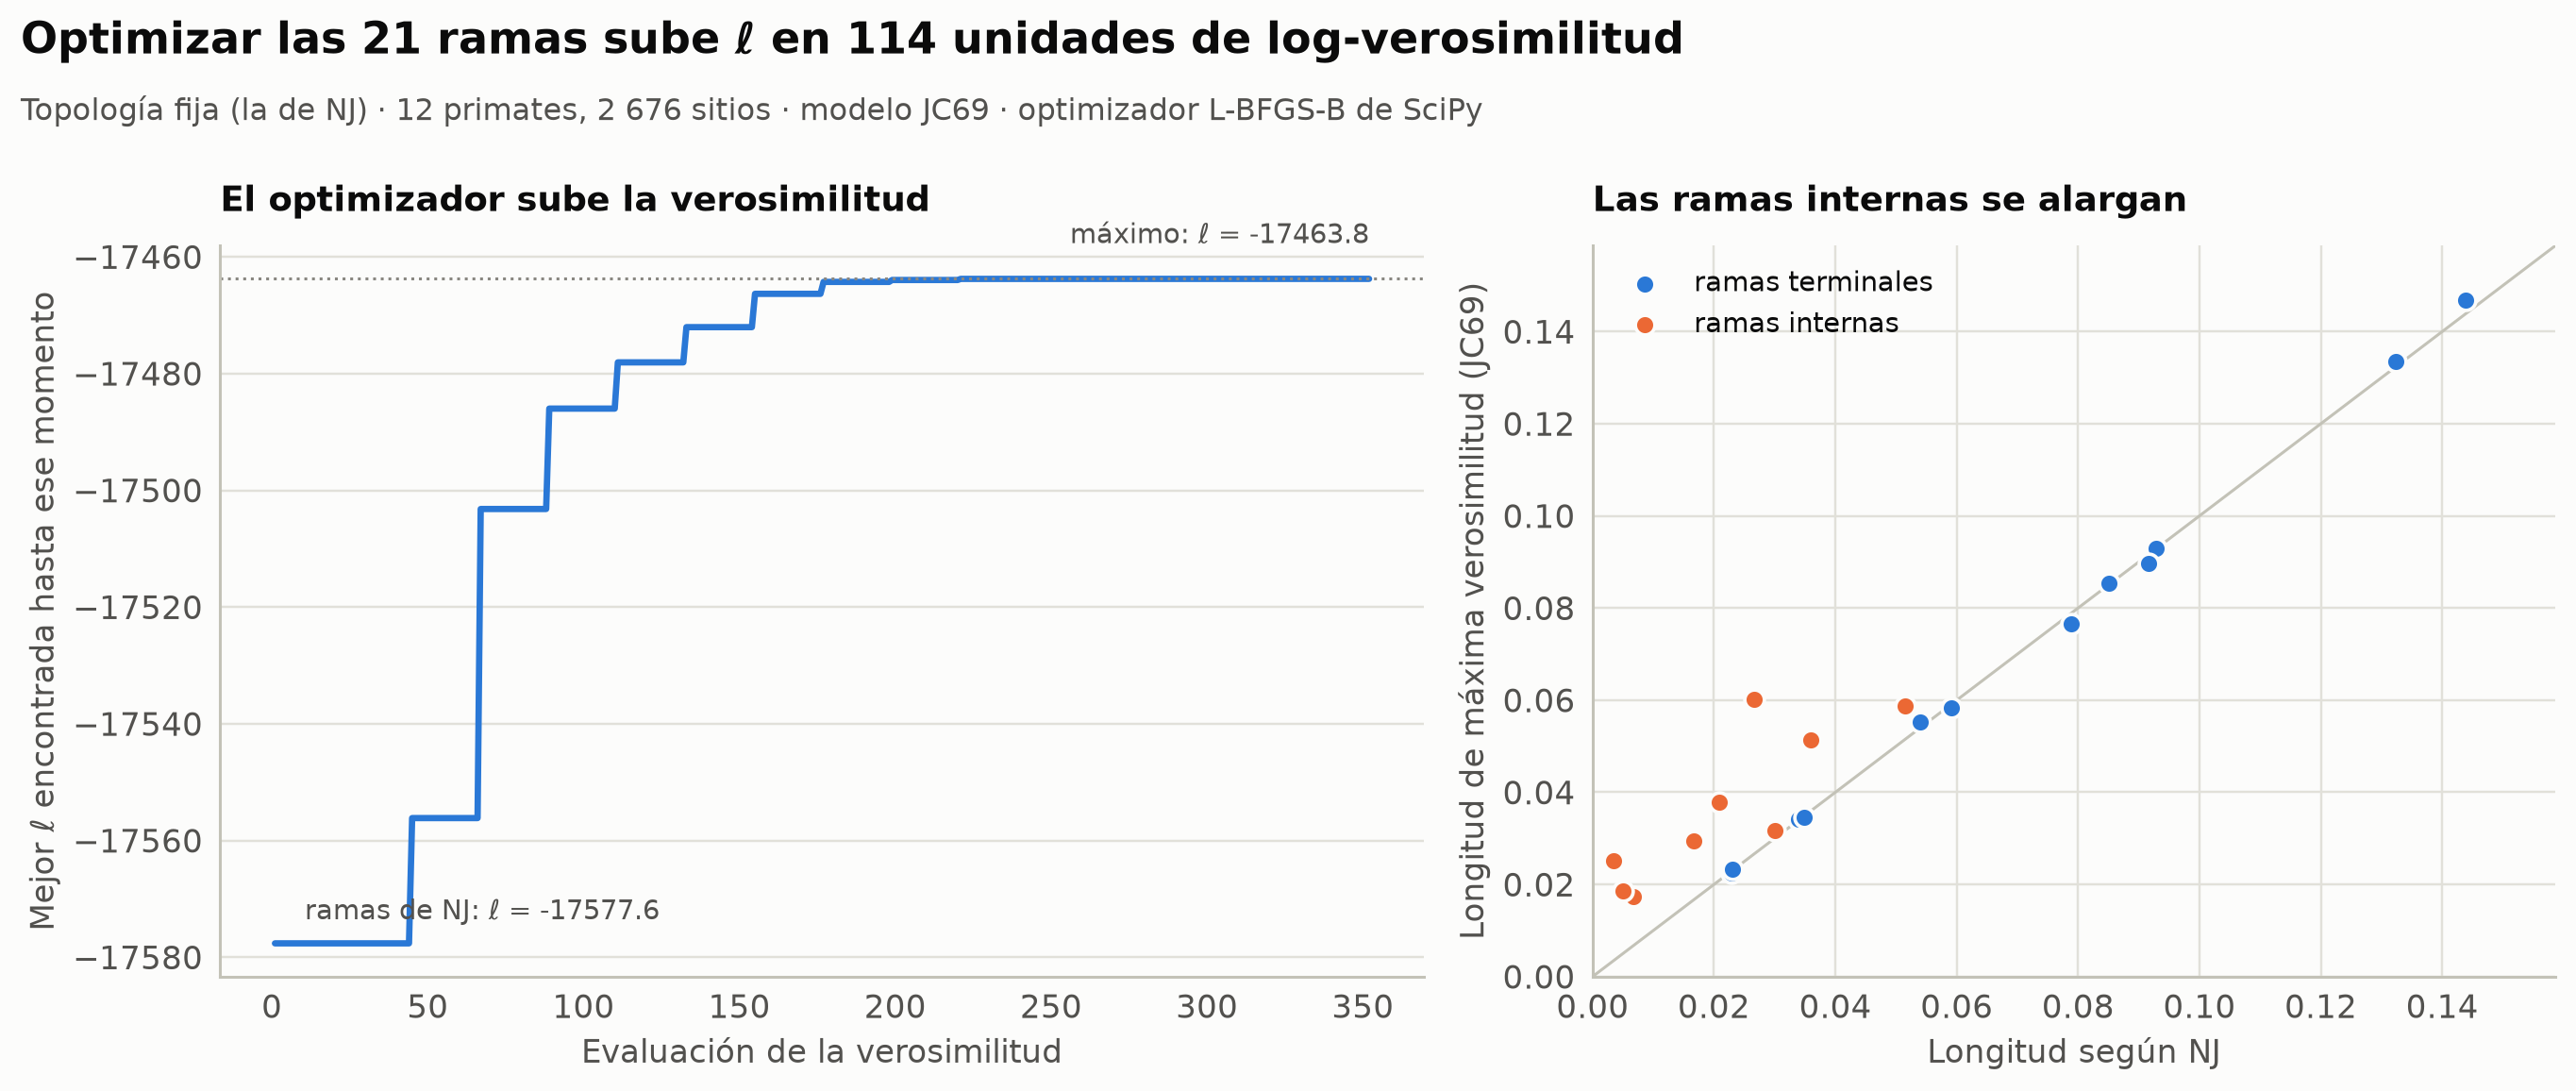

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6), gridspec_kw=dict(width_ratios=[1.25, 1]))
ax = axes[0]
best_so_far = np.maximum.accumulate(trace_jc)
ax.plot(np.arange(1, len(trace_jc) + 1), best_so_far, color=ec.BLUE, lw=2.2)
ax.axhline(ll_jc, color=ec.MUTED, ls=":", lw=1)
ax.text(len(trace_jc), ll_jc + 5, f"máximo: ℓ = {ll_jc:.1f}", ha="right", va="bottom", fontsize=9.5, color=ec.INK_2)
ax.text(len(trace_jc) * 0.03, best_so_far[0] + 3, f"ramas de NJ: ℓ = {best_so_far[0]:.1f}", va="bottom", fontsize=9.5, color=ec.INK_2)
ax.set_xlabel("Evaluación de la verosimilitud"); ax.set_ylabel("Mejor ℓ encontrada hasta ese momento")
ax.set_title("El optimizador sube la verosimilitud", loc="left", fontsize=12)

ax = axes[1]
nj_ref = newick_tree(nj_newick)
bl_nj = [c.branch_length for c in nj_ref.find_clades() if c is not nj_ref.root]
bl_ml = [c.branch_length for c in ml_tree_jc.find_clades() if c is not ml_tree_jc.root]
term = [c.is_terminal() for c in ml_tree_jc.find_clades() if c is not ml_tree_jc.root]
for flag, col, lbl in [(True, ec.BLUE, "ramas terminales"), (False, ec.ORANGE, "ramas internas")]:
    sel = np.array(term) == flag
    ax.scatter(np.array(bl_nj)[sel], np.array(bl_ml)[sel], s=46, color=col, edgecolor=ec.SURFACE, lw=1.2, label=lbl, zorder=3)
top = max(max(bl_nj), max(bl_ml)) * 1.08
ax.plot([0, top], [0, top], color=ec.BASELINE, lw=1)
ax.set_xlim(0, top); ax.set_ylim(0, top); ax.grid(True)
ax.set_xlabel("Longitud según NJ"); ax.set_ylabel("Longitud de máxima verosimilitud (JC69)")
ax.legend(loc="upper left", fontsize=9.5)
ax.set_title("Las ramas internas se alargan", loc="left", fontsize=12)
ec.fig_title(fig, f"Optimizar las 21 ramas sube ℓ en {ll_jc - best_so_far[0]:.0f} unidades de log-verosimilitud",
             "Topología fija (la de NJ) · 12 primates, 2 676 sitios · modelo JC69 · optimizador L-BFGS-B de SciPy")
plt.tight_layout(); plt.show()

> 🔎 **Qué observamos.** La mayor parte de la mejora ocurre en las primeras decenas de evaluaciones; después el
> optimizador sólo afina. Las ramas terminales de NJ ya eran buenas (puntos azules sobre la diagonal), pero la máxima
> verosimilitud **alarga las ramas internas** (puntos naranjas por encima): NJ las estima a partir de diferencias de
> distancias, que se "encogen" con la saturación, mientras que la verosimilitud usa la información de **todos** los
> sitios a la vez, patrón por patrón.
>
> Un aviso práctico: con cientos de especies, las verosimilitudes parciales se vuelven tan pequeñas que la computadora
> las redondea a 0. Los programas reales **reescalan** los vectores en cada nodo y suman los logaritmos de los factores
> de escala. Con 12 especies no hace falta.

## 6. Humano, chimpancé, gorila y orangután: las tres topologías

Con cuatro especies hay exactamente **tres árboles sin raíz** distintos. Si usamos al orangután como grupo externo
(el más alejado de los cuatro), cada árbol equivale a una respuesta distinta a la pregunta clásica *"¿quién es el
pariente más cercano del ser humano?"*:

| Topología | Newick sin raíz | Con el orangután como raíz, agrupa… |
|---|---|---|
| T1 | `(H, C, (G, O))` | humano + chimpancé |
| T2 | `(H, G, (C, O))` | humano + gorila |
| T3 | `(H, O, (C, G))` | chimpancé + gorila |

Para cada una optimizamos sus 5 longitudes de rama y comparamos las log-verosimilitudes máximas. Gana la topología con
mayor $\ell$. Este es, en miniatura, el **método de máxima verosimilitud** en filogenia: para cada árbol candidato, las
mejores ramas; entre los árboles, el que mejor explica los datos.

Haremos la comparación con tres modelos de sustitución: JC69, K80 (que distingue transiciones de transversiones) y
HKY+Γ (que además permite que cada sitio tenga su propia velocidad). Los describiremos con calma en la sección 7; por
ahora, basta saber que van de más simple a más realista.

> 🤔 **Antes de ejecutar, prediga:** ¿ganará siempre la misma topología, sea cual sea el modelo? ¿Y cree que las
> diferencias serán grandes (decenas de unidades de $\ell$) o pequeñas (1–2 unidades)?

In [16]:
H, Ch, G, O = four
TOPOLOGIES = {"T1: humano + chimpancé": f"({H}:0.05,{Ch}:0.05,({G}:0.05,{O}:0.05):0.02);",
              "T2: humano + gorila": f"({H}:0.05,{G}:0.05,({Ch}:0.05,{O}:0.05):0.02);",
              "T3: chimpancé + gorila": f"({H}:0.05,{O}:0.05,({Ch}:0.05,{G}:0.05):0.02);"}
DATA4 = compress(four)
print(f"4 especies: {len(DATA4['w'])} patrones distintos en {n_sites} columnas\n")

topo_fits = {}                                   # (modelo, topología) → (ℓ, árbol ajustado, modelo ajustado)
for model_name in ["JC69", "K80", "HKY+Γ"]:
    for name, nwk in TOPOLOGIES.items():
        tr = newick_tree(nwk)
        ll, mod, _ = fit_tree(tr, model_name, data=DATA4)
        topo_fits[model_name, name] = (ll, tr, mod)
    lls = {name: topo_fits[model_name, name][0] for name in TOPOLOGIES}
    best = max(lls, key=lls.get)
    print(f"{model_name}:")
    for name in TOPOLOGIES:
        tr = topo_fits[model_name, name][1]
        inner = [c for c in tr.get_nonterminals() if c is not tr.root][0]
        print(f"   {name:<24} ℓ = {lls[name]:9.2f}  (Δ = {lls[name] - lls[best]:6.2f})   rama interna = {inner.branch_length:.4f}"
              + ("   ← mejor" if name == best else ""))

4 especies: 80 patrones distintos en 2676 columnas

JC69:
   T1: humano + chimpancé   ℓ =  -7155.99  (Δ =  -8.64)   rama interna = 0.0176
   T2: humano + gorila      ℓ =  -7170.13  (Δ = -22.79)   rama interna = 0.0129
   T3: chimpancé + gorila   ℓ =  -7147.35  (Δ =   0.00)   rama interna = 0.0187   ← mejor
K80:
   T1: humano + chimpancé   ℓ =  -6724.61  (Δ =   0.00)   rama interna = 0.0181   ← mejor
   T2: humano + gorila      ℓ =  -6745.56  (Δ = -20.95)   rama interna = 0.0093
   T3: chimpancé + gorila   ℓ =  -6736.43  (Δ = -11.82)   rama interna = 0.0157


HKY+Γ:
   T1: humano + chimpancé   ℓ =  -6505.20  (Δ =   0.00)   rama interna = 0.0411   ← mejor
   T2: humano + gorila      ℓ =  -6511.29  (Δ =  -6.09)   rama interna = 0.0014
   T3: chimpancé + gorila   ℓ =  -6511.28  (Δ =  -6.08)   rama interna = 0.0000


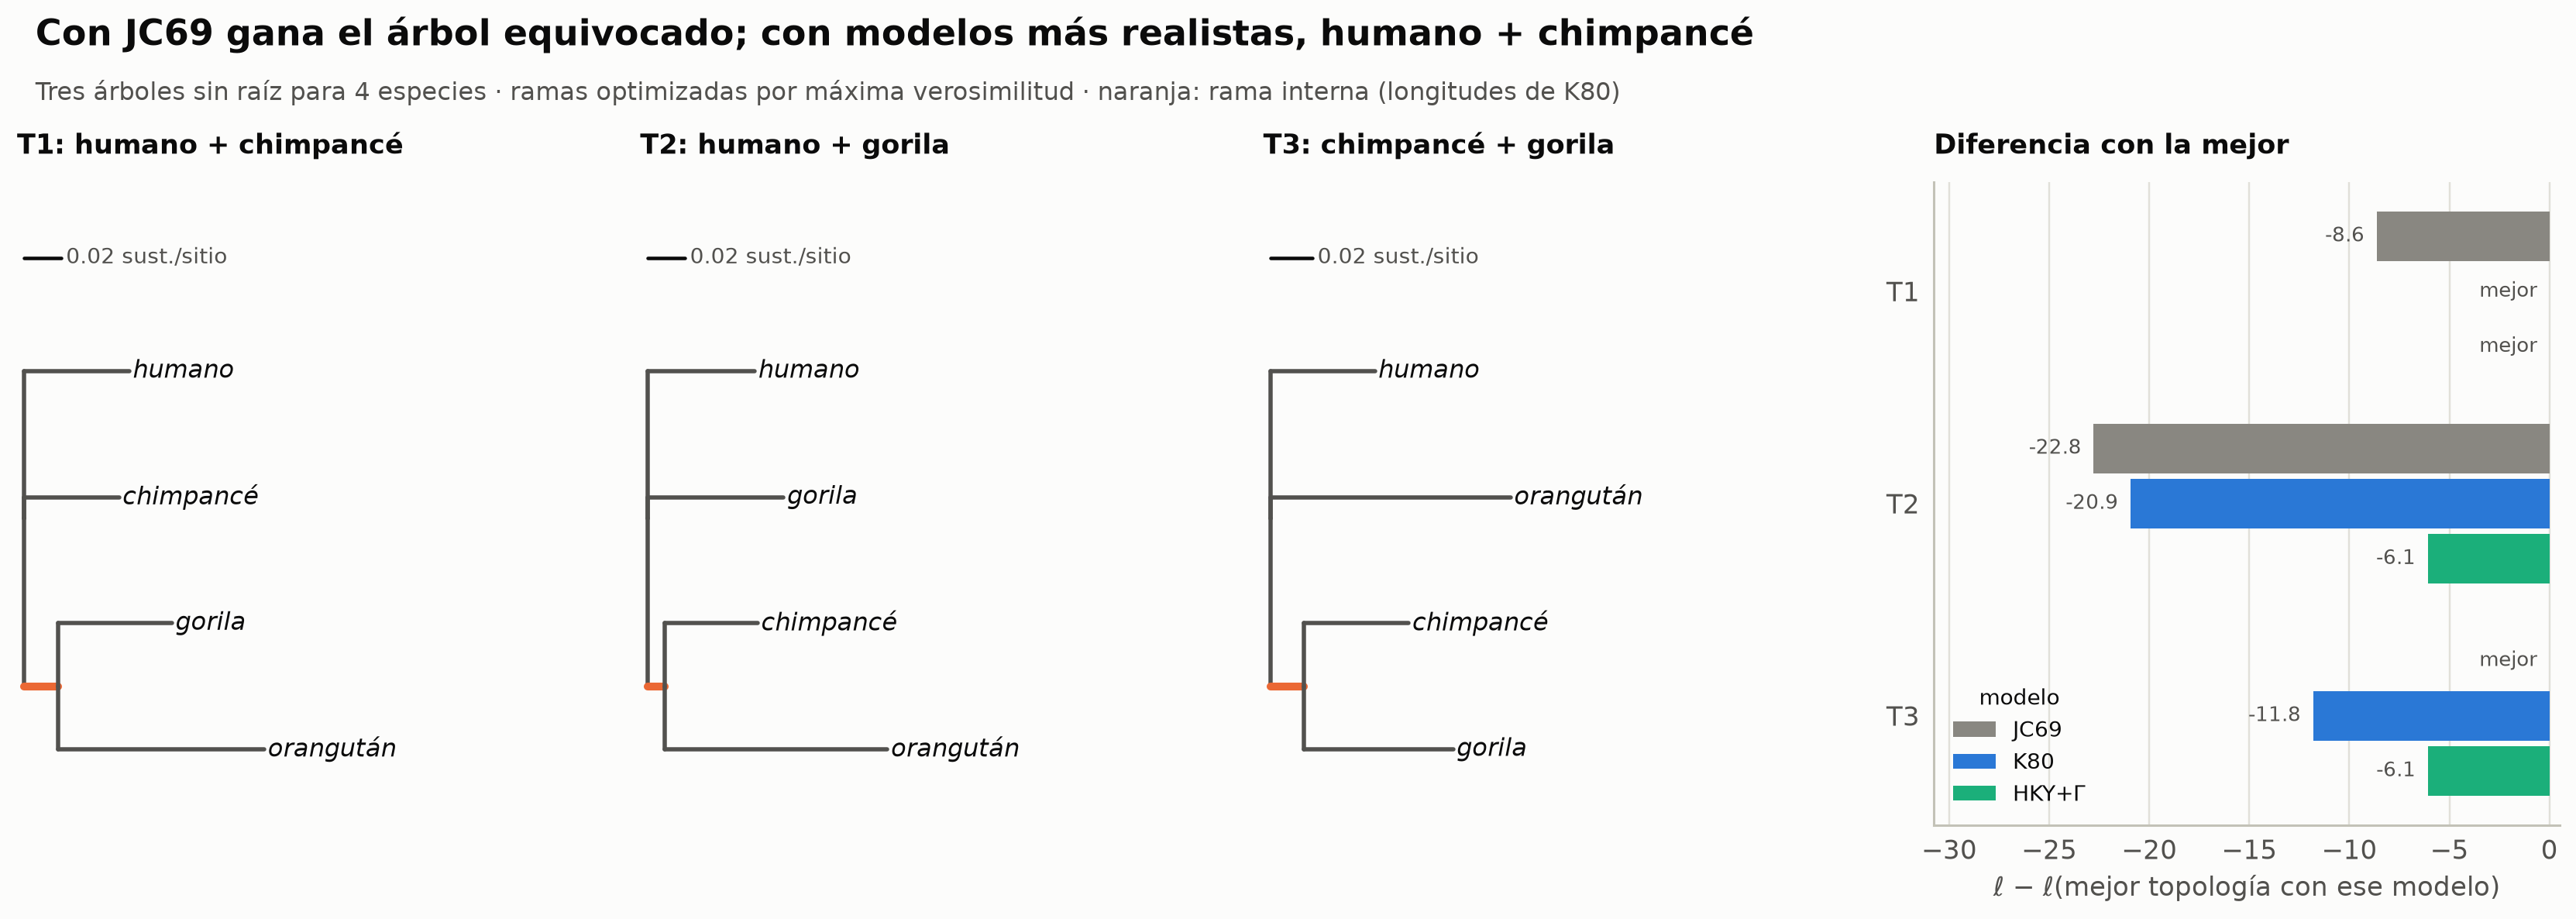

In [17]:
def tree_coords(tree):
    """Coordenadas para dibujar un árbol rectangular: x = distancia a la raíz, y = orden de las hojas."""
    xs, ys = {}, {}
    def walk(clade, x):
        xs[clade] = x
        for ch in clade.clades:
            walk(ch, x + (ch.branch_length or 0.0))
    walk(tree.root, 0.0)
    for i, leaf in enumerate(tree.get_terminals()):
        ys[leaf] = float(i)
    def set_y(clade):
        if clade not in ys:
            ys[clade] = np.mean([set_y(ch) for ch in clade.clades])
        return ys[clade]
    set_y(tree.root)
    return xs, ys

def draw_tree(ax, tree, supports=None, label=lambda n: n.replace("_", " "), highlight=None, lw=1.8, scale=None,
              support_color=None, fs=10):
    """Filograma rectangular profesional. supports: dict {frozenset(hojas del clado): valor}."""
    xs, ys = tree_coords(tree)
    highlight = highlight or {}
    for clade in tree.find_clades():
        for ch in clade.clades:
            col = highlight.get(ch, ec.INK_2)
            ax.plot([xs[clade], xs[clade]], [ys[clade], ys[ch]], color=ec.INK_2, lw=lw, solid_capstyle="round")
            ax.plot([xs[clade], xs[ch]], [ys[ch], ys[ch]], color=col, lw=lw + (1.5 if ch in highlight else 0),
                    solid_capstyle="round")
    xmax = max(xs.values())
    for leaf in tree.get_terminals():
        ax.text(xs[leaf] + xmax * 0.015, ys[leaf], label(leaf.name), va="center", fontsize=fs, style="italic", color=ec.INK)
    if supports:
        for clade in tree.get_nonterminals():
            key = frozenset(t.name for t in clade.get_terminals())
            if clade is tree.root or key not in supports or supports[key] is None:
                continue
            v = supports[key]
            col = support_color(v) if support_color else ec.INK_2
            ax.text(xs[clade] - xmax * 0.008, ys[clade] - 0.12, f"{v:.0f}", ha="right", va="bottom", fontsize=fs - 1.5,
                    color=col, fontweight="bold")
    if scale:
        y0 = -0.9
        ax.plot([0, scale], [y0, y0], color=ec.INK, lw=1.5)
        ax.text(scale + xmax * 0.02, y0, f"{scale} sust./sitio", ha="left", va="center", fontsize=fs - 1.5, color=ec.INK_2)
    ax.set_ylim(len(tree.get_terminals()) - 0.4, -1.5 if scale else -0.6)
    ax.set_xlim(-xmax * 0.03, xmax * 1.55)
    ax.axis("off")
    return xs, ys

MODELS3 = ["JC69", "K80", "HKY+Γ"]
fig = plt.figure(figsize=(15, 4.6))
gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 1.35], wspace=0.25)
best_jc = max(TOPOLOGIES, key=lambda n: topo_fits["JC69", n][0])
best_k80 = max(TOPOLOGIES, key=lambda n: topo_fits["K80", n][0])
for i, name in enumerate(TOPOLOGIES):
    ax = fig.add_subplot(gs[0, i])
    tr = topo_fits["K80", name][1]
    inner = [c for c in tr.get_nonterminals() if c is not tr.root][0]
    draw_tree(ax, tr, label=lambda n: COMMON[n].replace(" de Sumatra", ""), highlight={inner: ec.ORANGE}, scale=0.02, fs=10.5)
    ax.set_xlim(right=max(tree_coords(tr)[0].values()) * 1.9)
    ax.set_title(name, fontsize=11.5, loc="left", fontweight="bold")
ax = fig.add_subplot(gs[0, 3])
width = 0.26
for j, m in enumerate(MODELS3):
    lls = np.array([topo_fits[m, n][0] for n in TOPOLOGIES])
    d = lls - lls.max()
    ypos = np.arange(3) + (j - 1) * width
    ax.barh(ypos, d, height=width * 0.9, color=[ec.MUTED, ec.BLUE, ec.AQUA][j], label=m)
    for y, v in zip(ypos, d):
        ax.text(v - 0.6 if v < -0.05 else -0.6, y, f"{v:.1f}" if v < -0.05 else "mejor", va="center", ha="right",
                fontsize=8.5, color=ec.INK_2)
ax.set_yticks(range(3), [n.split(":")[0] for n in TOPOLOGIES]); ax.invert_yaxis()
lo = min(topo_fits[m, n][0] - max(topo_fits[m, k][0] for k in TOPOLOGIES) for m in MODELS3 for n in TOPOLOGIES)
ax.set_xlim(lo * 1.35, 0.5)
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
ax.set_xlabel("ℓ − ℓ(mejor topología con ese modelo)")
ax.legend(loc="lower left", fontsize=9, title="modelo", title_fontsize=9)
ax.set_title("Diferencia con la mejor", fontsize=11.5, loc="left")
ec.fig_title(fig, "Con JC69 gana el árbol equivocado; con modelos más realistas, humano + chimpancé",
             "Tres árboles sin raíz para 4 especies · ramas optimizadas por máxima verosimilitud · naranja: rama interna (longitudes de K80)")
plt.show()

> 🔎 **Qué observamos.** ¡Sorpresa! Con **JC69**, la máxima verosimilitud prefiere **T3** (chimpancé + gorila) por
> unas 9 unidades de $\ell$. Con **K80** y con **HKY+Γ**, en cambio, gana con claridad **T1** (humano + chimpancé), que
> es lo que muestran los genomas completos. Los datos son los mismos; lo que cambió fue el **modelo**. Fíjese además
> en las ramas internas impresas arriba: con HKY+Γ, T2 y T3 reducen su rama interna prácticamente a **cero**, es decir,
> se convierten en un árbol en estrella que no afirma nada. Cuando una agrupación no tiene apoyo real, la máxima
> verosimilitud tiende a colapsar su rama.
>
> ¿Por qué se equivoca JC69? En el ADN mitocondrial las transiciones (A↔G, C↔T) son muchísimo más frecuentes que las
> transversiones, y se acumulan una y otra vez en los sitios rápidos (terceras posiciones de los codones). Muchas de las
> coincidencias entre dos especies en esos sitios son **convergencias**: la misma transición ocurrida dos veces por
> separado. JC69 no sabe que las transiciones son "baratas" y lee esas coincidencias como si fueran herencia común.
> K80 sí lo sabe y les da menos peso. Es una lección central de la filogenética: **un modelo demasiado simple puede
> apoyar con fuerza un árbol falso**. Por eso elegir el modelo (sección 7) no es un trámite.
>
> Un matiz biológico: el ADN mitocondrial es **un solo locus** heredado por vía materna. En el genoma nuclear, en cerca
> de un 30 % del genoma se observa otra historia (humano + gorila o chimpancé + gorila) por *separación incompleta de
> linajes*: los ancestros de los tres linajes eran poblaciones polimórficas que se separaron en un intervalo corto.
> El árbol de un gen no siempre es el árbol de las especies.

### Superficie de log-verosimilitud interactiva

Fijemos la topología ganadora con K80 y todas sus ramas en el óptimo, salvo dos: la **rama interna** y la **rama del
humano**. El mapa muestra $\ell$ para cada combinación. Pase el cursor para ver los valores; la estrella marca el máximo.

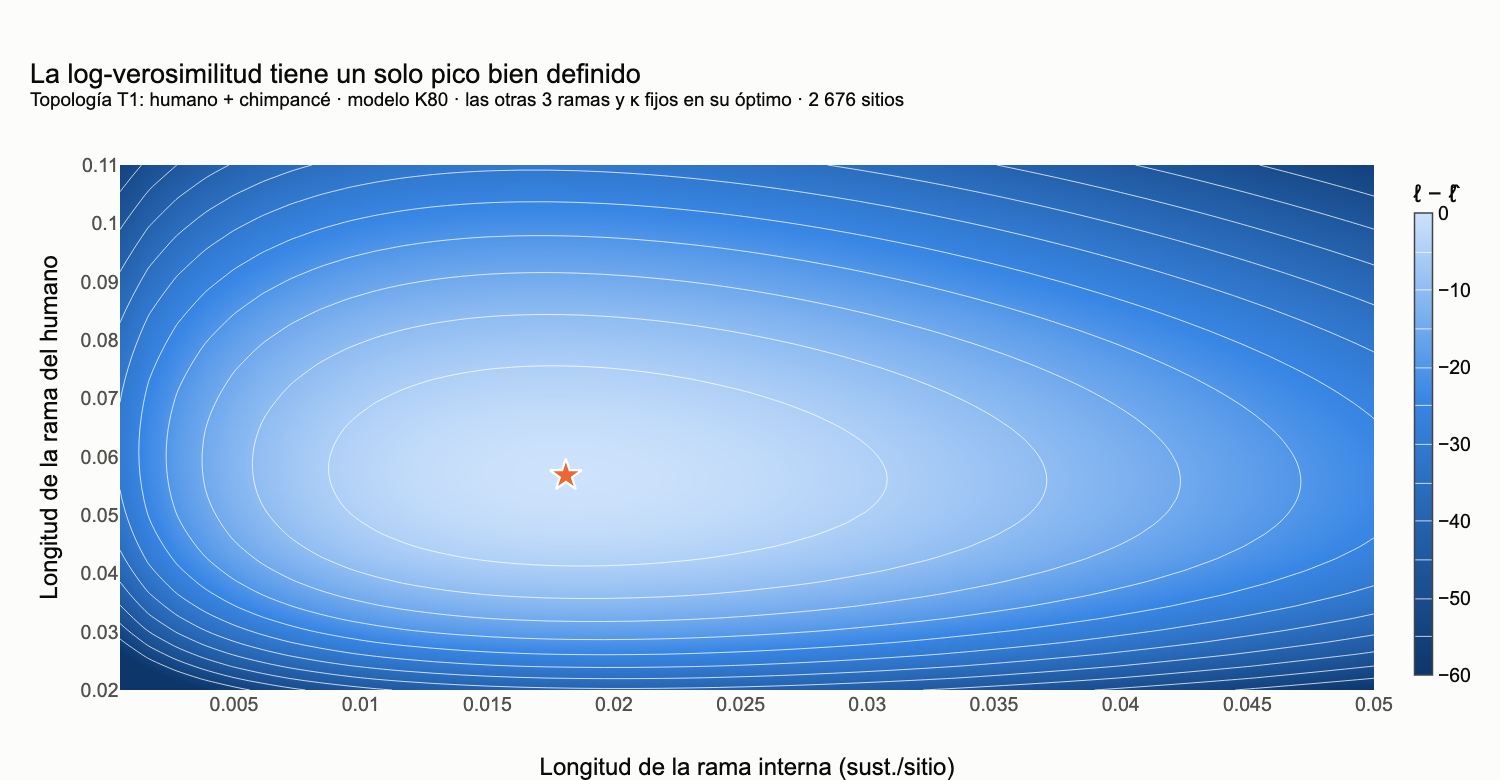

In [18]:
ll_best, t1, model_k80 = topo_fits["K80", best_k80]
inner = [c for c in t1.get_nonterminals() if c is not t1.root][0]
leaf_h = next(t1.find_clades(H))
opt_inner, opt_h = inner.branch_length, leaf_h.branch_length
g_inner = np.linspace(0.0005, 0.05, 45)
g_h = np.linspace(0.02, 0.11, 45)
surface = np.empty((len(g_h), len(g_inner)))
for i, bh in enumerate(g_h):
    for j, bi in enumerate(g_inner):
        leaf_h.branch_length, inner.branch_length = bh, bi
        surface[i, j] = tree_loglik(t1, model_k80, DATA4)
leaf_h.branch_length, inner.branch_length = opt_h, opt_inner      # restaurar el óptimo

fig = go.Figure(go.Contour(
    x=g_inner, y=g_h, z=surface - ll_best, zmin=-60, zmax=0, ncontours=25,
    colorscale=[[0, ec.SEQ_BLUE[12]], [0.6, ec.SEQ_BLUE[6]], [1, ec.SEQ_BLUE[0]]],
    contours=dict(coloring="heatmap", showlines=True), line=dict(width=0.5, color="white"),
    colorbar=dict(title="ℓ − ℓ̂", thickness=12),
    customdata=surface,
    hovertemplate=("rama interna = %{x:.4f}<br>rama del humano = %{y:.4f}"
                   "<br>ℓ = %{customdata:.2f}<br>ℓ − ℓ̂ = %{z:.2f}<extra></extra>")))
fig.add_scatter(x=[opt_inner], y=[opt_h], mode="markers", marker=dict(symbol="star", size=16, color=ec.ORANGE,
                line=dict(color="white", width=1.5)), name="máximo de verosimilitud",
                hovertemplate=f"Máximo<br>rama interna = {opt_inner:.4f}<br>rama del humano = {opt_h:.4f}"
                              f"<br>ℓ = {ll_best:.2f}<extra></extra>")
fig.update_layout(
    title=dict(text="La log-verosimilitud tiene un solo pico bien definido<br>"
                    f"<sup>Topología {best_k80} · modelo K80 · las otras 3 ramas y κ fijos en su óptimo · 2 676 sitios</sup>"),
    xaxis=dict(title="Longitud de la rama interna (sust./sitio)"), yaxis=dict(title="Longitud de la rama del humano"),
    height=520, margin=dict(t=110, l=80, r=40, b=60),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, x=1, xanchor="right"))
fig.show()

> 🔎 **Qué observamos.** Las curvas de nivel rodean un único máximo: cerca del óptimo, la log-verosimilitud se parece a
> un paraboloide. Si la rama interna se acerca a cero, $\ell$ cae con rapidez: los datos **exigen** una rama que agrupe
> a humano y chimpancé. La inclinación de las elipses indica que las dos ramas están algo **correlacionadas**; por eso
> los programas optimizan las ramas una a una, repetidamente, hasta que ninguna mejora.

### ¿Y con 12 especies?

Con 4 especies probamos las 3 topologías. Pero el número de árboles sin raíz con $n$ hojas es
$(2n-5)!! = 3 \times 5 \times 7 \times \dots \times (2n-5)$:

| $n$ | 4 | 5 | 6 | 8 | 10 | 12 | 20 | 50 |
|---|---|---|---|---|---|---|---|---|
| árboles | 3 | 15 | 105 | 10 395 | 2 027 025 | 654 729 075 | $2.2 \times 10^{20}$ | $2.8 \times 10^{74}$ |

Probarlos todos es imposible. Los programas reales parten de un árbol rápido (NJ o parsimonia) y lo mejoran con
**búsquedas heurísticas**: intercambian vecinos alrededor de una rama (NNI) o podan y reinsertan subárboles (SPR),
y aceptan cada cambio que sube $\ell$. IQ-TREE combina estas búsquedas con perturbaciones aleatorias para no quedarse
atascado en un máximo local.

✅ **Compruebe su comprensión.** Si un revisor le dice "su árbol tiene la máxima verosimilitud, así que es correcto",
¿qué le respondería? (Respuesta: que es el árbol que mejor explica los datos **bajo ese modelo**. Con JC69, el árbol
de máxima verosimilitud de estos cuatro simios es incorrecto. Hay que comprobar que el modelo sea adecuado y medir la
confianza en cada rama, que es lo que haremos en las secciones 7 y 8.)

## 7. ¿Qué modelo? AIC y BIC

Un modelo con más parámetros **siempre** alcanza una verosimilitud mayor o igual (JC69 es un caso particular de K80 con
$\kappa = 1$: K80 puede, como mínimo, igualarlo). Si eligiéramos por $\ell$ a secas, ganaría siempre el modelo más
complicado, aunque sus parámetros extra sólo "memoricen" el ruido de los datos. Hace falta **cobrar** por cada
parámetro.

$$
\mathrm{AIC} = 2k - 2\ell
\qquad\qquad
\mathrm{BIC} = k\,\ln n - 2\ell
$$

| Símbolo | Significado |
|---|---|
| $\ell$ | log-verosimilitud **máxima** del modelo |
| $k$ | número de parámetros libres (ramas + parámetros del modelo) |
| $n$ | número de sitios del alineamiento (2 676) |
| AIC | criterio de información de Akaike (1974): cada parámetro cuesta 2 unidades |
| BIC | criterio bayesiano de Schwarz (1978): cada parámetro cuesta $\ln n \approx 7.9$ unidades, más exigente |

Gana el modelo con **menor** AIC o BIC. Una diferencia de más de 10 unidades se considera decisiva.

### Ejemplo a mano: JC69 contra K80

En el árbol NJ de 12 especies (21 ramas), JC69 alcanza $\ell = -17\,463.78$ y K80 (una rama más: $\kappa$)
$\ell = -16\,345.02$:

| | $k$ | $-2\ell$ | AIC $= 2k - 2\ell$ | BIC $= k \ln 2676 - 2\ell$ |
|---|---|---|---|---|
| JC69 | 21 | 34 927.55 | 34 969.55 | $165.73 + 34\,927.55 = 35\,093.28$ |
| K80 | 22 | 32 690.05 | **32 734.05** | $173.63 + 32\,690.05 = \mathbf{32\,863.68}$ |

Un solo parámetro extra ($\kappa$) mejora $\ell$ en más de 1 100 unidades: pagarlo cuesta 2 (AIC) o 7.9 (BIC). K80 gana
por goleada. En el ADN mitocondrial las **transiciones** son muchísimo más frecuentes que las transversiones.

In [19]:
model_rows, fitted = [], {}
for name in MODEL_SPECS:
    tr = newick_tree(nj_newick)                      # misma topología (NJ) para todos los modelos
    t0 = time.time()
    ll, model, k = fit_tree(tr, name)
    fitted[name] = (tr, model)
    model_rows.append(dict(modelo=name, k=k, logL=ll, AIC=2 * k - 2 * ll, BIC=k * np.log(n_sites) - 2 * ll,
                           kappa=model["kappa"], alpha=model["alpha"], segundos=time.time() - t0))
models_df = pd.DataFrame(model_rows)
models_df["ΔAIC"] = models_df.AIC - models_df.AIC.min()
models_df["ΔBIC"] = models_df.BIC - models_df.BIC.min()
models_df.round(2)

,modelo,k,logL,AIC,BIC,kappa,alpha,segundos,ΔAIC,ΔBIC
0,JC69,21,-17463.78,34969.55,35093.29,1.00,NaN,0.11,4813.82,4784.36
1,K80,22,-16345.02,32734.05,32863.67,6.90,NaN,0.16,2578.32,2554.75
2,HKY,25,-16164.83,32379.65,32526.95,6.93,NaN,0.19,2223.92,2218.03
3,HKY+Γ,26,-15051.87,30155.73,30308.93,13.04,0.25,1.08,0.00,0.00


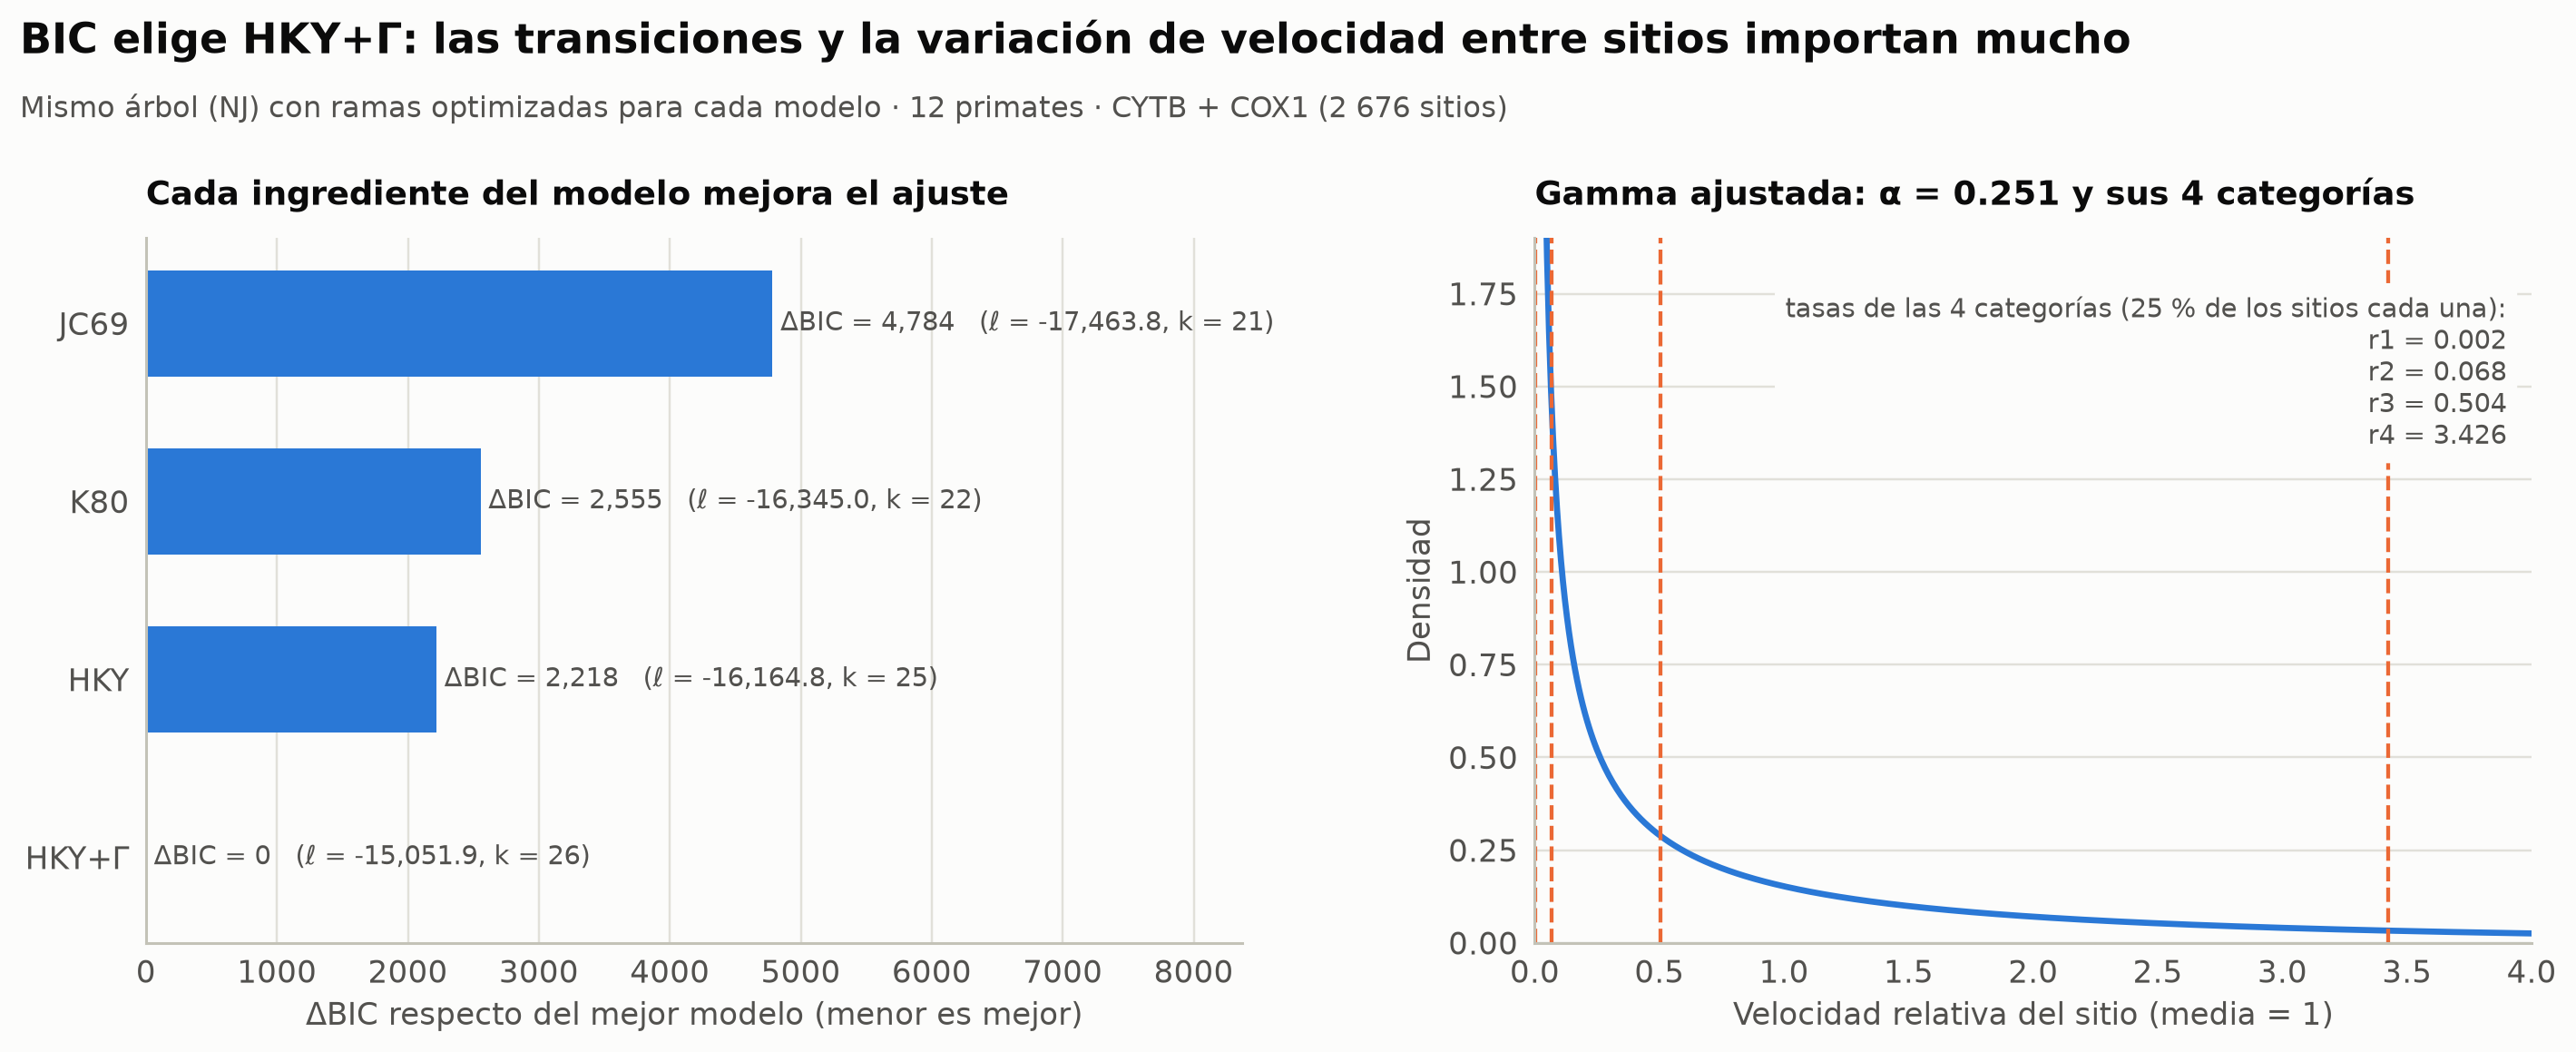

In [20]:
alpha_hat = fitted["HKY+Γ"][1]["alpha"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw=dict(width_ratios=[1.1, 1]))
ax = axes[0]
yy = np.arange(len(models_df))
best_model = models_df.loc[models_df.BIC.idxmin(), "modelo"]
ax.barh(yy, models_df["ΔBIC"], color=[ec.ORANGE if m == best_model else ec.BLUE for m in models_df.modelo], height=0.6)
for y, (d, ll, k) in enumerate(zip(models_df["ΔBIC"], models_df.logL, models_df.k)):
    ax.text(d + 60, y, f"ΔBIC = {d:,.0f}   (ℓ = {ll:,.1f}, k = {k})", va="center", fontsize=9.5, color=ec.INK_2)
ax.set_yticks(yy, models_df.modelo); ax.invert_yaxis()
ax.set_xlim(0, models_df["ΔBIC"].max() * 1.75)
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
ax.set_xlabel("ΔBIC respecto del mejor modelo (menor es mejor)")
ax.set_title("Cada ingrediente del modelo mejora el ajuste", loc="left", fontsize=12)

ax = axes[1]
xg = np.linspace(0.001, 4, 500)
ax.plot(xg, gamma_dist.pdf(xg, alpha_hat, scale=1 / alpha_hat), color=ec.BLUE, lw=2.2)
rates = gamma_rates(alpha_hat)
for i, r in enumerate(rates):
    ax.axvline(r, color=ec.ORANGE, lw=1.4, ls="--")
ax.text(3.9, 1.75, "tasas de las 4 categorías (25 % de los sitios cada una):\n" +
        "\n".join(f"r{i + 1} = {r:.3f}" for i, r in enumerate(rates)), ha="right", va="top", fontsize=9.5,
        color=ec.INK_2, bbox=dict(boxstyle="round,pad=0.4", fc=ec.SURFACE, ec=ec.BASELINE))
ax.set_ylim(0, 1.9); ax.set_xlim(0, 4)
ax.set_xlabel("Velocidad relativa del sitio (media = 1)"); ax.set_ylabel("Densidad")
ax.set_title(f"Gamma ajustada: α = {alpha_hat:.3f} y sus 4 categorías", loc="left", fontsize=12)
ec.fig_title(fig, f"BIC elige {best_model}: las transiciones y la variación de velocidad entre sitios importan mucho",
             "Mismo árbol (NJ) con ramas optimizadas para cada modelo · 12 primates · CYTB + COX1 (2 676 sitios)")
plt.tight_layout(); plt.show()

> 🔎 **Qué observamos.** Los tres "ingredientes" pagan su precio con creces: $\kappa$ (transiciones más frecuentes),
> las frecuencias desiguales (el ADN mitocondrial de primates es pobre en G, apenas ~15 %) y, sobre todo, la **gamma**.
> Con $\alpha \approx 0.25$ la distribución tiene forma de L: la mayoría de los sitios casi no cambia (las categorías
> lentas tienen tasas cercanas a 0) y unos pocos cambian a más del doble o triple de la velocidad media. ¿Qué sitios
> son esos? En genes que codifican proteínas, la respuesta está en el **código genético**.

               logL_medio  frac_variable
gen  posicion                           
COX1 1             -3.507          0.227
     2             -2.345          0.074
     3            -10.169          0.932
CYTB 1             -5.073          0.408
     2             -3.327          0.211
     3             -9.624          0.913


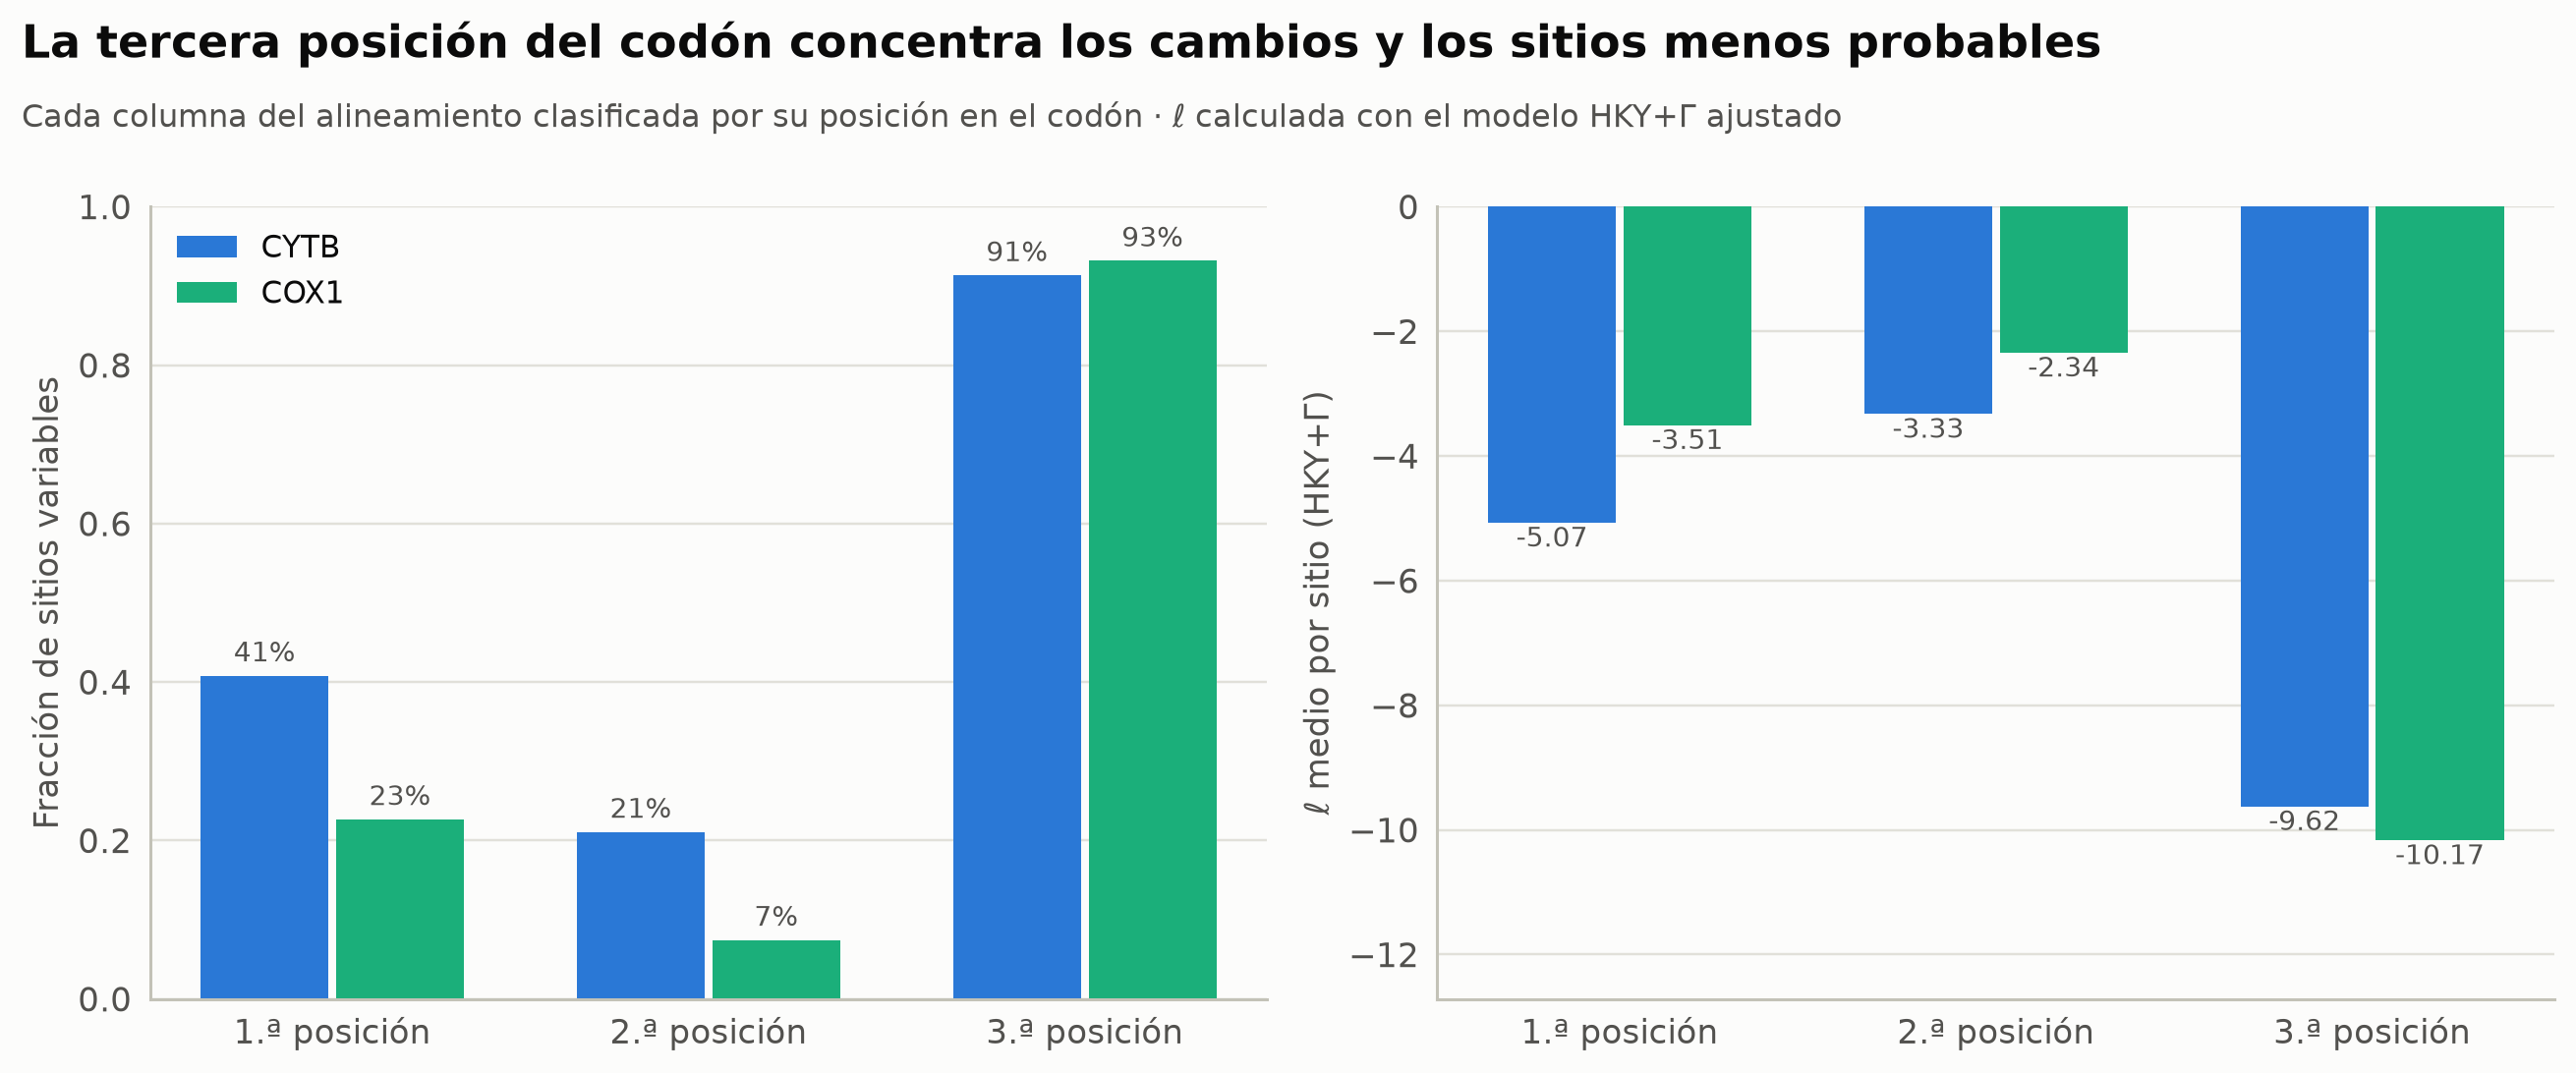

In [21]:
tr_g, model_g = fitted["HKY+Γ"]
per_col = site_logliks(tr_g, model_g)[DATA["inverse"]]            # ℓ de cada columna del alineamiento
gene = np.where(np.arange(n_sites) < 1140, "CYTB", "COX1")
codon_pos = np.where(gene == "CYTB", np.arange(n_sites) % 3, (np.arange(n_sites) - 1140) % 3) + 1
variable = ~const
summary = (pd.DataFrame(dict(gen=gene, posicion=codon_pos, logL=per_col, variable=variable))
             .groupby(["gen", "posicion"]).agg(logL_medio=("logL", "mean"), frac_variable=("variable", "mean")))
print(summary.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
for ax, col, lab, fmt in [(axes[0], "frac_variable", "Fracción de sitios variables", "{:.0%}"),
                          (axes[1], "logL_medio", "ℓ medio por sitio (HKY+Γ)", "{:.2f}")]:
    for g_i, (g, colr) in enumerate([("CYTB", ec.BLUE), ("COX1", ec.AQUA)]):
        vals = summary.loc[g][col].values
        xpos = np.arange(3) + (g_i - 0.5) * 0.36
        ax.bar(xpos, vals, width=0.34, color=colr, label=g)
        for x_, v in zip(xpos, vals):
            ax.text(x_, v + (0.01 if col == "frac_variable" else -0.05), fmt.format(v), ha="center",
                    va="bottom" if col == "frac_variable" else "top", fontsize=9, color=ec.INK_2)
    ax.set_xticks(range(3), ["1.ª posición", "2.ª posición", "3.ª posición"])
    ax.set_ylabel(lab); ax.grid(axis="x", visible=False)
axes[0].set_ylim(0, 1); axes[0].legend(loc="upper left")
axes[1].set_ylim(min(summary.logL_medio) * 1.25, 0)
ec.fig_title(fig, "La tercera posición del codón concentra los cambios y los sitios menos probables",
             "Cada columna del alineamiento clasificada por su posición en el codón · ℓ calculada con el modelo HKY+Γ ajustado")
plt.tight_layout(); plt.show()

> 🔎 **Qué observamos.** Casi todas las terceras posiciones varían entre estos primates, porque la mayoría de los cambios
> en ellas son **sinónimos** (no cambian el aminoácido) y la selección no los elimina. Las segundas posiciones apenas
> varían. Esa enorme heterogeneidad es la que captura la gamma, y la razón por la que en la práctica casi siempre se
> usa **+Γ** (o sus variantes: +I para una fracción de sitios invariables, +R para tasas libres). También es la
> justificación de los **modelos particionados**, que asignan un modelo distinto a cada posición del codón.

✅ **Compruebe su comprensión.** Si agregamos un parámetro que mejora $\ell$ en 3 unidades, ¿lo aceptaría AIC? ¿Y BIC con
$n = 2676$? (Respuesta: AIC sí, porque $2 \times 3 = 6 > 2$; BIC no, porque $6 < \ln 2676 \approx 7.9$. BIC es más
conservador y prefiere modelos más sencillos, por eso IQ-TREE lo usa por defecto.)

## 8. Bootstrap: ¿cuánto confiamos en cada rama?

Ya tenemos un árbol. Pero, ¿qué ramas son sólidas y cuáles dependen de unas pocas columnas? Lo ideal sería repetir la
evolución de los primates 1 000 veces y ver cuántas veces sale cada clado. Como eso no se puede, Felsenstein (1985)
propuso aplicar el **bootstrap** de Efron: tratar las columnas del alineamiento como una muestra de todas las columnas
posibles, y **remuestrearlas con reemplazo** para fabricar alineamientos "hermanos" del mismo tamaño.

1. Sortear $n$ columnas **con reemplazo** (unas saldrán repetidas, otras nunca).
2. Reconstruir el árbol con ese alineamiento réplica (con el mismo método).
3. Repetir $B$ veces (100–1 000) y contar en qué **porcentaje** de las réplicas aparece cada clado del árbol original.

### Ejemplo a mano: una réplica de 8 columnas

| columna | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 |
|---|---|---|---|---|---|---|---|---|
| humano | A | C | G | T | A | C | C | T |
| chimpancé | A | C | G | T | G | C | C | T |
| gorila | A | T | G | C | G | C | T | T |
| orangután | G | T | A | C | G | T | T | C |

Sorteamos 8 números entre 1 y 8, con reemplazo: **2, 7, 7, 4, 1, 8, 2, 5**. La réplica es:

| columna de la réplica | 2 | 7 | 7 | 4 | 1 | 8 | 2 | 5 |
|---|---|---|---|---|---|---|---|---|
| humano | C | C | C | T | A | T | C | A |
| chimpancé | C | C | C | T | A | T | C | G |
| gorila | T | T | T | C | A | T | T | G |
| orangután | T | T | T | C | G | C | T | G |

Las columnas 2 y 7 (que agrupan humano con chimpancé) salieron **dos veces**; la 3 y la 6 **ninguna**. En promedio, una
réplica contiene sólo $1 - (1 - 1/n)^n \approx 1 - 1/e \approx 63\,\%$ de las columnas distintas. Si un clado está
apoyado por muchas columnas repartidas por todo el alineamiento, sobrevive a casi cualquier sorteo; si depende de dos o
tres columnas, desaparece a menudo.

Como ya comprimimos las columnas en patrones, una réplica es simplemente un nuevo vector de **conteos por patrón**:
`np.bincount` de los patrones de las columnas sorteadas. Usaremos NJ sobre distancias JC69 (rápido); la versión con
máxima verosimilitud es igual, sólo que más lenta.

In [22]:
REF = "Lemur_catta"                          # grupo externo: define la raíz para dibujar
ALL = frozenset(names)

def split_key(taxa):
    """Una rama de un árbol sin raíz separa las hojas en dos grupos. La representamos por el lado SIN el lémur."""
    s = frozenset(taxa)
    return ALL - s if REF in s else s

def tree_splits(tree):
    """Biparticiones no triviales de un árbol (2 ≤ tamaño ≤ n−2), con su valor de apoyo si lo tiene."""
    out = {}
    for cl in tree.get_nonterminals():
        tips = [t.name for t in cl.get_terminals()]
        if 2 <= len(tips) <= n_taxa - 2:
            out[split_key(tips)] = cl.confidence
    return out

def bootstrap_nj(B, columns=None, seed=53):
    """Bootstrap no paramétrico con NJ + distancias JC69. Devuelve la lista de árboles Newick de las réplicas."""
    columns = np.arange(n_sites) if columns is None else np.asarray(columns)
    r = np.random.default_rng(seed)
    reps = []
    for b in range(B):
        sample = r.choice(columns, size=len(columns), replace=True)       # columnas sorteadas con reemplazo
        w = np.bincount(DATA["inverse"][sample], minlength=len(DATA["w"])).astype(float)
        reps.append(neighbor_joining(jc_distance_matrix(w), names))
    return reps

def support_from(reps, reference_splits):
    counts = Counter(s for nwk in reps for s in tree_splits(newick_tree(nwk)))
    return {s: 100 * counts[s] / len(reps) for s in reference_splits}, counts

t0 = time.time()
B = 500
boot_reps = bootstrap_nj(B)
nj_splits = tree_splits(nj_tree)
nj_support, split_counts = support_from(boot_reps, nj_splits)
print(f"{B} réplicas bootstrap en {time.time() - t0:.1f} s")

GROUP_NAMES = {
    frozenset({"Pan_troglodytes", "Pan_paniscus"}): "chimpancé + bonobo",
    frozenset({"Homo_sapiens", "Pan_troglodytes", "Pan_paniscus"}): "humano + Pan",
    frozenset({"Homo_sapiens", "Pan_troglodytes", "Pan_paniscus", "Gorilla_gorilla"}): "Homininae (+ gorila)",
    frozenset({"Pongo_abelii", "Pongo_pygmaeus"}): "orangutanes",
    frozenset({"Macaca_mulatta", "Papio_hamadryas"}): "macaco + babuino",
    frozenset({"Macaca_mulatta", "Chlorocebus_sabaeus"}): "macaco + mono verde",
    frozenset({"Papio_hamadryas", "Chlorocebus_sabaeus"}): "babuino + mono verde",
    frozenset({"Macaca_mulatta", "Papio_hamadryas", "Chlorocebus_sabaeus"}): "Cercopitécidos",
}
APES = {"Homo_sapiens", "Pan_troglodytes", "Pan_paniscus", "Gorilla_gorilla", "Pongo_abelii", "Pongo_pygmaeus"}
GROUP_NAMES[frozenset(APES)] = "Hominidae (grandes simios)"
GROUP_NAMES[frozenset(APES | {"Hylobates_lar"})] = "Hominoidea (simios)"
GROUP_NAMES[ALL - {"Callithrix_jacchus", "Lemur_catta"}] = "Catarrinos (monos del Viejo Mundo y simios)"

def split_name(s):
    return GROUP_NAMES.get(s, " + ".join(COMMON[t] for t in sorted(s))[:40])

boot_table = pd.DataFrame([(split_name(s), len(s), v) for s, v in nj_support.items()],
                          columns=["clado del árbol NJ", "especies", "bootstrap %"]).sort_values("bootstrap %")
boot_table

500 réplicas bootstrap en 0.2 s


,clado del árbol NJ,especies,bootstrap %
7,macaco + mono verde,2,57.0
2,humano + Pan,3,81.4
4,Hominidae (grandes simios),6,84.6
0,orangutanes,2,100.0
1,Homininae (+ gorila),4,100.0
3,chimpancé + bonobo,2,100.0
5,Hominoidea (simios),7,100.0
6,Cercopitécidos,3,100.0
8,Catarrinos (monos del Viejo Mundo y simios),10,100.0


## 🎬 Animación: las réplicas bootstrap una a una

A la izquierda, el árbol NJ de cada réplica (enraizado con el lémur); en naranja, las ramas que **no** están en el
árbol original. A la derecha, el porcentaje acumulado de réplicas que contienen cada clado del árbol original. Al final
se muestran los valores con las 500 réplicas.

![Réplicas bootstrap: cada remuestreo de columnas produce un árbol NJ; casi todos los clados aparecen siempre, pero macaco + mono verde va y viene](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-05-filogenetica/5.3_bootstrap_replicas.gif)

*Réplicas bootstrap: cada remuestreo de columnas produce un árbol NJ; casi todos los clados aparecen siempre, pero macaco + mono verde va y viene*

In [23]:
def rooted(nwk_or_tree):
    tr = newick_tree(nwk_or_tree) if isinstance(nwk_or_tree, str) else nwk_or_tree
    tr.root_with_outgroup(REF)
    kids = tr.root.clades                       # raíz a la mitad del camino entre el lémur y el resto
    if len(kids) == 2:
        half = sum(k.branch_length or 0.0 for k in kids) / 2
        for k in kids:
            k.branch_length = half
    tr.ladderize(reverse=True)
    return tr

order_splits = sorted(nj_splits, key=lambda s: nj_support[s])
N_ANIM = 44
fig, (axl, axr) = plt.subplots(1, 2, figsize=(13, 5.4), gridspec_kw=dict(width_ratios=[1, 1.05]))

def update(f):
    axl.clear(); axr.clear()
    final = f >= N_ANIM
    i = B - 1 if final else f
    tr = rooted(boot_reps[i])
    ref = set(nj_splits)
    hl = {cl: ec.ORANGE for cl in tr.find_clades()
          if not cl.is_terminal() and 2 <= len(cl.get_terminals()) <= n_taxa - 2
          and split_key([t.name for t in cl.get_terminals()]) not in ref}
    draw_tree(axl, tr, label=lambda n: COMMON[n], highlight=hl, fs=9.5, scale=0.05)
    axl.set_title(f"Réplica {i + 1}", fontsize=12, loc="left")
    n_used = B if final else f + 1
    sub_counts = Counter(s for nwk in boot_reps[:n_used] for s in tree_splits(newick_tree(nwk)))
    vals = [100 * sub_counts[s] / n_used for s in order_splits]
    cols = [ec.ORANGE if v < 70 else ec.BLUE for v in vals]
    axr.barh(range(len(vals)), vals, color=cols, height=0.62)
    for y, v in enumerate(vals):
        axr.text(v + 1.5 if v < 88 else v - 1.5, y, f"{v:.0f} %", va="center", ha="left" if v < 88 else "right",
                 fontsize=9, color=ec.INK if v < 88 else "white")
    axr.set_yticks(range(len(vals)), [split_name(s) for s in order_splits], fontsize=9.5)
    axr.set_xlim(0, 100); axr.axvline(70, color=ec.MUTED, ls=":", lw=1)
    axr.grid(axis="y", visible=False); axr.grid(axis="x", visible=True)
    axr.set_xlabel("% de réplicas que contienen el clado")
    axr.set_title(f"Apoyo bootstrap acumulado ({n_used} réplicas)" + (" · FINAL" if final else ""), fontsize=12, loc="left")
    return []

ec.animate(fig, update, frames=N_ANIM + 6, interval=300, name="5.3_bootstrap_replicas")

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

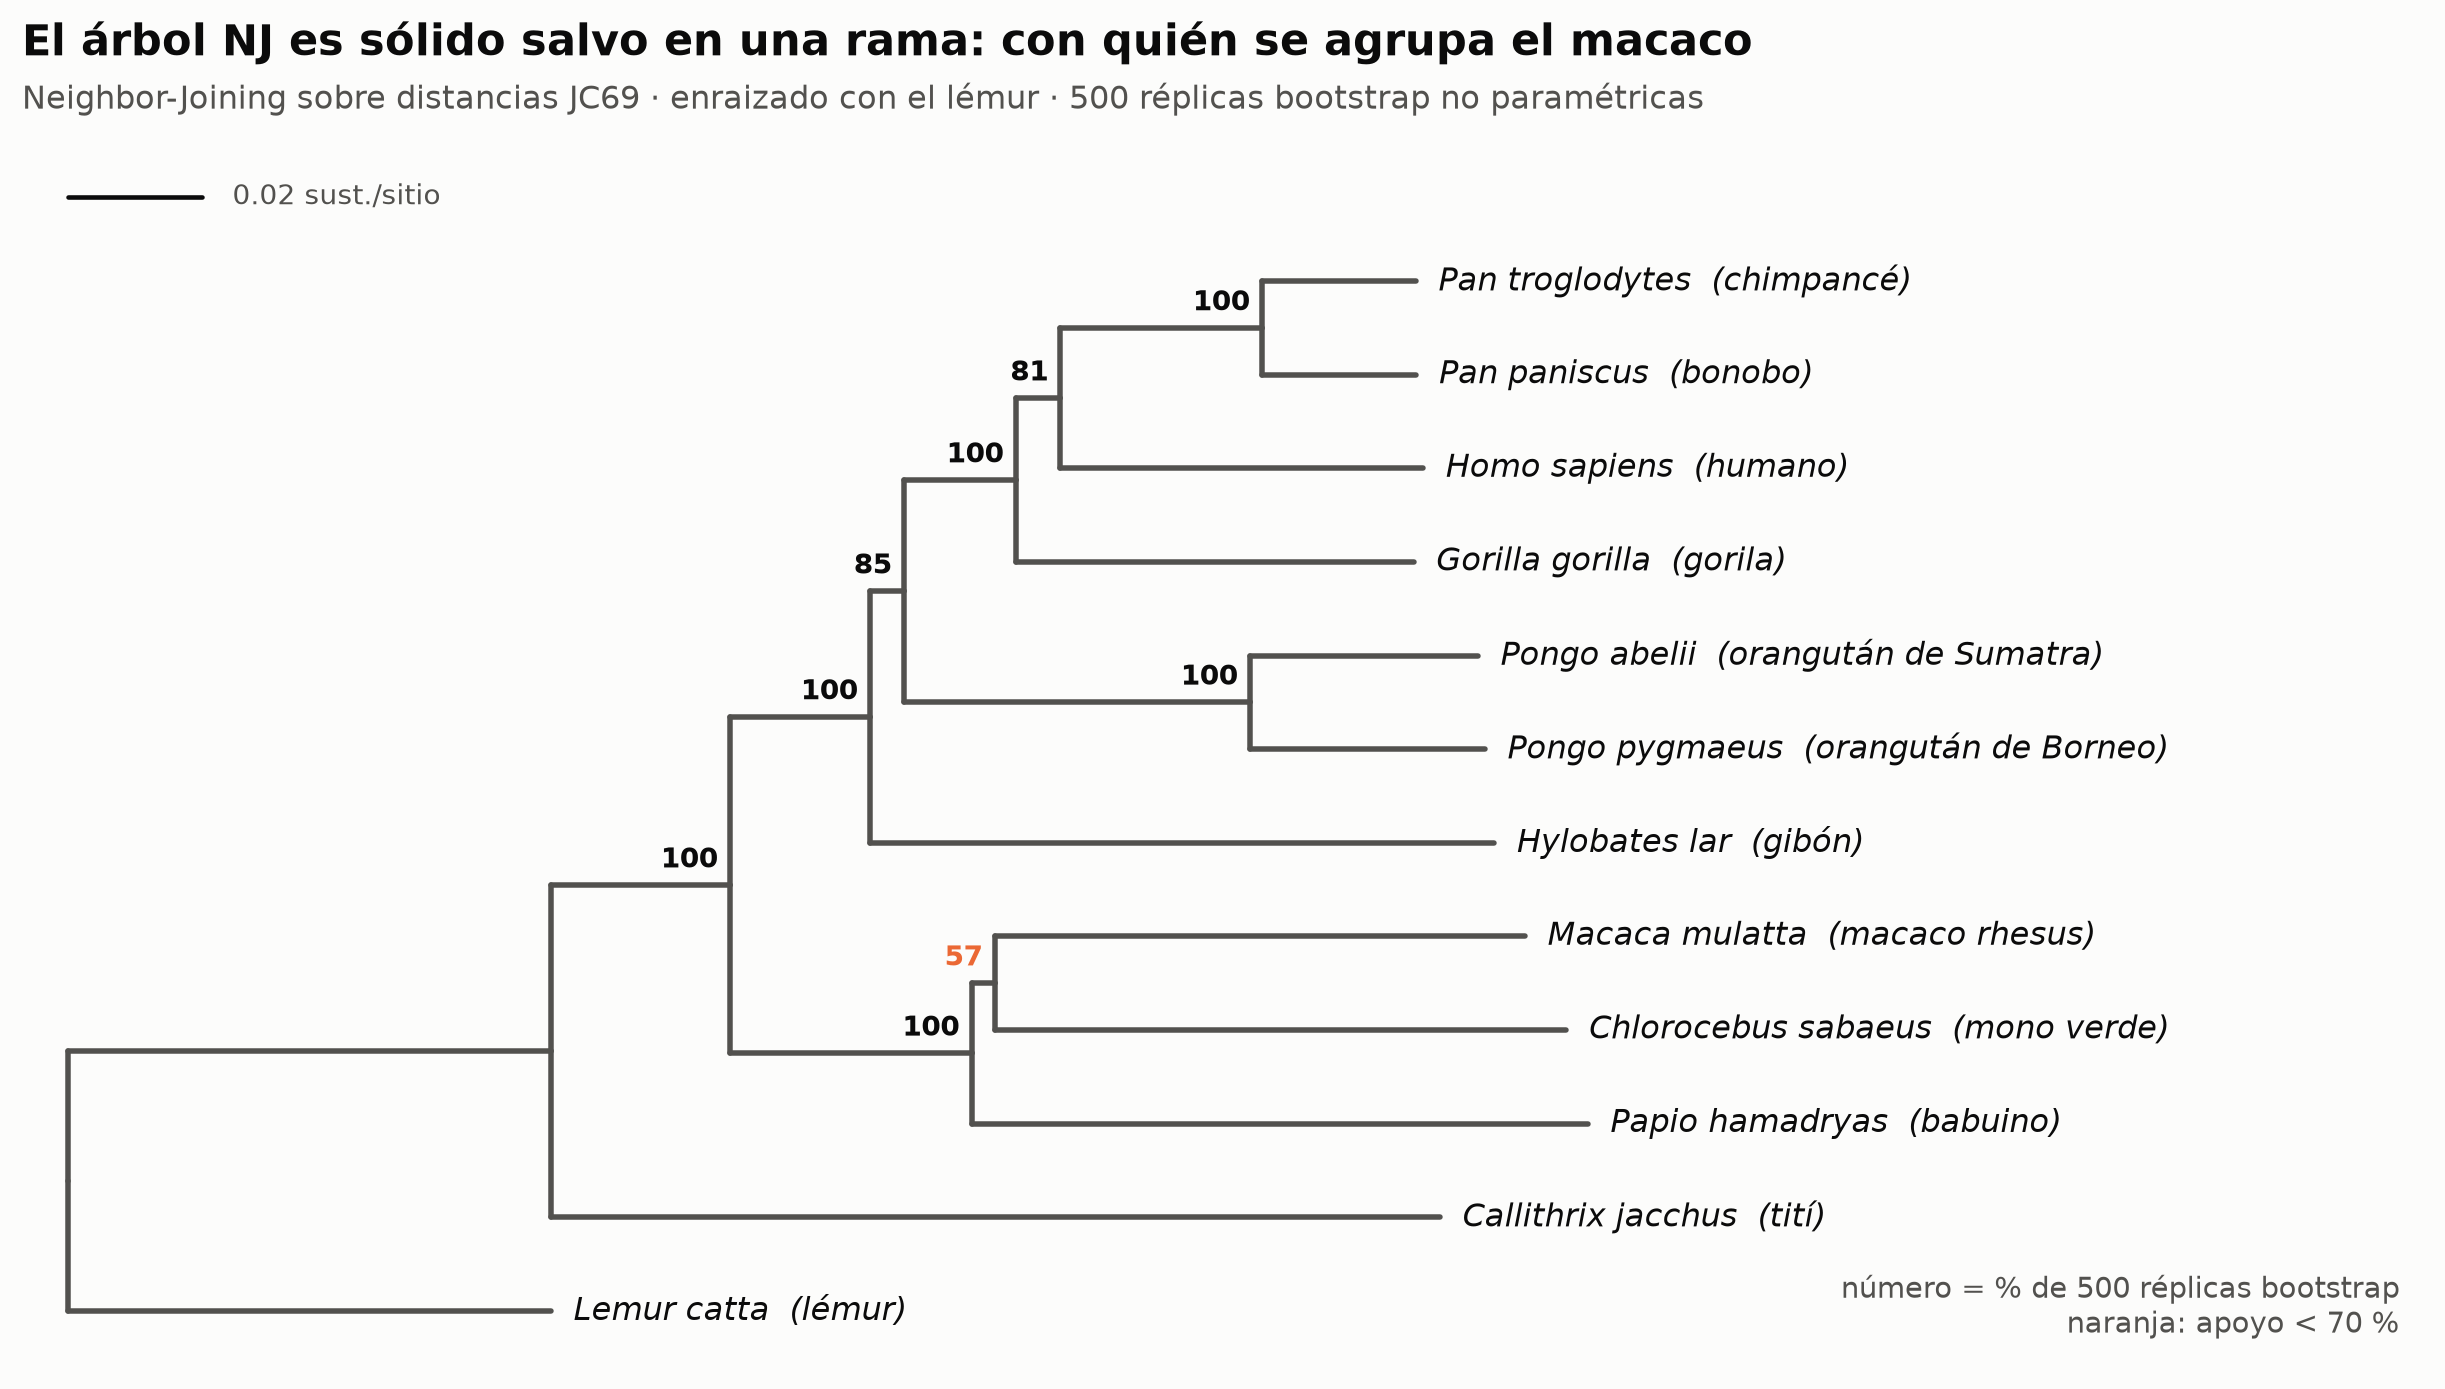

In [24]:
nj_rooted = rooted(newick_tree(nj_newick))
fig, ax = plt.subplots(figsize=(11, 6.2))
draw_tree(ax, nj_rooted, supports=nj_support, label=lambda n: f"{n.replace('_', ' ')}  ({COMMON[n]})", scale=0.02,
          support_color=lambda v: ec.ORANGE if v < 70 else ec.INK, fs=10.5)
ax.text(0.99, 0.02, "número = % de 500 réplicas bootstrap\nnaranja: apoyo < 70 %", transform=ax.transAxes, ha="right",
        va="bottom", fontsize=9.5, color=ec.INK_2)
ec.title(ax, "El árbol NJ es sólido salvo en una rama: con quién se agrupa el macaco",
         "Neighbor-Joining sobre distancias JC69 · enraizado con el lémur · 500 réplicas bootstrap no paramétricas")
plt.show()

> 🔎 **Qué observamos.** Seis de los nueve clados aparecen en el 100 % de las réplicas: la señal es fuerte y está
> repartida por todo el alineamiento. Dos tienen apoyo bueno pero no total (humano + Pan y Hominidae, alrededor del
> 80–85 %), y uno es claramente débil: la rama que une al **macaco con el mono verde** (menos del 60 %). Los estudios con genomas
> completos muestran que el macaco se agrupa en realidad con el **babuino** (tribu Papionini): nuestro NJ con JC69 se
> equivoca, y el bootstrap **nos avisa** de que esa rama no es de fiar. En la animación se ve cómo esa rama "parpadea"
> entre réplicas mientras las demás se mantienen.
>
> ¿Cómo interpretar los números? Un bootstrap del 95 % **no** significa "95 % de probabilidad de que el clado sea
> verdadero": mide la **estabilidad** del resultado frente al muestreo de columnas, con ese método y ese modelo. Si el
> modelo es malo, el bootstrap puede apoyar con fuerza un clado equivocado. Tradicionalmente se consideran confiables
> los valores ≥ 70 % (Hillis y Bull 1993).

✅ **Compruebe su comprensión.** ¿Por qué el bootstrap no puede apoyar una rama que no está en el árbol original, pero
sí podemos contar cuántas réplicas tienen **otras** ramas? (Respuesta: el apoyo se calcula sobre los clados del árbol
de referencia; las ramas alternativas de las réplicas, como "macaco + babuino", se cuentan igual con `split_counts` y
muestran cuál es la alternativa más apoyada.)

In [25]:
alt = sorted(((c, s) for s, c in split_counts.items() if s not in nj_splits), key=lambda x: -x[0])[:4]
print("Clados que NO están en el árbol NJ pero aparecen en réplicas:")
for c, s in alt:
    print(f"  {split_name(s):<32} {100 * c / B:5.1f} % de las réplicas")

Clados que NO están en el árbol NJ pero aparecen en réplicas:
  macaco + babuino                  34.8 % de las réplicas
  gorila + bonobo + chimpancé       18.6 % de las réplicas
  gorila + humano + gibón + bonobo + chimp  11.2 % de las réplicas
  babuino + mono verde               8.2 % de las réplicas


## 9. 🧪 IQ-TREE 2 de verdad: ModelFinder + UFBoot

Todo lo que programamos existe, en versión industrial, en **IQ-TREE** (Nguyen et al. 2015; IQ-TREE 2: Minh et al.
2020), uno de los programas de máxima verosimilitud más usados. Con una sola orden hace tres cosas:

| Opción | Qué hace | Lo que hicimos a mano |
|---|---|---|
| `-m MFP` | **ModelFinder** (Kalyaanamoorthy et al. 2017): prueba decenas de modelos (JC, K80, HKY, TN, TIM, GTR… con +I, +G, +R) y elige por BIC | sección 7 con 4 modelos |
| búsqueda del árbol | parte de varios árboles rápidos y los mejora con NNI y perturbaciones aleatorias | sección 6 con 3 topologías |
| `-B 1000` | **UFBoot2** (Hoang et al. 2018): *ultrafast bootstrap*, una aproximación rápida al bootstrap | sección 8 con NJ |

Otras opciones: `-s` es el alineamiento, `--prefix` el nombre de los archivos de salida, `-T 2` usa dos núcleos,
`-seed` fija la semilla (resultados reproducibles) y `-redo` sobrescribe una corrida anterior.

La celda instala el binario oficial de IQ-TREE 2 en Colab (o, si falla, el paquete `iqtree` de Ubuntu). Fuera de
Colab usa el que encuentre en el `PATH`; si no hay ninguno, carga los resultados precalculados que acompañan al curso
(generados con IQ-TREE 2.4.0 y la misma orden).

In [26]:
IQ_URL = "https://github.com/iqtree/iqtree2/releases/download/v2.4.0/iqtree-2.4.0-Linux-intel.tar.gz"
IQ_LOCAL = os.path.abspath("iqtree-2.4.0-Linux-intel/bin/iqtree2")

def find_iqtree():
    for exe in ("iqtree2", "iqtree3", "iqtree"):
        if shutil.which(exe):
            return shutil.which(exe)
    return IQ_LOCAL if os.path.exists(IQ_LOCAL) else None

IQTREE = find_iqtree()
if IQTREE is None and IN_COLAB:
    try:                                                   # 1) binario oficial (GitHub del proyecto IQ-TREE)
        urllib.request.urlretrieve(IQ_URL, "iqtree.tar.gz")
        with tarfile.open("iqtree.tar.gz") as tf:
            tf.extractall()
        os.chmod(IQ_LOCAL, 0o755)
    except Exception as err:                               # 2) paquete de Ubuntu (IQ-TREE 2.0.x)
        print("⚠️ No se pudo descargar el binario oficial:", err, "→ pruebo apt")
        !apt-get -qq install -y iqtree > /dev/null
    IQTREE = find_iqtree()

HAS_IQTREE = IQTREE is not None
if HAS_IQTREE:
    version = subprocess.run([IQTREE, "--version"], capture_output=True, text=True).stdout.splitlines()[0]
    print("IQ-TREE disponible:", IQTREE, "\n", version)
else:
    print("⚠️ IQ-TREE no está disponible aquí: usaré los resultados precalculados del curso (IQ-TREE 2.4.0).")

⚠️ IQ-TREE no está disponible aquí: usaré los resultados precalculados del curso (IQ-TREE 2.4.0).


In [27]:
if HAS_IQTREE:
    cmd = [IQTREE, "-s", ALN_FILE, "-m", "MFP", "-B", "1000", "-T", "2",
           "--prefix", "primates", "-seed", "12345", "-redo", "-quiet"]
    print("$", " ".join(os.path.basename(c) if i == 0 else c for i, c in enumerate(cmd)))
    t0 = time.time()
    run = subprocess.run(cmd, capture_output=True, text=True)
    print(f"Terminó en {time.time() - t0:.0f} s (código de salida {run.returncode})")
    iqtree_report = open("primates.iqtree").read()
    treefile = open("primates.treefile").read()
else:
    iqtree_report = course_bytes("primates_iqtree2.iqtree").decode()
    treefile = course_bytes("primates_iqtree2.treefile").decode()

print(sorted(f for f in os.listdir(".") if f.startswith("primates.")))
print("\n".join(iqtree_report.splitlines()[:3]))

[]
IQ-TREE 2.4.0 built Mar  8 2025

Input file name: primates_mt_cytb_cox1.fasta


IQ-TREE escribe varios archivos. Los dos más importantes son:

* **`primates.iqtree`**: el informe legible (modelo elegido, parámetros, tabla de ModelFinder, árbol en texto).
* **`primates.treefile`**: el árbol de máxima verosimilitud en formato Newick, con los valores de UFBoot como
  etiquetas de los nodos internos: `(A:0.1,B:0.2)98:0.05` significa que el clado (A, B) tiene 98 % de UFBoot.

Leamos el informe con expresiones regulares (funcionan igual con IQ-TREE 2.0, 2.4 o 3).

In [28]:
def grab(pattern, text, cast=float):
    m = re.search(pattern, text)
    return cast(m.group(1)) if m else None

best_fit = grab(r"Best-fit model according to BIC:\s*(\S+)", iqtree_report, str)
iq_logl = grab(r"Log-likelihood of the tree:\s*(-?[\d.]+)", iqtree_report)
iq_alpha = grab(r"Gamma shape alpha:\s*([\d.]+)", iqtree_report)
iq_pinv = grab(r"Proportion of invariable sites:\s*([\d.]+)", iqtree_report)
iq_rates = dict(re.findall(r"\s([ACGT]-[ACGT]):\s*([\d.]+)", iqtree_report))

mf_rows = []
block = iqtree_report.split("List of models sorted by BIC scores:")[1].split("AIC, w-AIC")[0]
for line in block.strip().splitlines()[1:]:
    tok = line.split()
    if not tok:
        continue
    nums = [float(x) for x in tok[1:] if x not in "+-"]
    mf_rows.append(dict(modelo=tok[0], logL=nums[0], AIC=nums[1], BIC=nums[5]))
mf = pd.DataFrame(mf_rows)
mf["ΔBIC"] = mf.BIC - mf.BIC.min()

print(f"Modelo elegido por BIC: {best_fit}")
print(f"ℓ del árbol ML: {iq_logl}   ·   α (gamma) = {iq_alpha}   ·   sitios invariables = {iq_pinv}")
print("Tasas relativas de cada cambio:", {k: float(v) for k, v in iq_rates.items()})
mf.head(8)

Modelo elegido por BIC: TIM2+F+I+G4
ℓ del árbol ML: -15006.7728   ·   α (gamma) = 1.487   ·   sitios invariables = 0.4685
Tasas relativas de cada cambio: {'A-C': 2.5833, 'A-G': 21.635, 'A-T': 2.5833, 'C-G': 1.0, 'C-T': 28.0209, 'G-T': 1.0}


,modelo,logL,AIC,BIC,ΔBIC
0,TIM2+F+I+G4,-15006.839,30071.679,30242.549,0.000
1,TPM2u+F+I+G4,-15011.315,30078.630,30243.608,1.059
2,GTR+F+I+G4,-15003.868,30069.735,30252.390,9.841
3,TVM+F+I+G4,-15008.193,30076.386,30253.148,10.599
4,K3Pu+F+I+G4,-15019.582,30095.164,30260.142,17.593
5,TIM+F+I+G4,-15016.373,30090.745,30261.615,19.066
6,HKY+F+I+G4,-15025.888,30105.775,30264.861,22.312
7,TN+F+I+G4,-15022.778,30101.555,30266.533,23.984


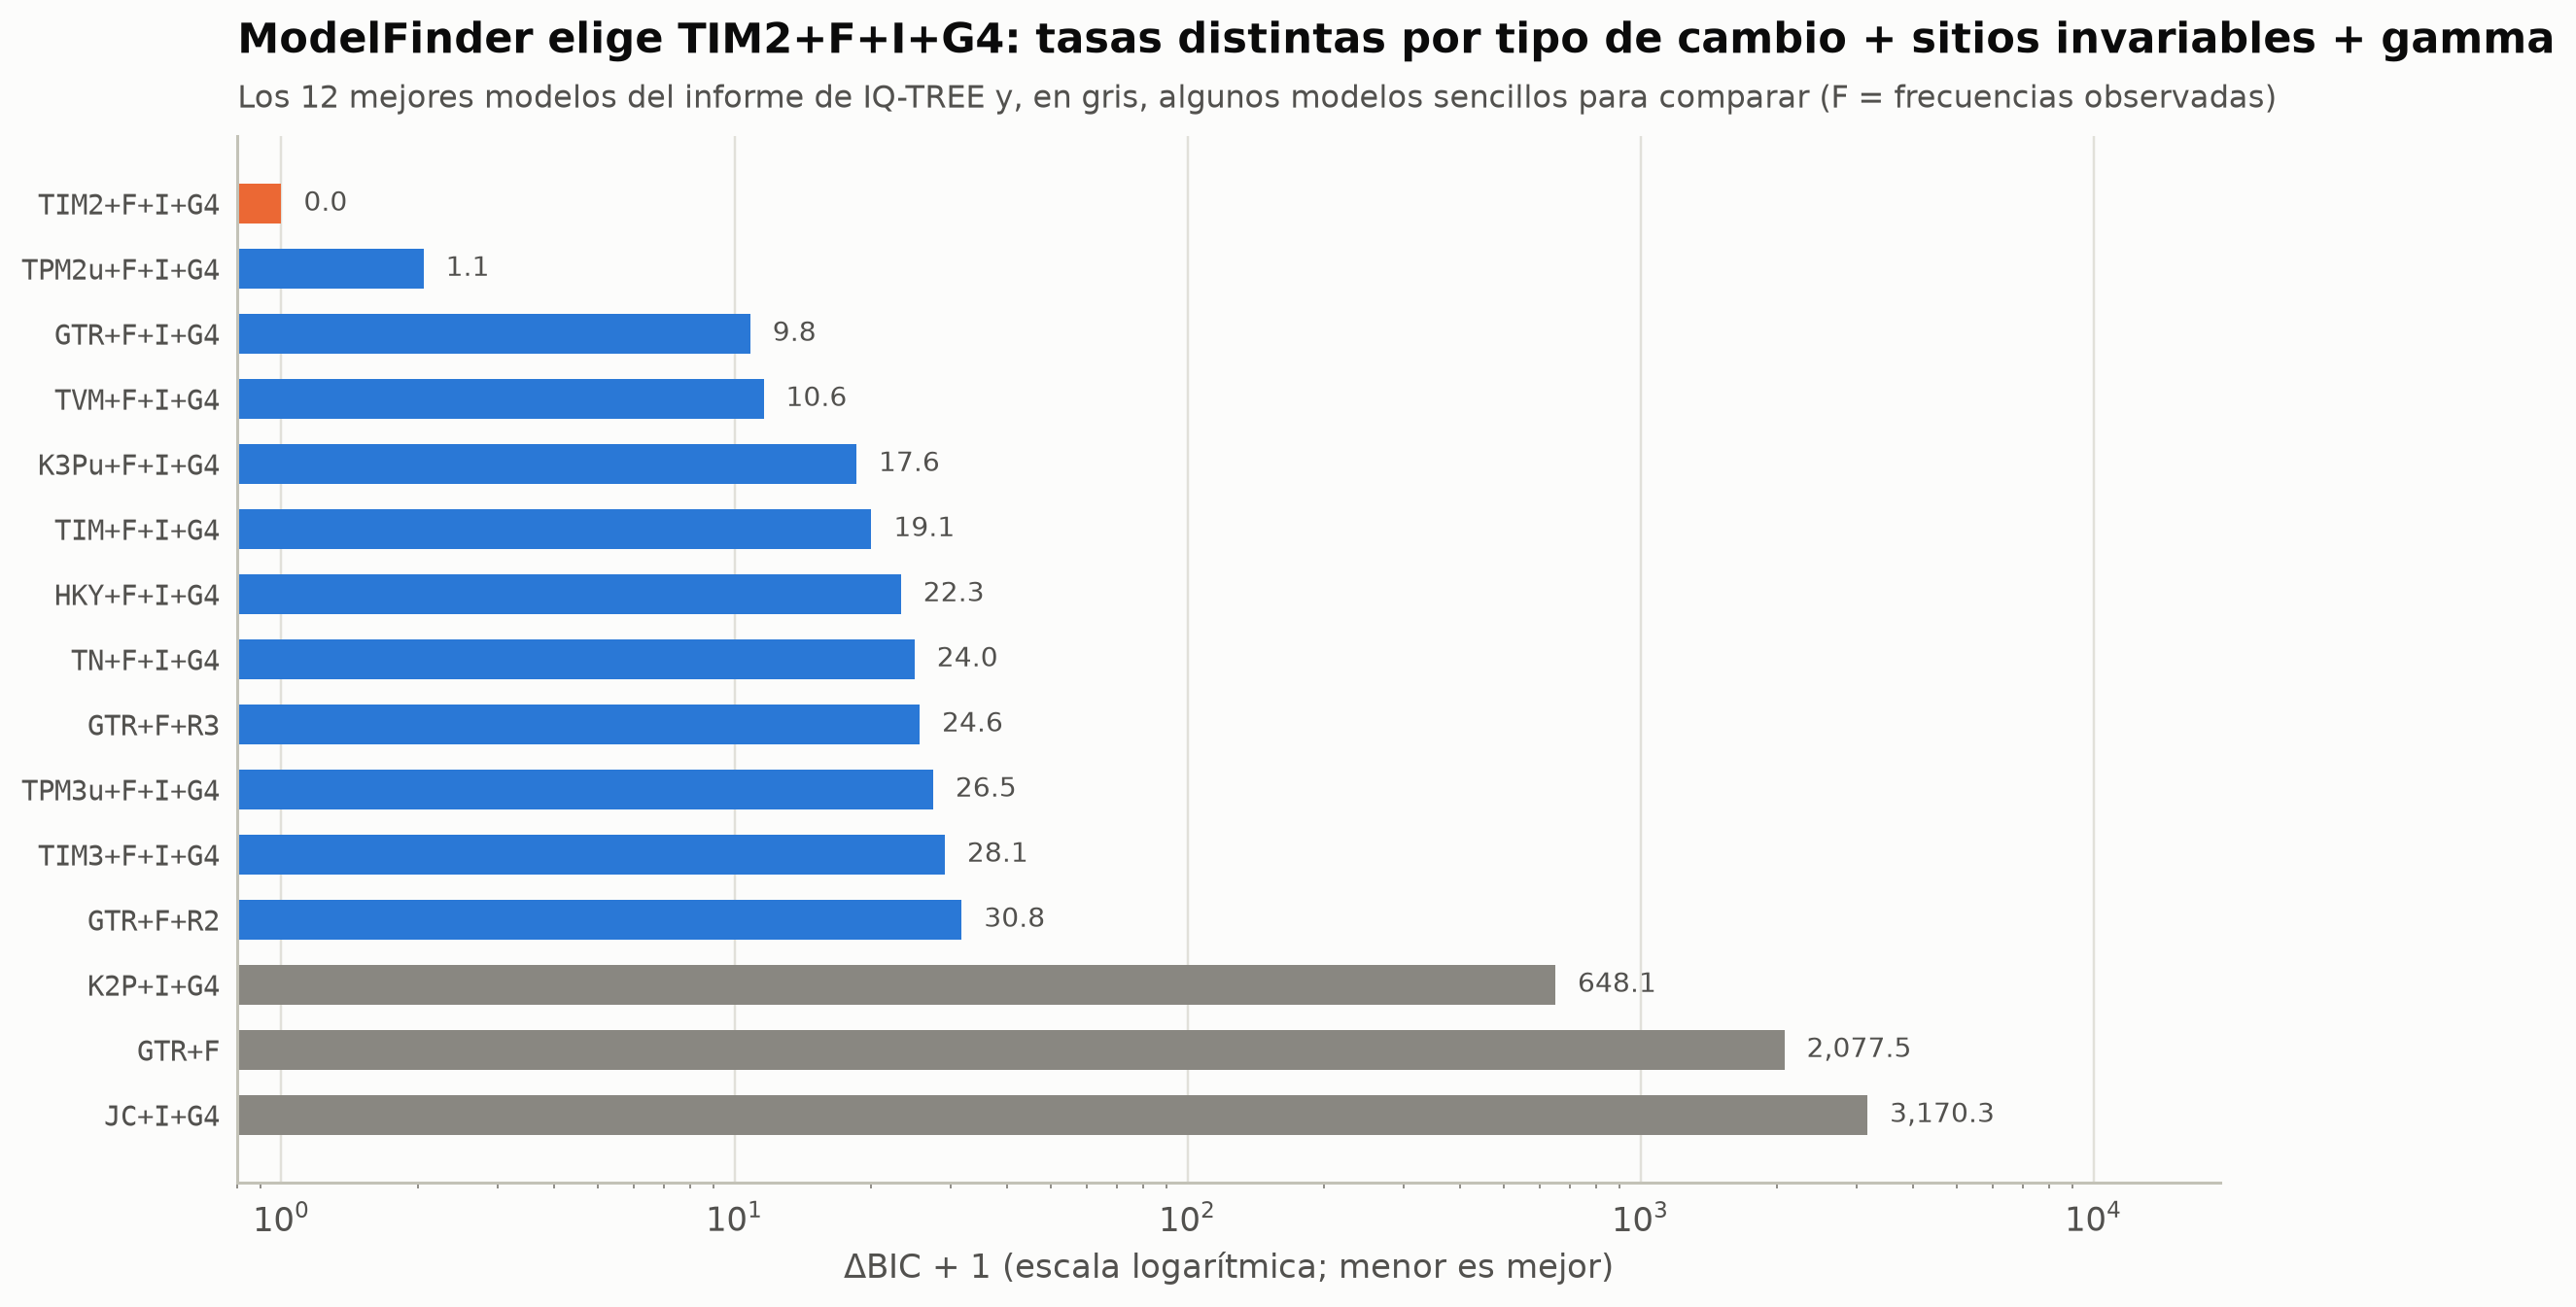

In [29]:
show_mf = pd.concat([mf.head(12), mf[mf.modelo.isin(["HKY+F+I+G4", "K2P+I+G4", "JC+I+G4", "GTR+F"])]]).drop_duplicates("modelo")
show_mf = show_mf.sort_values("ΔBIC")
fig, ax = plt.subplots(figsize=(11, 6))
yy = np.arange(len(show_mf))
cols = [ec.ORANGE if m == best_fit else (ec.MUTED if d > 100 else ec.BLUE) for m, d in zip(show_mf.modelo, show_mf["ΔBIC"])]
ax.barh(yy, show_mf["ΔBIC"] + 1, color=cols, height=0.62)
ax.set_xscale("log")
for y, (m, d) in enumerate(zip(show_mf.modelo, show_mf["ΔBIC"])):
    ax.text((d + 1) * 1.12, y, f"{d:,.1f}", va="center", fontsize=9, color=ec.INK_2)
ax.set_yticks(yy, show_mf.modelo, family="DejaVu Sans Mono", fontsize=9.5); ax.invert_yaxis()
ax.set_xlim(0.8, show_mf["ΔBIC"].max() * 6)
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
ax.set_xlabel("ΔBIC + 1 (escala logarítmica; menor es mejor)")
ec.title(ax, f"ModelFinder elige {best_fit}: tasas distintas por tipo de cambio + sitios invariables + gamma",
         "Los 12 mejores modelos del informe de IQ-TREE y, en gris, algunos modelos sencillos para comparar (F = frecuencias observadas)")
plt.show()

> 🔎 **Qué observamos.** Los modelos del podio tienen algo en común: **+F** (frecuencias desiguales), **+I+G4**
> (sitios invariables más gamma) y tasas distintas para las transiciones A↔G y C↔T (TIM2, TPM2u, GTR). Los que no usan
> gamma o frecuencias observadas (abajo, en gris) quedan a cientos o miles de unidades de BIC. Nuestra conclusión de la
> sección 7 se sostiene: la heterogeneidad entre sitios es el ingrediente más importante.

### Validación cruzada: ¿nuestro código calcula lo mismo que IQ-TREE?

La mejor prueba de que entendimos el algoritmo: darle a IQ-TREE **nuestro** árbol NJ fijo (`-te`) y los mismos modelos
(`JC`, `K2P` = K80, `HKY+F` = nuestro HKY con frecuencias observadas, `HKY+F+G4`), dejar que optimice las ramas y
comparar las log-verosimilitudes.

In [30]:
Phylo.write(newick_tree(nj_newick), "nj_tree.nwk", "newick")
IQ_NAMES = {"JC69": "JC", "K80": "K2P", "HKY": "HKY+F", "HKY+Γ": "HKY+F+G4"}
check = []
for ours, theirs in IQ_NAMES.items():
    row = dict(modelo=ours, IQTREE_modelo=theirs, logL_nuestro=models_df.set_index("modelo").loc[ours, "logL"])
    if HAS_IQTREE:
        subprocess.run([IQTREE, "-s", ALN_FILE, "-m", theirs, "-te", "nj_tree.nwk", "--prefix", f"check_{ours}",
                        "-redo", "-quiet", "-T", "1"], capture_output=True, text=True)
        row["logL_IQTREE"] = grab(r"Log-likelihood of the tree:\s*(-?[\d.]+)", open(f"check_{ours}.iqtree").read())
        row["diferencia"] = row["logL_nuestro"] - row["logL_IQTREE"]
    check.append(row)
check = pd.DataFrame(check)
if not HAS_IQTREE:
    print("(Sin IQ-TREE aquí; en Colab verá la columna de IQ-TREE. Referencia 2.4.0: JC −17463.78, K2P −16345.02, "
          "HKY+F −16164.83, HKY+F+G4 −15051.87)")
check.round(4)

(Sin IQ-TREE aquí; en Colab verá la columna de IQ-TREE. Referencia 2.4.0: JC −17463.78, K2P −16345.02, HKY+F −16164.83, HKY+F+G4 −15051.87)


,modelo,IQTREE_modelo,logL_nuestro
0,JC69,JC,-17463.7758
1,K80,K2P,-16345.0246
2,HKY,HKY+F,-16164.8257
3,HKY+Γ,HKY+F+G4,-15051.8657


> 🔎 **Qué observamos.** Las log-verosimilitudes coinciden en los decimales (con +G4 la diferencia puede ser de
> centésimas, porque los optimizadores se detienen en puntos ligeramente distintos). Nuestro algoritmo de poda de
> unas 20 líneas calcula lo mismo que un programa profesional; lo que IQ-TREE añade es **velocidad** (código en C++,
> vectorización, varios núcleos), muchos más **modelos** y, sobre todo, la **búsqueda** del árbol.

### El árbol final

Ahora dibujemos el árbol de máxima verosimilitud de IQ-TREE con calidad de publicación: enraizado con el lémur,
longitudes de rama del modelo elegido, apoyos UFBoot y, a su lado, nuestro bootstrap NJ para los mismos clados.

In [31]:
ml_tree = newick_tree(treefile)
ufboot = tree_splits(ml_tree)                       # {bipartición: UFBoot} leído del .treefile
ml_rooted = rooted(newick_tree(treefile))

nj_all = {s: 100 * split_counts.get(s, 0) / B for s in ufboot}
compare = pd.DataFrame([(split_name(s), ufboot[s], nj_all[s], s in nj_splits) for s in ufboot],
                       columns=["clado", "UFBoot (IQ-TREE)", "bootstrap NJ (nuestro)", "¿en el árbol NJ?"])
print("Topología idéntica a la de NJ:", set(ufboot) == set(nj_splits))
compare.sort_values("UFBoot (IQ-TREE)")

Topología idéntica a la de NJ: False


,clado,UFBoot (IQ-TREE),bootstrap NJ (nuestro),¿en el árbol NJ?
7,macaco + babuino,78,34.8,False
4,Hominidae (grandes simios),94,84.6,True
5,Hominoidea (simios),96,100.0,True
1,humano + Pan,98,81.4,True
0,chimpancé + bonobo,100,100.0,True
2,Homininae (+ gorila),100,100.0,True
3,orangutanes,100,100.0,True
6,Cercopitécidos,100,100.0,True
8,Catarrinos (monos del Viejo Mundo y simios),100,100.0,True


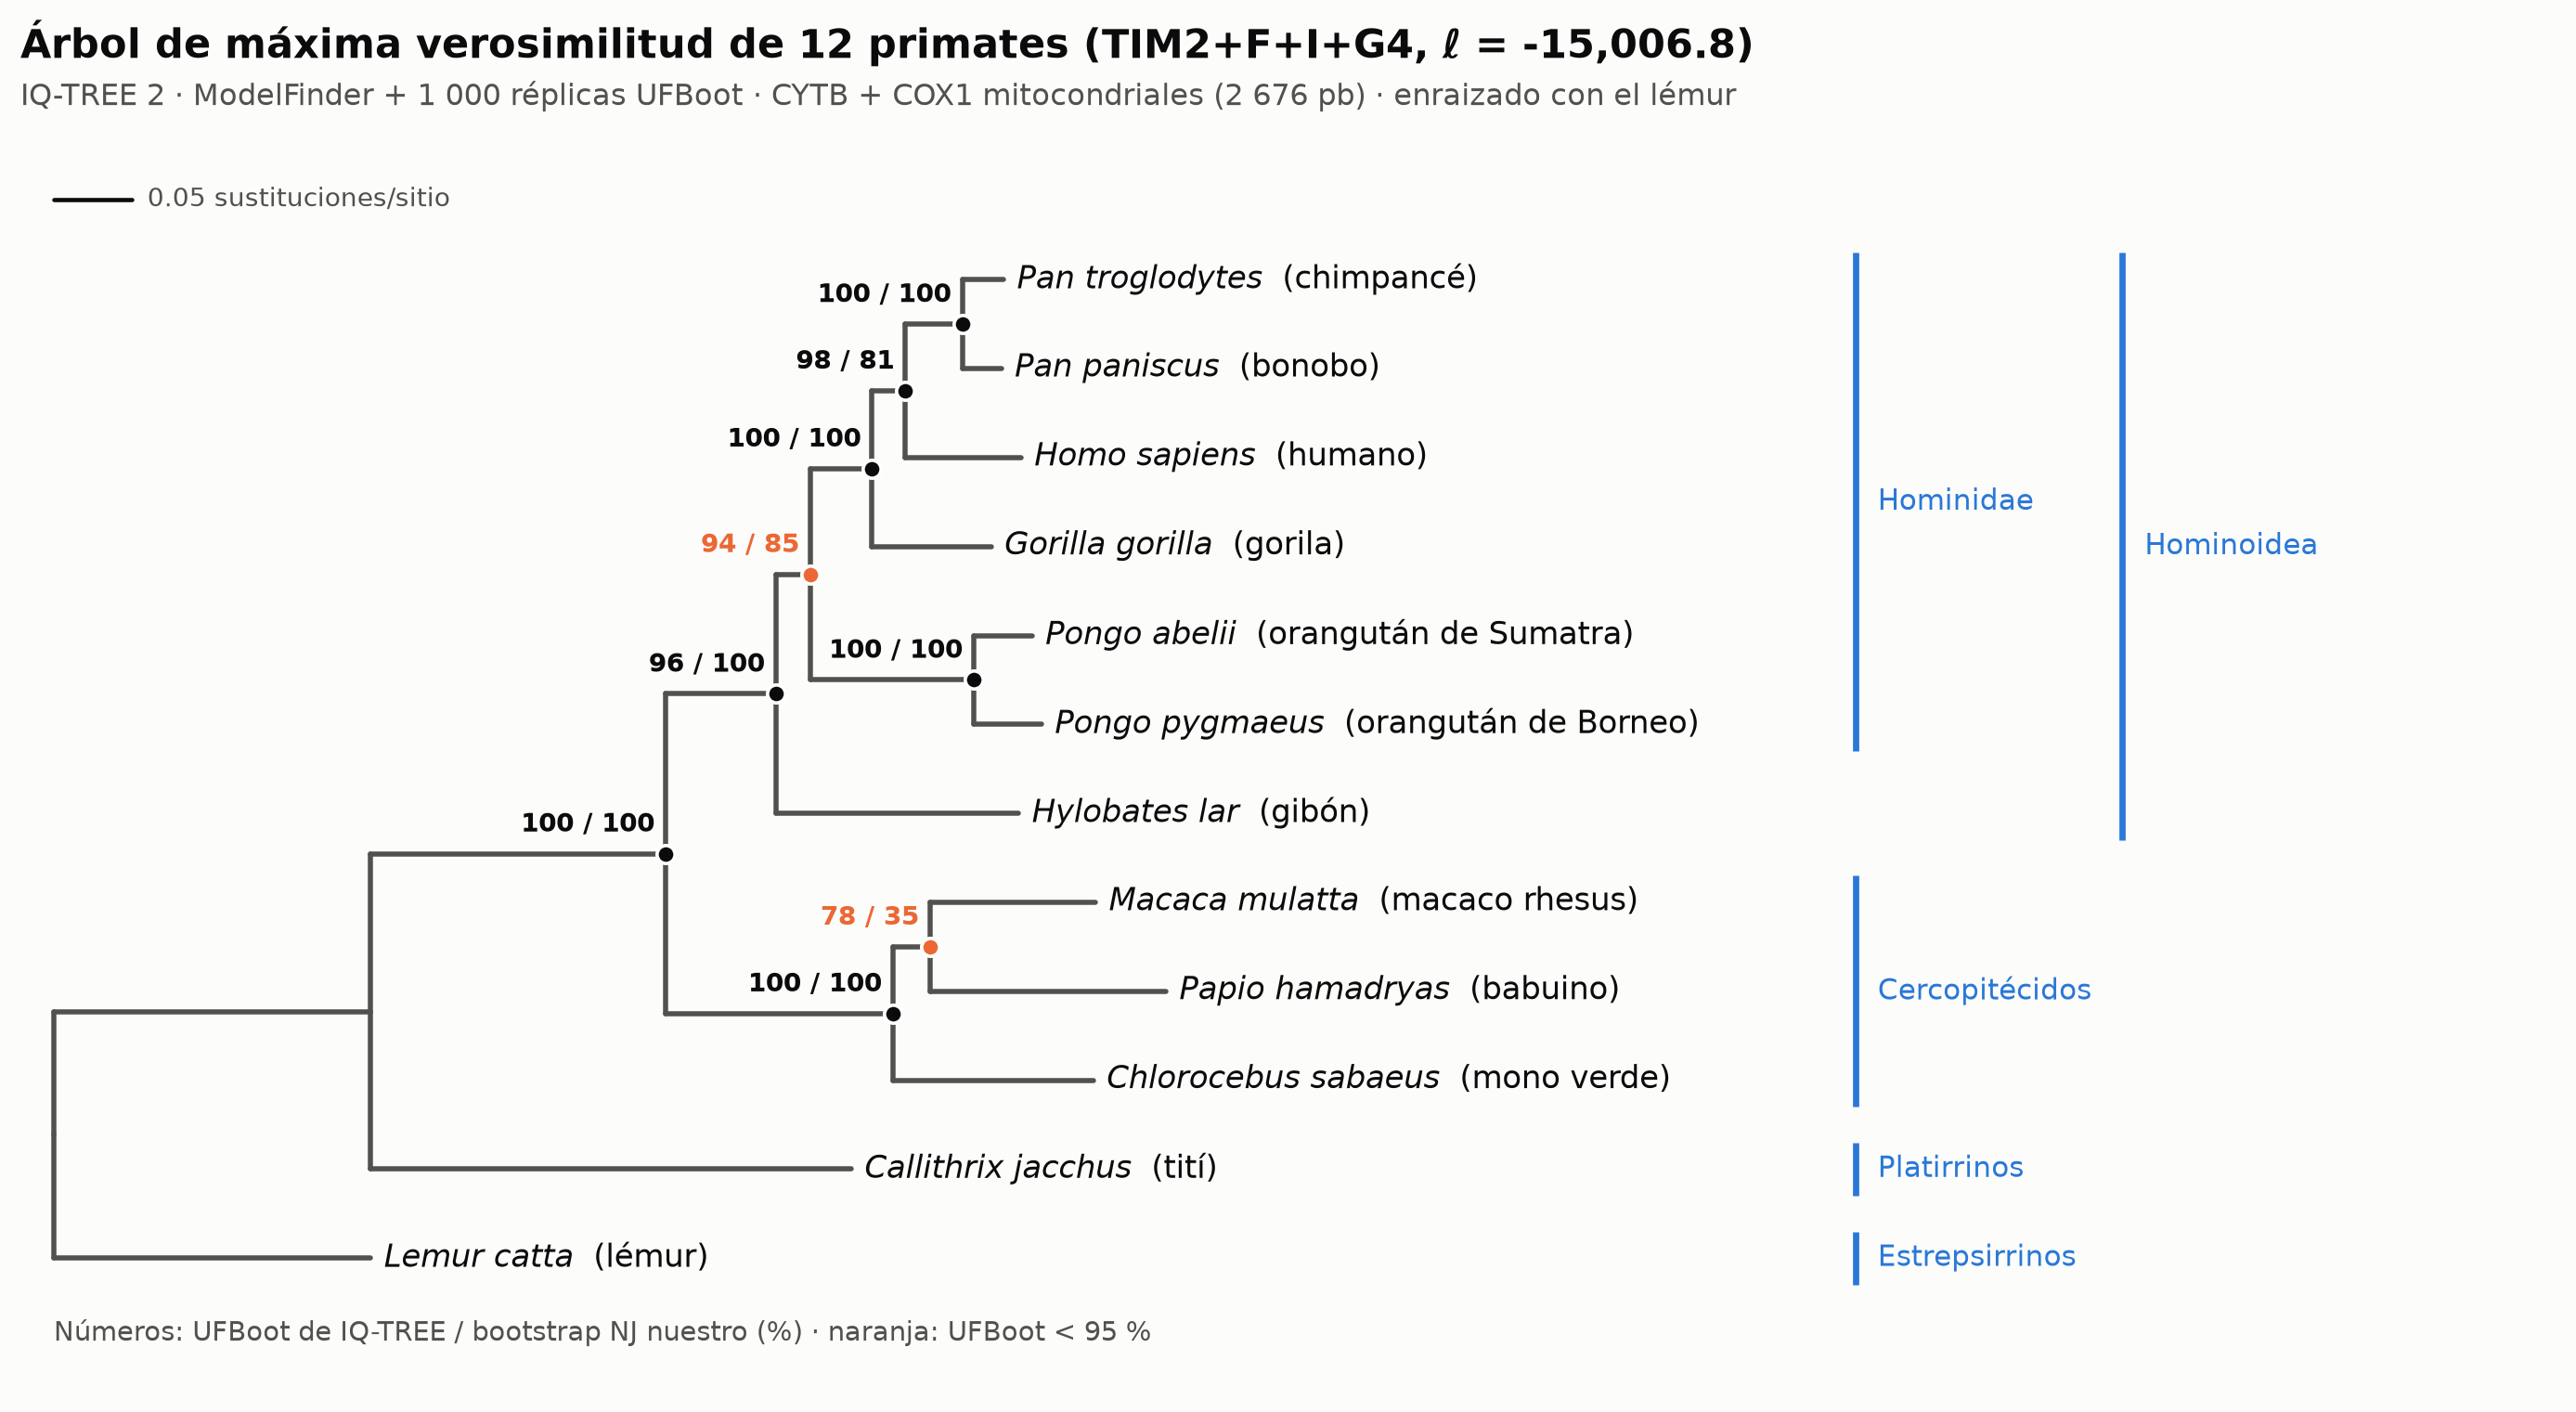

In [32]:
def support_text(s):
    u, n = ufboot.get(s), nj_all.get(s)
    return None if u is None else f"{u:.0f} / {n:.0f}"

fig, ax = plt.subplots(figsize=(12.5, 6.8))
xs, ys = tree_coords(ml_rooted)
xmax = max(xs.values())
for clade in ml_rooted.find_clades():
    for ch in clade.clades:
        ax.plot([xs[clade], xs[clade]], [ys[clade], ys[ch]], color=ec.INK_2, lw=1.8, solid_capstyle="round")
        ax.plot([xs[clade], xs[ch]], [ys[ch], ys[ch]], color=ec.INK_2, lw=1.8, solid_capstyle="round")
for leaf in ml_rooted.get_terminals():
    ax.text(xs[leaf] + xmax * 0.012, ys[leaf], r"$\it{" + leaf.name.replace("_", r"\ ") + "}$" + f"  ({COMMON[leaf.name]})",
            va="center", fontsize=11, color=ec.INK)
for clade in ml_rooted.get_nonterminals():
    key = frozenset(t.name for t in clade.get_terminals())
    if key in ufboot:
        u = ufboot[key]
        col = ec.INK if u >= 95 else ec.ORANGE
        ax.scatter([xs[clade]], [ys[clade]], s=40, color=col, edgecolor="white", linewidth=1.2, zorder=4)
        ax.text(xs[clade] - xmax * 0.01, ys[clade] - 0.18, support_text(key), ha="right", va="bottom", fontsize=9,
                color=col, fontweight="bold")
# corchetes de grupos taxonómicos a la derecha
brackets = [("Hominidae", APES), ("Hominoidea", APES | {"Hylobates_lar"}),
            ("Cercopitécidos", {"Macaca_mulatta", "Papio_hamadryas", "Chlorocebus_sabaeus"}),
            ("Platirrinos", {"Callithrix_jacchus"}), ("Estrepsirrinos", {"Lemur_catta"})]
xb = {"Hominidae": xmax * 1.62, "Hominoidea": xmax * 1.86}
for label, members in brackets:
    yv = [ys[l] for l in ml_rooted.get_terminals() if l.name in members]
    xx = xb.get(label, xmax * 1.62)
    ax.plot([xx, xx], [min(yv) - 0.3, max(yv) + 0.3], color=ec.BLUE, lw=2.2, solid_capstyle="butt")
    ax.text(xx + xmax * 0.02, np.mean(yv), label, va="center", fontsize=10, color=ec.BLUE)
ax.plot([0, 0.05], [-0.9, -0.9], color=ec.INK, lw=1.5)
ax.text(0.06, -0.9, "0.05 sustituciones/sitio", ha="left", va="center", fontsize=9, color=ec.INK_2)
ax.text(0.0, 12.0, "Números: UFBoot de IQ-TREE / bootstrap NJ nuestro (%) · naranja: UFBoot < 95 %",
        fontsize=9.5, color=ec.INK_2, va="bottom")
ax.set_xlim(-xmax * 0.03, xmax * 2.25); ax.set_ylim(12.5, -1.6); ax.axis("off")
ec.title(ax, f"Árbol de máxima verosimilitud de 12 primates ({best_fit}, ℓ = {iq_logl:,.1f})",
         "IQ-TREE 2 · ModelFinder + 1 000 réplicas UFBoot · CYTB + COX1 mitocondriales (2 676 pb) · enraizado con el lémur")
plt.show()

> 🔎 **Qué observamos.** Con el modelo elegido por ModelFinder, la máxima verosimilitud corrige el error de NJ: el
> macaco se agrupa con el **babuino** (Papionini), como indican los estudios con genomas completos, aunque con un apoyo
> moderado (UFBoot < 95 %). El otro nodo en naranja, Hominidae (orangutanes con humano, chimpancé y gorila), queda
> justo en el límite (UFBoot 94 %): una rama interna corta y antigua. El resto del árbol coincide con la taxonomía: humano con chimpancé y bonobo, luego gorila,
> orangutanes, gibón; los monos del Viejo Mundo; el tití (Nuevo Mundo) y el lémur (estrepsirrino) como linajes
> externos.
>
> Dos advertencias de interpretación. UFBoot y el bootstrap clásico **no están en la misma escala**: para UFBoot se
> recomienda confiar en valores **≥ 95 %** (Hoang et al. 2018), mientras que para el bootstrap clásico suele usarse
> ≥ 70 %. Y observe las longitudes: la rama del tití y la del lémur son muy largas. Con 2.7 kb de genes mitocondriales,
> la parte profunda del árbol está cerca de la **saturación**; para ella convendría usar genes nucleares o las
> secuencias de proteínas.

### El mismo árbol, interactivo

Pase el cursor por cada nodo interno para ver qué especies agrupa, su apoyo UFBoot y bootstrap NJ, y la longitud de
su rama; por cada hoja, la especie, el número de acceso y la distancia a la raíz.

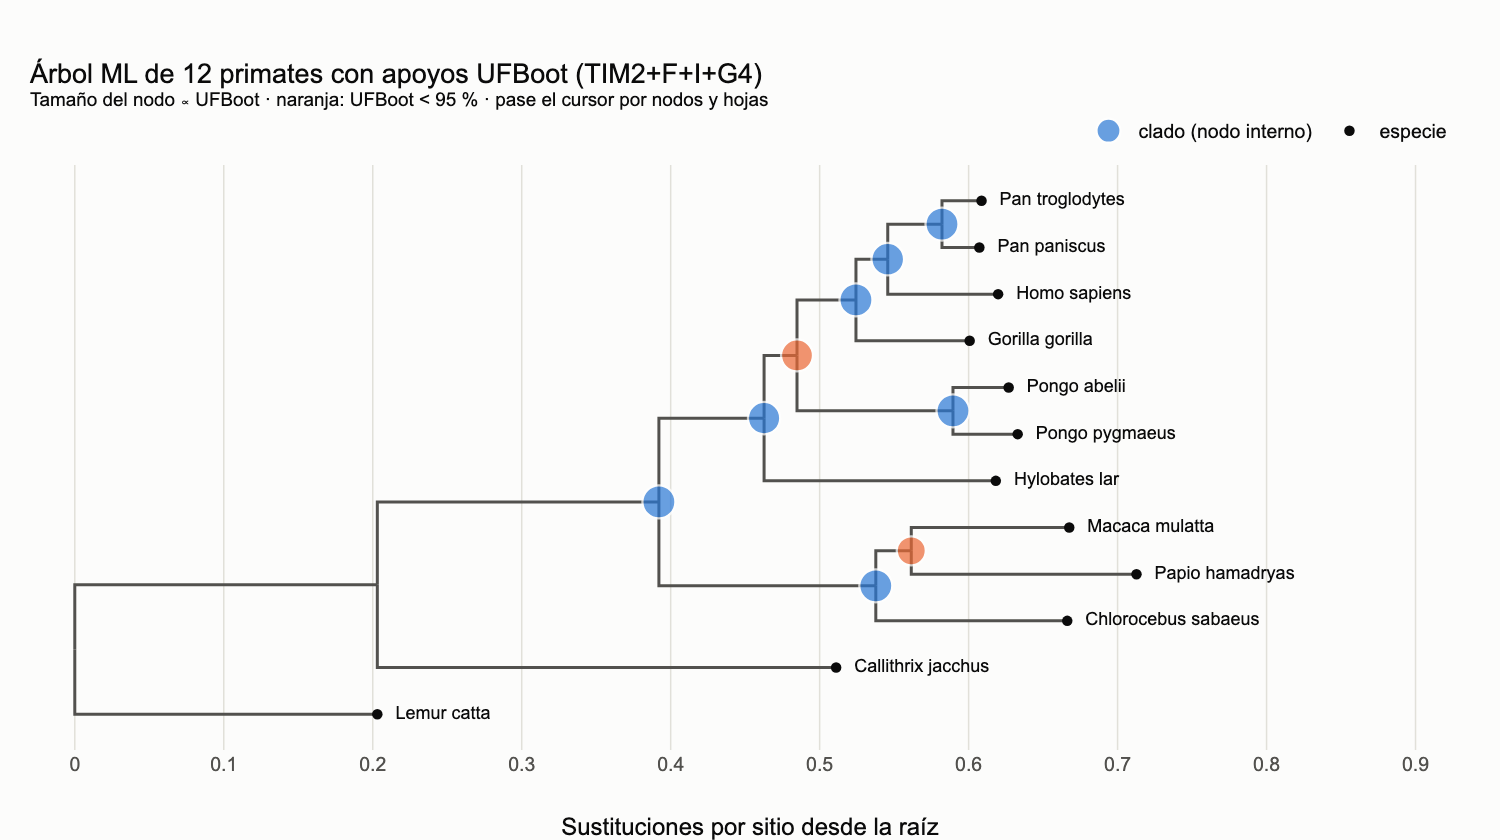

In [33]:
line_x, line_y = [], []
for clade in ml_rooted.find_clades():
    for ch in clade.clades:
        line_x += [xs[clade], xs[clade], xs[ch], None]
        line_y += [ys[clade], ys[ch], ys[ch], None]
fig = go.Figure()
fig.add_scatter(x=line_x, y=line_y, mode="lines", line=dict(color=ec.INK_2, width=2), hoverinfo="skip", showlegend=False)
nodes = [c for c in ml_rooted.get_nonterminals() if frozenset(t.name for t in c.get_terminals()) in ufboot]
node_keys = [frozenset(t.name for t in c.get_terminals()) for c in nodes]
fig.add_scatter(
    x=[xs[c] for c in nodes], y=[ys[c] for c in nodes], mode="markers", name="clado (nodo interno)",
    marker=dict(size=[10 + 0.12 * ufboot[k] for k in node_keys],
                color=[ec.BLUE if ufboot[k] >= 95 else ec.ORANGE for k in node_keys], line=dict(color="white", width=1.5)),
    customdata=[[split_name(k), ufboot[k], nj_all[k], c.branch_length or 0, len(k),
                 ", ".join(COMMON[t] for t in sorted(k))] for c, k in zip(nodes, node_keys)],
    hovertemplate=("<b>%{customdata[0]}</b><br>%{customdata[4]} especies: %{customdata[5]}"
                   "<br>UFBoot (IQ-TREE): <b>%{customdata[1]:.0f} %</b><br>bootstrap NJ (nuestro): %{customdata[2]:.0f} %"
                   "<br>longitud de la rama: %{customdata[3]:.4f} sust./sitio<extra></extra>"))
leaves = ml_rooted.get_terminals()
fig.add_scatter(
    x=[xs[l] for l in leaves], y=[ys[l] for l in leaves], mode="markers+text", name="especie",
    text=["  " + l.name.replace("_", " ") for l in leaves], textposition="middle right",
    textfont=dict(size=12, color=ec.INK), marker=dict(size=7, color=ec.INK),
    customdata=[[COMMON[l.name], ACCESSIONS[l.name], xs[l]] for l in leaves],
    hovertemplate=("<b><i>%{text}</i></b> (%{customdata[0]})<br>RefSeq: %{customdata[1]}"
                   "<br>distancia a la raíz: %{customdata[2]:.3f} sust./sitio<extra></extra>"))
fig.update_layout(
    title=dict(text=f"Árbol ML de 12 primates con apoyos UFBoot ({best_fit})<br>"
                    "<sup>Tamaño del nodo ∝ UFBoot · naranja: UFBoot < 95 % · pase el cursor por nodos y hojas</sup>"),
    xaxis=dict(title="Sustituciones por sitio desde la raíz", range=[-0.02, xmax * 1.3], showgrid=True, gridcolor=ec.GRID),
    yaxis=dict(visible=False, autorange="reversed"), height=560, margin=dict(t=110, l=30, r=30, b=60),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, x=1, xanchor="right"))
fig.show()

✅ **Compruebe su comprensión.** En el árbol, ¿cuál es el clado con menor apoyo y por qué cree que es difícil de
resolver? (Respuesta: macaco + babuino. Las tres especies de cercopitécidos se separaron en un intervalo corto, así que
la rama interna que agrupa a dos de ellas es muy corta y la sostienen pocas sustituciones.)

## ✍️ Ejercicios

**Ejercicio 1 — Verosimilitud de un par.** Usando la tabla `pairs`, calcule a mano $d_{JC}$ entre humano y gorila a
partir del número de diferencias. Después, encuentre numéricamente el **intervalo de confianza del 95 %** de $t$ (los
valores con $\ell(t) \ge \ell(\hat t) - 1.92$). ¿Es simétrico alrededor de $\hat t$?

**Ejercicio 2 — Poda a mano.** Con el mismo árbol y las mismas ramas de la sección 4, calcule a mano la tabla de
verosimilitudes parciales para el sitio `A, G, A, A` (humano, chimpancé, gorila, orangután). Compruebe con
`pruning_vectors` y con la suma de fuerza bruta de 16 términos.

**Ejercicio 3 — Menos datos, menos apoyo.** Repita el bootstrap NJ (200 réplicas) usando **sólo** las columnas de
*CYTB* (las primeras 1 140) y compare los apoyos con los obtenidos con los dos genes. ¿Qué clados pierden apoyo?

**Ejercicio 4 — IQ-TREE con proteínas.** Ejecute IQ-TREE con ModelFinder y UFBoot sobre el alineamiento de proteínas
del citocromo *c* de la Lección 4.1 (`cytochrome_c_mafft_linsi.fasta`). ¿Qué modelo elige? (Pista: los modelos de
proteínas son matrices empíricas como LG, WAG o JTT.)

In [34]:
#@title 🔑 Solución — Ejercicio 1 { display-mode: "form" }
row = pairs.set_index("especie").loc["Gorilla_gorilla"]
k, p_hat = int(row.diferencias), row.diferencias / n_sites
print(f"k = {k} diferencias en {n_sites} sitios → p = {p_hat:.4f}")
print(f"d_JC = −¾ ln(1 − 4/3 · {p_hat:.4f}) = {d_jc(p_hat):.4f}")
tt = np.linspace(0.05, 0.4, 20001)
ll = np.array([pair_loglik_jc(t, n_sites, k) for t in tt])
inside = tt[ll >= ll.max() - 1.92]
print(f"IC 95 %: [{inside.min():.4f}, {inside.max():.4f}] · distancia abajo {d_jc(p_hat) - inside.min():.4f}, "
      f"arriba {inside.max() - d_jc(p_hat):.4f}")
print("Ligeramente asimétrico (más largo hacia arriba): cuanto mayor es t, más se aplana la curva por la saturación.")

k = 307 diferencias en 2676 sitios → p = 0.1147
d_JC = −¾ ln(1 − 4/3 · 0.1147) = 0.1245
IC 95 %: [0.1108, 0.1393] · distancia abajo 0.0137, arriba 0.0148
Ligeramente asimétrico (más largo hacia arriba): cuanto mayor es t, más se aplana la curva por la saturación.


In [35]:
#@title 🔑 Solución — Ejercicio 2 { display-mode: "form" }
V = pruning_vectors("AGAA")
print(pd.DataFrame([V["v"], V["msg"], V["u"]], index=["L_v", "mensaje v→u", "L_u"], columns=list(BASES)).round(6))
A_, G_ = BASES.index("A"), BASES.index("G")
brute2 = sum(0.25 * P01[xu, A_] * P01[xu, G_] * P02[xu, xv] * P01[xv, A_] ** 2 for xu in range(4) for xv in range(4))
print(f"Poda: {0.25 * V['u'].sum():.6f}   Fuerza bruta: {brute2:.6f}")
print("L_v favorece A (gorila y orangután son A). En u compiten A (humano) y G (chimpancé), pero el mensaje de v")
print("inclina la balanza hacia A: el cambio más probable es A→G en la rama del chimpancé.")

                    A         C         G         T
L_v          0.821525  0.000974  0.000974  0.000974
mensaje v→u  0.677474  0.048991  0.048991  0.048991
L_u          0.019162  0.000048  0.001386  0.000048
Poda: 0.005161   Fuerza bruta: 0.005161
L_v favorece A (gorila y orangután son A). En u compiten A (humano) y G (chimpancé), pero el mensaje de v
inclina la balanza hacia A: el cambio más probable es A→G en la rama del chimpancé.


In [36]:
#@title 🔑 Solución — Ejercicio 3 { display-mode: "form" }
reps_cytb = bootstrap_nj(200, columns=np.arange(1140), seed=7)
sup_cytb, _ = support_from(reps_cytb, nj_splits)
comp = pd.DataFrame([(split_name(s), nj_support[s], sup_cytb[s]) for s in nj_splits],
                    columns=["clado", "CYTB + COX1 (2 676 pb)", "sólo CYTB (1 140 pb)"]).sort_values("sólo CYTB (1 140 pb)")
print(comp.round(1).to_string(index=False))
print("Con menos de la mitad de los sitios, los clados con ramas internas cortas pierden apoyo primero.")

                                      clado  CYTB + COX1 (2 676 pb)  sólo CYTB (1 140 pb)
                        macaco + mono verde                    57.0                   5.5
                               humano + Pan                    81.4                  87.0
                       Homininae (+ gorila)                   100.0                  93.0
                 Hominidae (grandes simios)                    84.6                  95.0
                        Hominoidea (simios)                   100.0                  97.5
                                orangutanes                   100.0                 100.0
                         chimpancé + bonobo                   100.0                 100.0
                             Cercopitécidos                   100.0                 100.0
Catarrinos (monos del Viejo Mundo y simios)                   100.0                 100.0
Con menos de la mitad de los sitios, los clados con ramas internas cortas pierden apoyo primero.


In [37]:
#@title 🔑 Solución — Ejercicio 4 { display-mode: "form" }
with open("cytc_prot.fasta", "wb") as fh:
    fh.write(course_bytes("cytochrome_c_mafft_linsi.fasta"))
if HAS_IQTREE:
    subprocess.run([IQTREE, "-s", "cytc_prot.fasta", "-m", "MFP", "-B", "1000", "-T", "2", "--prefix", "cytc",
                    "-seed", "1", "-redo", "-quiet"], capture_output=True, text=True)
    rep = open("cytc.iqtree").read()
    print("Modelo elegido:", grab(r"Best-fit model according to BIC:\s*(\S+)", rep, str))
    print("ℓ =", grab(r"Log-likelihood of the tree:\s*(-?[\d.]+)", rep))
    cyt = newick_tree(open("cytc.treefile").read())
    fig, ax = plt.subplots(figsize=(10, 5.5))
    sup = {frozenset(t.name for t in c.get_terminals()): c.confidence for c in cyt.get_nonterminals() if c.confidence}
    draw_tree(ax, cyt, supports=sup, label=lambda n: n.split("|")[-1] if "|" in n else n, scale=0.1,
              support_color=lambda v: ec.INK if v >= 95 else ec.ORANGE)
    ec.title(ax, "Árbol ML del citocromo c (proteína)", "IQ-TREE 2 · ModelFinder (modelos de proteínas) · UFBoot")
    plt.show()
else:
    print("Ejecute en Colab para usar IQ-TREE. Orden:")
    print("  iqtree2 -s cytc_prot.fasta -m MFP -B 1000 -T 2 --prefix cytc")

Ejecute en Colab para usar IQ-TREE. Orden:
  iqtree2 -s cytc_prot.fasta -m MFP -B 1000 -T 2 --prefix cytc


## 📌 Resumen

* La **verosimilitud** $L(\theta) = P(\text{datos} \mid \theta)$ mide qué tan bien explica cada valor del parámetro los
  datos observados; el **MLE** es el valor que la maximiza, y $\ell(\hat\theta) - 1.92$ delimita un intervalo del 95 %.
* Para dos secuencias bajo **JC69**, el máximo de $\ell(t)$ es exactamente la distancia $d_{JC} = -\tfrac34\ln(1 - \tfrac43 p)$.
* El **algoritmo de poda de Felsenstein** calcula la verosimilitud de un árbol sumando sobre todos los estados
  ancestrales con un recorrido de hojas a raíz: $L_v(s) = \prod_c \sum_y P_{sy}(t_c) L_c(y)$. Por el **principio de la
  polea**, el resultado no depende de la raíz.
* La máxima verosimilitud **optimiza las ramas** de cada topología y elige la topología con mayor $\ell$. Con 4
  simios, K80 y HKY+Γ agrupan al humano con el chimpancé, pero JC69 elige un árbol equivocado: el modelo importa.
* **AIC** $= 2k - 2\ell$ y **BIC** $= k\ln n - 2\ell$ penalizan los parámetros. Para genes mitocondriales ganan modelos con
  transiciones rápidas, frecuencias desiguales y **variación de velocidad entre sitios** (+Γ, +I).
* El **bootstrap no paramétrico** remuestrea columnas con reemplazo; el porcentaje de réplicas que recupera un clado mide
  su estabilidad. **UFBoot** es una aproximación rápida (confiable desde 95 %).
* **IQ-TREE 2** (`-m MFP -B 1000`) combina ModelFinder, búsqueda del árbol y UFBoot; nuestro código reproduce sus
  log-verosimilitudes en un árbol fijo.

## 📚 Para profundizar

* Felsenstein, J. (1981). Evolutionary trees from DNA sequences: a maximum likelihood approach. *Journal of Molecular
  Evolution* 17(6): 368–376.
* Felsenstein, J. (1985). Confidence limits on phylogenies: an approach using the bootstrap. *Evolution* 39(4): 783–791.
* Felsenstein, J. (2004). *Inferring Phylogenies*. Sinauer Associates.
* Yang, Z. (2014). *Molecular Evolution: A Statistical Approach*. Oxford University Press.
* Jukes, T. H. & Cantor, C. R. (1969). Evolution of protein molecules. En H. N. Munro (ed.), *Mammalian Protein
  Metabolism*, vol. 3, pp. 21–132. Academic Press.
* Kimura, M. (1980). A simple method for estimating evolutionary rates of base substitutions through comparative studies
  of nucleotide sequences. *Journal of Molecular Evolution* 16(2): 111–120.
* Hasegawa, M., Kishino, H. & Yano, T. (1985). Dating of the human-ape splitting by a molecular clock of mitochondrial
  DNA. *Journal of Molecular Evolution* 22(2): 160–174.
* Yang, Z. (1994). Maximum likelihood phylogenetic estimation from DNA sequences with variable rates over sites:
  approximate methods. *Journal of Molecular Evolution* 39(3): 306–314.
* Akaike, H. (1974). A new look at the statistical model identification. *IEEE Transactions on Automatic Control*
  19(6): 716–723.
* Schwarz, G. (1978). Estimating the dimension of a model. *The Annals of Statistics* 6(2): 461–464.
* Saitou, N. & Nei, M. (1987). The neighbor-joining method: a new method for reconstructing phylogenetic trees.
  *Molecular Biology and Evolution* 4(4): 406–425.
* Hillis, D. M. & Bull, J. J. (1993). An empirical test of bootstrapping as a method for assessing confidence in
  phylogenetic analysis. *Systematic Biology* 42(2): 182–192.
* Nguyen, L.-T., Schmidt, H. A., von Haeseler, A. & Minh, B. Q. (2015). IQ-TREE: a fast and effective stochastic
  algorithm for estimating maximum-likelihood phylogenies. *Molecular Biology and Evolution* 32(1): 268–274.
* Minh, B. Q., Schmidt, H. A., Chernomor, O., Schrempf, D., Woodhams, M. D., von Haeseler, A. & Lanfear, R. (2020).
  IQ-TREE 2: New models and efficient methods for phylogenetic inference in the genomic era. *Molecular Biology and
  Evolution* 37(5): 1530–1534.
* Kalyaanamoorthy, S., Minh, B. Q., Wong, T. K. F., von Haeseler, A. & Jermiin, L. S. (2017). ModelFinder: fast model
  selection for accurate phylogenetic estimates. *Nature Methods* 14(6): 587–589.
* Hoang, D. T., Chernomor, O., von Haeseler, A., Minh, B. Q. & Vinh, L. S. (2018). UFBoot2: Improving the ultrafast
  bootstrap approximation. *Molecular Biology and Evolution* 35(2): 518–522.

---

<sub>**Bioinformática Práctica** · © 2026 Juvenal Yosa, PhD · [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · Código bajo licencia MIT ·
Desarrollado con **Claude** (Anthropic) como copiloto.</sub>

[![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai)